# House Prices - Advanced Regression Techniques

`SalePrice` adalah harga jual dan menjadi target.

| Kelompok | Kolom |
|---|---|
| Identitas dan target | Id, SalePrice |
| Lahan dan lokasi | MSSubClass, MSZoning, LotFrontage, LotArea, Street, Alley, LotShape, LandContour, Utilities, LotConfig, LandSlope, Neighborhood, Condition1, Condition2 |
| Bangunan | BldgType, HouseStyle, OverallQual, OverallCond, YearBuilt, YearRemodAdd, RoofStyle, RoofMatl, Exterior1st, Exterior2nd, MasVnrType, MasVnrArea, ExterQual, ExterCond, Foundation |
| Basement | BsmtQual, BsmtCond, BsmtExposure, BsmtFinType1, BsmtFinSF1, BsmtFinType2, BsmtFinSF2, BsmtUnfSF, TotalBsmtSF |
| Utilitas | Heating, HeatingQC, CentralAir, Electrical |
| Luas dan ruang | 1stFlrSF, 2ndFlrSF, LowQualFinSF, GrLivArea, BsmtFullBath, BsmtHalfBath, FullBath, HalfBath, BedroomAbvGr, KitchenAbvGr, KitchenQual, TotRmsAbvGrd, Functional, Fireplaces, FireplaceQu |
| Garasi | GarageType, GarageYrBlt, GarageFinish, GarageCars, GarageArea, GarageQual, GarageCond, PavedDrive |
| Area luar dan fasilitas | WoodDeckSF, OpenPorchSF, EnclosedPorch, 3SsnPorch, ScreenPorch, PoolArea, PoolQC, Fence, MiscFeature, MiscVal |
| Penjualan | MoSold, YrSold, SaleType, SaleCondition |

Satuan luas dalam square feet (sqft). Skala kualitas: Po (buruk), Fa (cukup), TA (rata-rata), Gd (baik), Ex (sangat baik).

## 1. Import Library

In [ ]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy import stats
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', message='.*encountered in matmul')

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 120)
pd.set_option('display.width', 200)

#palet: biru dan oranye untuk dua kelompok, merah untuk sorotan (outlier, kosong, dibuang)
BIRU, ORANYE, AQUA, MERAH = '#2a78d6', '#eb6834', '#1baf7a', '#e34948'
TINTA, ABU, ABU_MUDA, GRID, SUMBU = '#0b0b0b', '#52514e', '#b5b3ab', '#e1e0d9', '#c3c2b7'
CMAP_SEKUENSIAL = LinearSegmentedColormap.from_list('biru', ['#cde2fb', '#2a78d6', '#0d366b'])

plt.rcParams.update({
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': SUMBU,
    'axes.labelcolor': ABU,
    'axes.titlesize': 10,
    'axes.titlecolor': TINTA,
    'axes.grid': True,
    'axes.grid.axis': 'y',
    'axes.axisbelow': True,
    'grid.color': GRID,
    'grid.linewidth': 0.6,
    'xtick.color': ABU,
    'ytick.color': ABU,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.frameon': False,
    'legend.fontsize': 9,
    'figure.titlesize': 13,
})


def buat_grid(n, ncols=4, tinggi=2.6, lebar=16):
    # grid n panel; panel sisa disembunyikan
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(lebar, tinggi * nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax in axes[n:]:
        ax.set_visible(False)
    return fig, axes


def judul_figur(fig, teks, y=1.0):
    fig.suptitle(teks, x=0.01, y=y, ha='left', color=TINTA)

## 2. Data

In [2]:
df_raw = pd.read_csv('train-2.csv')
print(f'Ukuran data: {df_raw.shape[0]} baris, {df_raw.shape[1]} kolom')
df_raw.head()

Ukuran data: 1460 baris, 81 kolom


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
df_raw.tail()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,5,1999,2000,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,Unf,0,Unf,0,953,953,GasA,Ex,Y,SBrkr,953,694,0,1647,0,0,2,1,3,1,TA,7,Typ,1,TA,Attchd,1999.0,RFn,2,460,TA,TA,Y,0,40,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,1Story,6,6,1978,1988,Gable,CompShg,Plywood,Plywood,Stone,119.0,TA,TA,CBlock,Gd,TA,No,ALQ,790,Rec,163,589,1542,GasA,TA,Y,SBrkr,2073,0,0,2073,1,0,2,0,3,1,TA,7,Min1,2,TA,Attchd,1978.0,Unf,2,500,TA,TA,Y,349,0,0,0,0,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,9,1941,2006,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,Ex,Gd,Stone,TA,Gd,No,GLQ,275,Unf,0,877,1152,GasA,Ex,Y,SBrkr,1188,1152,0,2340,0,0,2,0,4,1,Gd,9,Typ,2,Gd,Attchd,1941.0,RFn,1,252,TA,TA,Y,0,60,0,0,0,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,6,1950,1996,Hip,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,TA,TA,Mn,GLQ,49,Rec,1029,0,1078,GasA,Gd,Y,FuseA,1078,0,0,1078,1,0,1,0,2,1,Gd,5,Typ,0,NaN,Attchd,1950.0,Unf,1,240,TA,TA,Y,366,0,112,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Norm,Norm,1Fam,1Story,5,6,1965,1965,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,Gd,TA,CBlock,TA,TA,No,BLQ,830,LwQ,290,136,1256,GasA,Gd,Y,SBrkr,1256,0,0,1256,1,0,1,1,3,1,TA,6,Typ,0,NaN,Attchd,1965.0,Fin,1,276,TA,TA,Y,736,68,0,0,0,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


## 3. Statistical Desc

In [4]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [ ]:
# statistik fitur numerik without id
kol_num = df_raw.select_dtypes('number').columns.drop('Id')

desk_num = df_raw[kol_num].describe().T
desk_num.insert(1, 'kosong', df_raw[kol_num].isna().sum())
desk_num['n_unik'] = df_raw[kol_num].nunique()
desk_num['%_nol'] = (df_raw[kol_num] == 0).mean() * 100
desk_num['skew'] = df_raw[kol_num].skew()
desk_num['kurtosis'] = df_raw[kol_num].kurtosis()
desk_num.round(2)

,count,kosong,mean,std,min,25%,50%,75%,max,n_unik,%_nol,skew,kurtosis
MSSubClass,1460.0,0,56.90,42.30,20.0,20.00,50.0,70.00,190.0,15,0.00,1.41,1.58
LotFrontage,1201.0,259,70.05,24.28,21.0,59.00,69.0,80.00,313.0,110,0.00,2.16,17.45
LotArea,1460.0,0,10516.83,9981.26,1300.0,7553.50,9478.5,11601.50,215245.0,1073,0.00,12.21,203.24
OverallQual,1460.0,0,6.10,1.38,1.0,5.00,6.0,7.00,10.0,10,0.00,0.22,0.10
OverallCond,1460.0,0,5.58,1.11,1.0,5.00,5.0,6.00,9.0,9,0.00,0.69,1.11
YearBuilt,1460.0,0,1971.27,30.20,1872.0,1954.00,1973.0,2000.00,2010.0,112,0.00,-0.61,-0.44
YearRemodAdd,1460.0,0,1984.87,20.65,1950.0,1967.00,1994.0,2004.00,2010.0,61,0.00,-0.50,-1.27
MasVnrArea,1452.0,8,103.69,181.07,0.0,0.00,0.0,166.00,1600.0,327,58.97,2.67,10.08
BsmtFinSF1,1460.0,0,443.64,456.10,0.0,0.00,383.5,712.25,5644.0,637,31.99,1.69,11.12
BsmtFinSF2,1460.0,0,46.55,161.32,0.0,0.00,0.0,0.00,1474.0,144,88.56,4.26,20.11


In [6]:
# statistik fitur kategorik, diurutkan dari yang paling didominasi satu kategori
kol_kat = df_raw.select_dtypes('object').columns

desk_kat = df_raw[kol_kat].describe().T
desk_kat['kosong'] = df_raw[kol_kat].isna().sum()
desk_kat['%_top_dari_terisi'] = (desk_kat['freq'] / desk_kat['count'] * 100).astype(float).round(1)
desk_kat.sort_values('%_top_dari_terisi', ascending=False)

,count,unique,top,freq,kosong,%_top_dari_terisi
Utilities,1460,2,AllPub,1459,0,99.9
Street,1460,2,Pave,1454,0,99.6
Condition2,1460,8,Norm,1445,0,99.0
RoofMatl,1460,8,CompShg,1434,0,98.2
Heating,1460,6,GasA,1428,0,97.8
GarageCond,1379,5,TA,1326,81,96.2
GarageQual,1379,5,TA,1311,81,95.1
LandSlope,1460,3,Gtl,1382,0,94.7
CentralAir,1460,2,Y,1365,0,93.5
Functional,1460,7,Typ,1360,0,93.2


,jenis,dtype,n_unik,%_kosong,nilai_tersering
Id,identitas,int64,1460,0.00,"1, 982, 980, 979"
SalePrice,target (numerik kontinu),int64,663,0.00,"140000, 135000, 155000, 145000"
LotFrontage,numerik kontinu,float64,110,17.74,"60.0, 70.0, 80.0, 50.0"
LotArea,numerik kontinu,int64,1073,0.00,"7200, 9600, 6000, 9000"
MasVnrArea,numerik kontinu,float64,327,0.55,"0.0, 180.0, 72.0, 108.0"
BsmtFinSF1,numerik kontinu,int64,637,0.00,"0, 24, 16, 686"
BsmtFinSF2,numerik kontinu,int64,144,0.00,"0, 180, 374, 551"
BsmtUnfSF,numerik kontinu,int64,780,0.00,"0, 728, 384, 600"
TotalBsmtSF,numerik kontinu,int64,721,0.00,"0, 864, 672, 912"
1stFlrSF,numerik kontinu,int64,753,0.00,"864, 1040, 912, 894"


Fitur numerik   : 33
Fitur kategorik : 46  (termasuk 3 kolom yang disimpan sebagai angka)
Bertipe angka tetapi bermakna kategori : ['OverallQual', 'OverallCond', 'MSSubClass']
Bertipe float hanya karena ada NaN      : ['LotFrontage', 'MasVnrArea', 'GarageYrBlt']


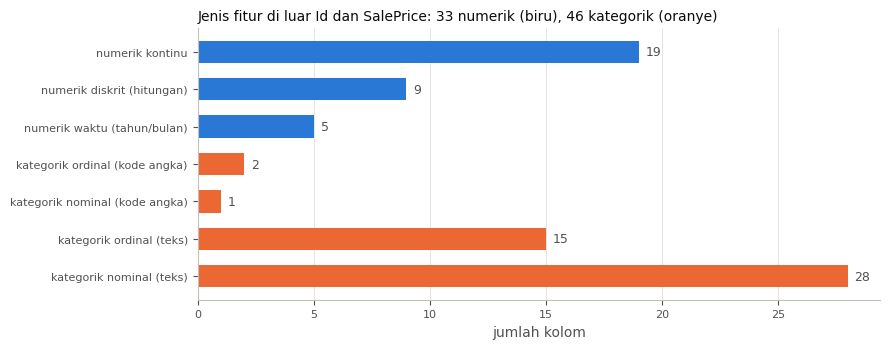

In [ ]:
# jenis setiap kolom: numerik atau kategorik
KUALITAS = ['Po', 'Fa', 'TA', 'Gd', 'Ex']# buruk -> sangat baik
SKALA = { # urutan kategori ordinal, rendah -> tinggi
    'ExterQual': KUALITAS, 'ExterCond': KUALITAS, 'BsmtQual': KUALITAS, 'BsmtCond': KUALITAS,
    'HeatingQC': KUALITAS, 'KitchenQual': KUALITAS, 'FireplaceQu': KUALITAS,
    'GarageQual': KUALITAS, 'GarageCond': KUALITAS, 'PoolQC': KUALITAS,
    'BsmtExposure': ['No', 'Mn', 'Av', 'Gd'],
    'BsmtFinType1': ['Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],
    'BsmtFinType2': ['Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],
    'GarageFinish': ['Unf', 'RFn', 'Fin'],
    'Functional': ['Sal', 'Sev', 'Maj2', 'Maj1', 'Mod', 'Min2', 'Min1', 'Typ'],
}

KONTINU = ['LotFrontage', 'LotArea', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
           'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'GarageArea',
           'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch',
           'PoolArea', 'MiscVal']
DISKRIT = ['BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr',
           'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageCars']
WAKTU = ['YearBuilt', 'YearRemodAdd', 'GarageYrBlt', 'MoSold', 'YrSold']
ORDINAL_ANGKA = ['OverallQual', 'OverallCond']
NOMINAL_ANGKA = ['MSSubClass']
ORDINAL_TEKS = list(SKALA)
NOMINAL_TEKS = [c for c in kol_kat if c not in SKALA]

KELOMPOK_JENIS = {
    'numerik kontinu': KONTINU,
    'numerik diskrit (hitungan)': DISKRIT,
    'numerik waktu (tahun/bulan)': WAKTU,
    'kategorik ordinal (kode angka)': ORDINAL_ANGKA,
    'kategorik nominal (kode angka)': NOMINAL_ANGKA,
    'kategorik ordinal (teks)': ORDINAL_TEKS,
    'kategorik nominal (teks)': NOMINAL_TEKS,
}
JENIS = {'Id': 'identitas', 'SalePrice': 'target (numerik kontinu)'}
JENIS.update({c: j for j, daftar in KELOMPOK_JENIS.items() for c in daftar})
assert set(JENIS) == set(df_raw.columns), 'ada kolom yang belum diberi jenis'

SINGKAT = {'identitas': 'id', 'target (numerik kontinu)': 'target',
           'numerik kontinu': 'kontinu', 'numerik diskrit (hitungan)': 'diskrit',
           'numerik waktu (tahun/bulan)': 'waktu',
           'kategorik ordinal (kode angka)': 'ordinal', 'kategorik nominal (kode angka)': 'nominal',
           'kategorik ordinal (teks)': 'ordinal', 'kategorik nominal (teks)': 'nominal'}

tipe = pd.DataFrame({
    'jenis': pd.Series(JENIS),
    'dtype': df_raw.dtypes.astype(str),
    'n_unik': df_raw.nunique(),
    '%_kosong': df_raw.isna().mean().mul(100).round(2),
    'nilai_tersering': pd.Series({c: ', '.join(map(str, df_raw[c].value_counts().index[:4]))
                                  for c in df_raw.columns}),
}).loc[df_raw.columns]

urutan_jenis = ['identitas', 'target (numerik kontinu)'] + list(KELOMPOK_JENIS)
tipe = tipe.sort_values('jenis', key=lambda s: s.map(urutan_jenis.index), kind='stable')
display(tipe)

n_num = sum(len(d) for j, d in KELOMPOK_JENIS.items() if j.startswith('numerik'))
n_kat = sum(len(d) for j, d in KELOMPOK_JENIS.items() if j.startswith('kategorik'))
float_bulat = [c for c in df_raw.select_dtypes('float').columns if (df_raw[c].dropna() % 1 == 0).all()]
print(f'Fitur numerik   : {n_num}')
print(f'Fitur kategorik : {n_kat}  (termasuk {len(ORDINAL_ANGKA) + len(NOMINAL_ANGKA)} kolom yang disimpan sebagai angka)')
print('Bertipe angka tetapi bermakna kategori :', ORDINAL_ANGKA + NOMINAL_ANGKA)
print('Bertipe float hanya karena ada NaN      :', float_bulat)

hitung = pd.Series({j: len(d) for j, d in KELOMPOK_JENIS.items()})
fig, ax = plt.subplots(figsize=(9, 3.6))
warna = [BIRU if j.startswith('numerik') else ORANYE for j in hitung.index]
ax.barh(hitung.index[::-1], hitung.values[::-1], color=warna[::-1], height=0.6)
for y, v in enumerate(hitung.values[::-1]):
    ax.text(v + 0.3, y, str(v), va='center', fontsize=9, color=ABU)
ax.grid(axis='y', visible=False)
ax.grid(axis='x', visible=True)
ax.set_xlabel('jumlah kolom')
ax.set_title(f'Jenis fitur di luar Id dan SalePrice: {n_num} numerik (biru), {n_kat} kategorik (oranye)',
             loc='left')
plt.tight_layout()
plt.show()

### notes
1. 1460 baris, 81 kolom: 43 object, 35 int64, 3 float64. Di luar `Id` (identitas) dan `SalePrice` (target) ada 33 fitur numerik (19 kontinu, 9 diskrit, 5 waktu) dan 46 fitur kategorik (15 ordinal teks, 28 nominal teks, 3 kode angka).
2. `MSSubClass`, `OverallQual`, `OverallCond` bertipe angka tetapi bermakna kategori. `MSSubClass` adalah kode tipe bangunan (20, 60, 120, ...) yang tidak bisa dijumlah atau dirata-rata, sedangkan `OverallQual` dan `OverallCond` adalah skala 1-10 yang berurutan.
3. `LotFrontage`, `MasVnrArea`, `GarageYrBlt` bertipe float hanya karena ada NaN; semua nilainya bulat.
4. Banyak fitur numerik didominasi nol: `PoolArea` 99.5%, `3SsnPorch` 98.4%, `LowQualFinSF` 98.2%, `MiscVal` 96.4%, `ScreenPorch` 92.1%, `BsmtFinSF2` 88.6%, `EnclosedPorch` 85.8%. Isinya lebih mirip penanda ada/tidak ada fasilitas daripada ukuran yang tersebar.
5. Skewness tertinggi: `MiscVal` 24.5, `PoolArea` 14.8, `LotArea` 12.2 (kurtosis 203). `LotArea` maksimum 215245 sqft, 23 kali median 9478.
6. Kategorik hampir konstan: `Utilities` 99.9% AllPub (hanya 1 rumah NoSeWa), `Street` 99.6%, `Condition2` 99.0%, `RoofMatl` 98.2%, `Heating` 97.8%.
7. `Neighborhood` (25 kategori), `Exterior2nd` (16), `Exterior1st` (15), dan `MSSubClass` (15) akan menghasilkan kolom terbanyak saat one-hot encoding.

## 4. Distribusi Target: SalePrice

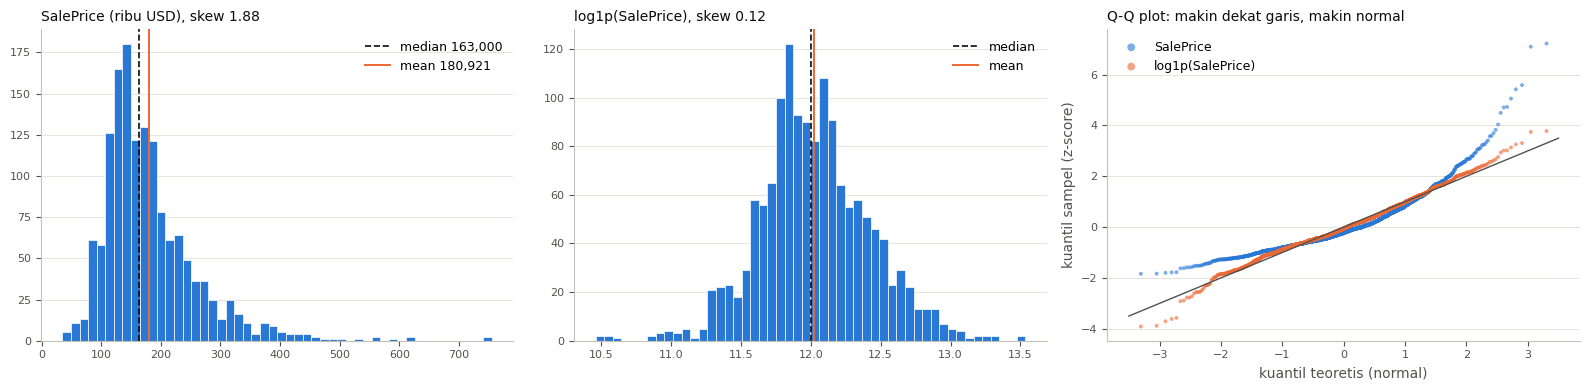

count      1460.0
mean     180921.0
std       79443.0
min       34900.0
25%      129975.0
50%      163000.0
75%      214000.0
max      755000.0

skewness : 1.88  ->  setelah log1p 0.12
kurtosis : 6.54  ->  setelah log1p 0.81
rumah di atas batas atas IQR (340,038): 61


In [8]:
harga = df_raw['SalePrice']
log_harga = np.log1p(harga)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(harga / 1000, bins=50, color=BIRU, edgecolor='white', linewidth=0.5)
axes[0].axvline(harga.median() / 1000, color=TINTA, lw=1.2, ls='--', label=f'median {harga.median():,.0f}')
axes[0].axvline(harga.mean() / 1000, color=ORANYE, lw=1.4, label=f'mean {harga.mean():,.0f}')
axes[0].set_title(f'SalePrice (ribu USD), skew {harga.skew():.2f}', loc='left')
axes[0].legend()

axes[1].hist(log_harga, bins=50, color=BIRU, edgecolor='white', linewidth=0.5)
axes[1].axvline(log_harga.median(), color=TINTA, lw=1.2, ls='--', label='median')
axes[1].axvline(log_harga.mean(), color=ORANYE, lw=1.4, label='mean')
axes[1].set_title(f'log1p(SalePrice), skew {log_harga.skew():.2f}', loc='left')
axes[1].legend()

for s, warna, nama in [(harga, BIRU, 'SalePrice'), (log_harga, ORANYE, 'log1p(SalePrice)')]:
    z = (s - s.mean()) / s.std()
    (teori, sampel), _ = stats.probplot(z, dist='norm')
    axes[2].scatter(teori, sampel, s=8, color=warna, alpha=0.6, edgecolors='none', label=nama)
axes[2].plot([-3.5, 3.5], [-3.5, 3.5], color=ABU, lw=1)
axes[2].set_xlabel('kuantil teoretis (normal)')
axes[2].set_ylabel('kuantil sampel (z-score)')
axes[2].set_title('Q-Q plot: makin dekat garis, makin normal', loc='left')
axes[2].legend(markerscale=2)
plt.tight_layout()
plt.show()

q1, q3 = harga.quantile([0.25, 0.75])
batas_atas = q3 + 1.5 * (q3 - q1)
print(harga.describe().round(0).to_string())
print(f'\nskewness : {harga.skew():.2f}  ->  setelah log1p {log_harga.skew():.2f}')
print(f'kurtosis : {harga.kurtosis():.2f}  ->  setelah log1p {log_harga.kurtosis():.2f}')
print(f'rumah di atas batas atas IQR ({batas_atas:,.0f}): {(harga > batas_atas).sum()}')

### notes
1. `SalePrice` miring ke kanan: mean 180921 lebih besar dari median 163000, skew 1.88, kurtosis 6.54, rentang 34900 - 755000.
2. 61 rumah (4.2%) berada di atas batas atas IQR (340038). 58 di antaranya ber-`OverallQual` 8-10, jadi ini rumah mahal yang sah, bukan salah input.
3. `log1p` menurunkan skew menjadi 0.12 dan kurtosis menjadi 0.81; titik Q-Q plot hampir lurus di garis normal. Target akan dipakai dalam skala log pada tahap transformasi.

## 5. Line Chart 

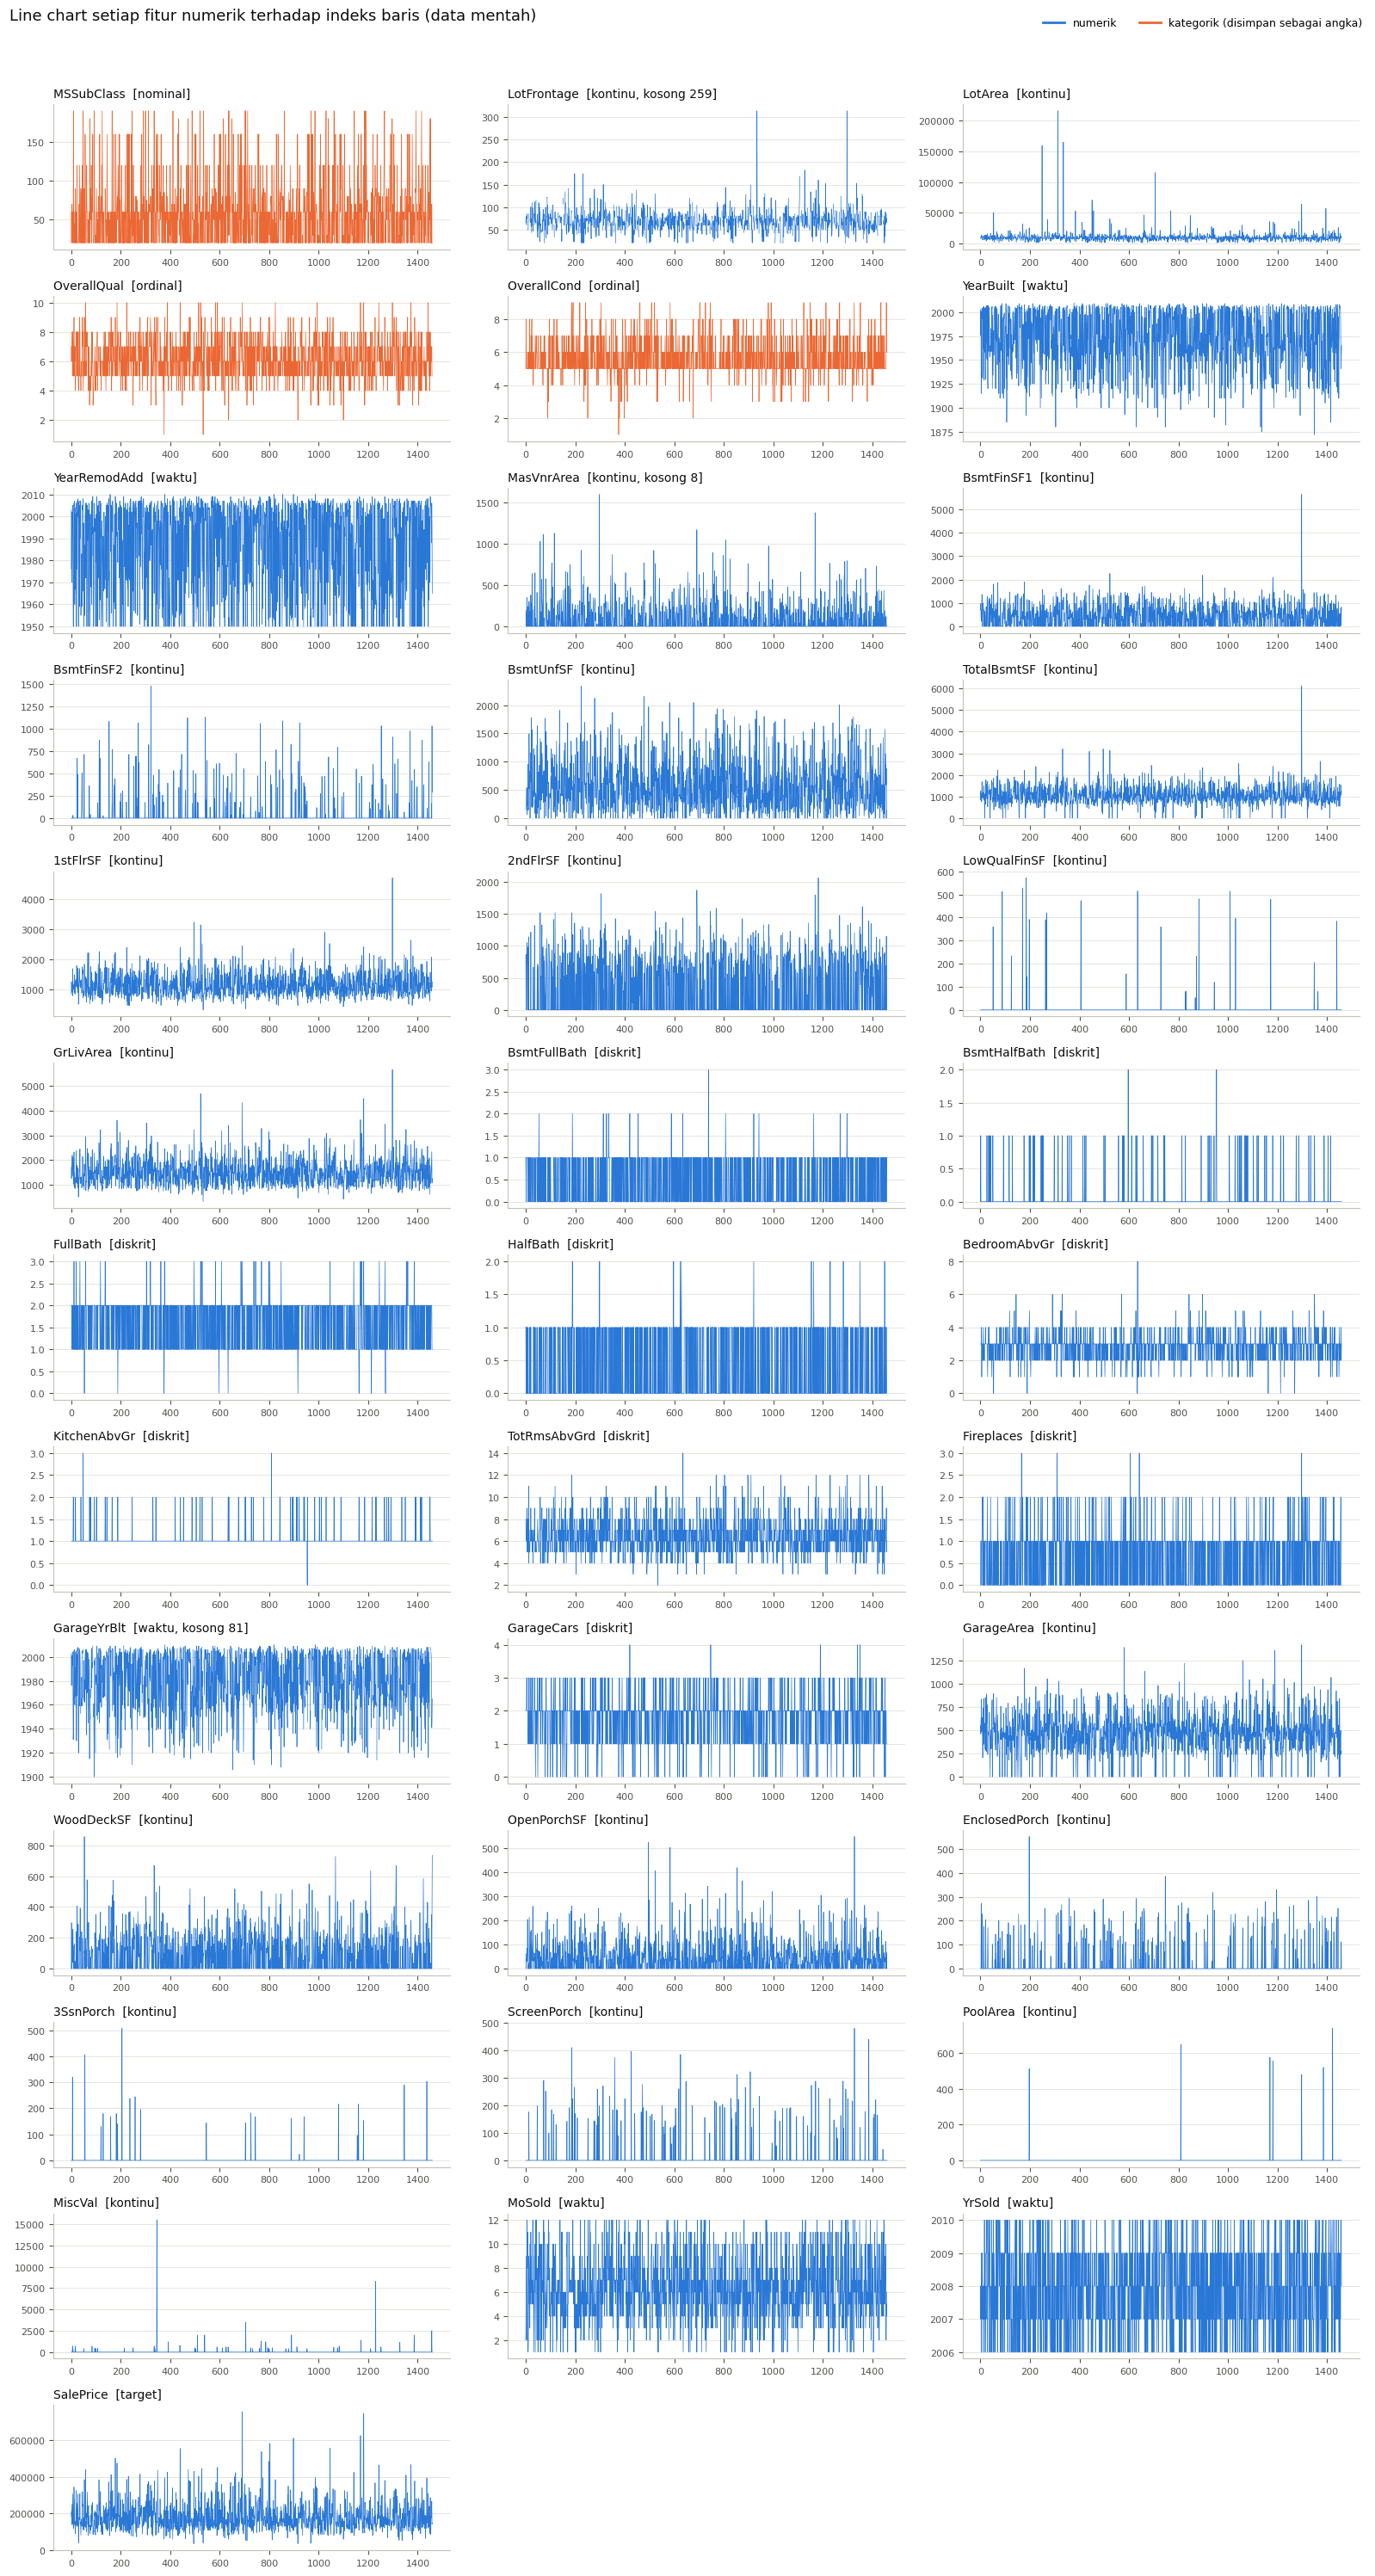

In [9]:
# fitur numerik terhadap indeks baris; oranye = kolom angka yang sebenarnya kategori
fitur_num = [c for c in df_raw.select_dtypes('number').columns if c != 'Id']

fig, axes = buat_grid(len(fitur_num), ncols=3, tinggi=2.3)
for ax, col in zip(axes, fitur_num):
    warna = ORANYE if JENIS[col].startswith('kategorik') else BIRU
    ax.plot(df_raw.index, df_raw[col], color=warna, linewidth=0.5)
    n_kosong = df_raw[col].isna().sum()
    info_kosong = f', kosong {n_kosong}' if n_kosong else ''
    ax.set_title(f'{col}  [{SINGKAT[JENIS[col]]}{info_kosong}]', loc='left')

fig.legend(handles=[Line2D([], [], color=BIRU, lw=2, label='numerik'),
                    Line2D([], [], color=ORANYE, lw=2, label='kategorik (disimpan sebagai angka)')],
           loc='upper right', ncol=2, bbox_to_anchor=(1, 1.0))
judul_figur(fig, 'Line chart setiap fitur numerik terhadap indeks baris (data mentah)')
plt.tight_layout(rect=[0, 0, 1, 0.985])
plt.show()

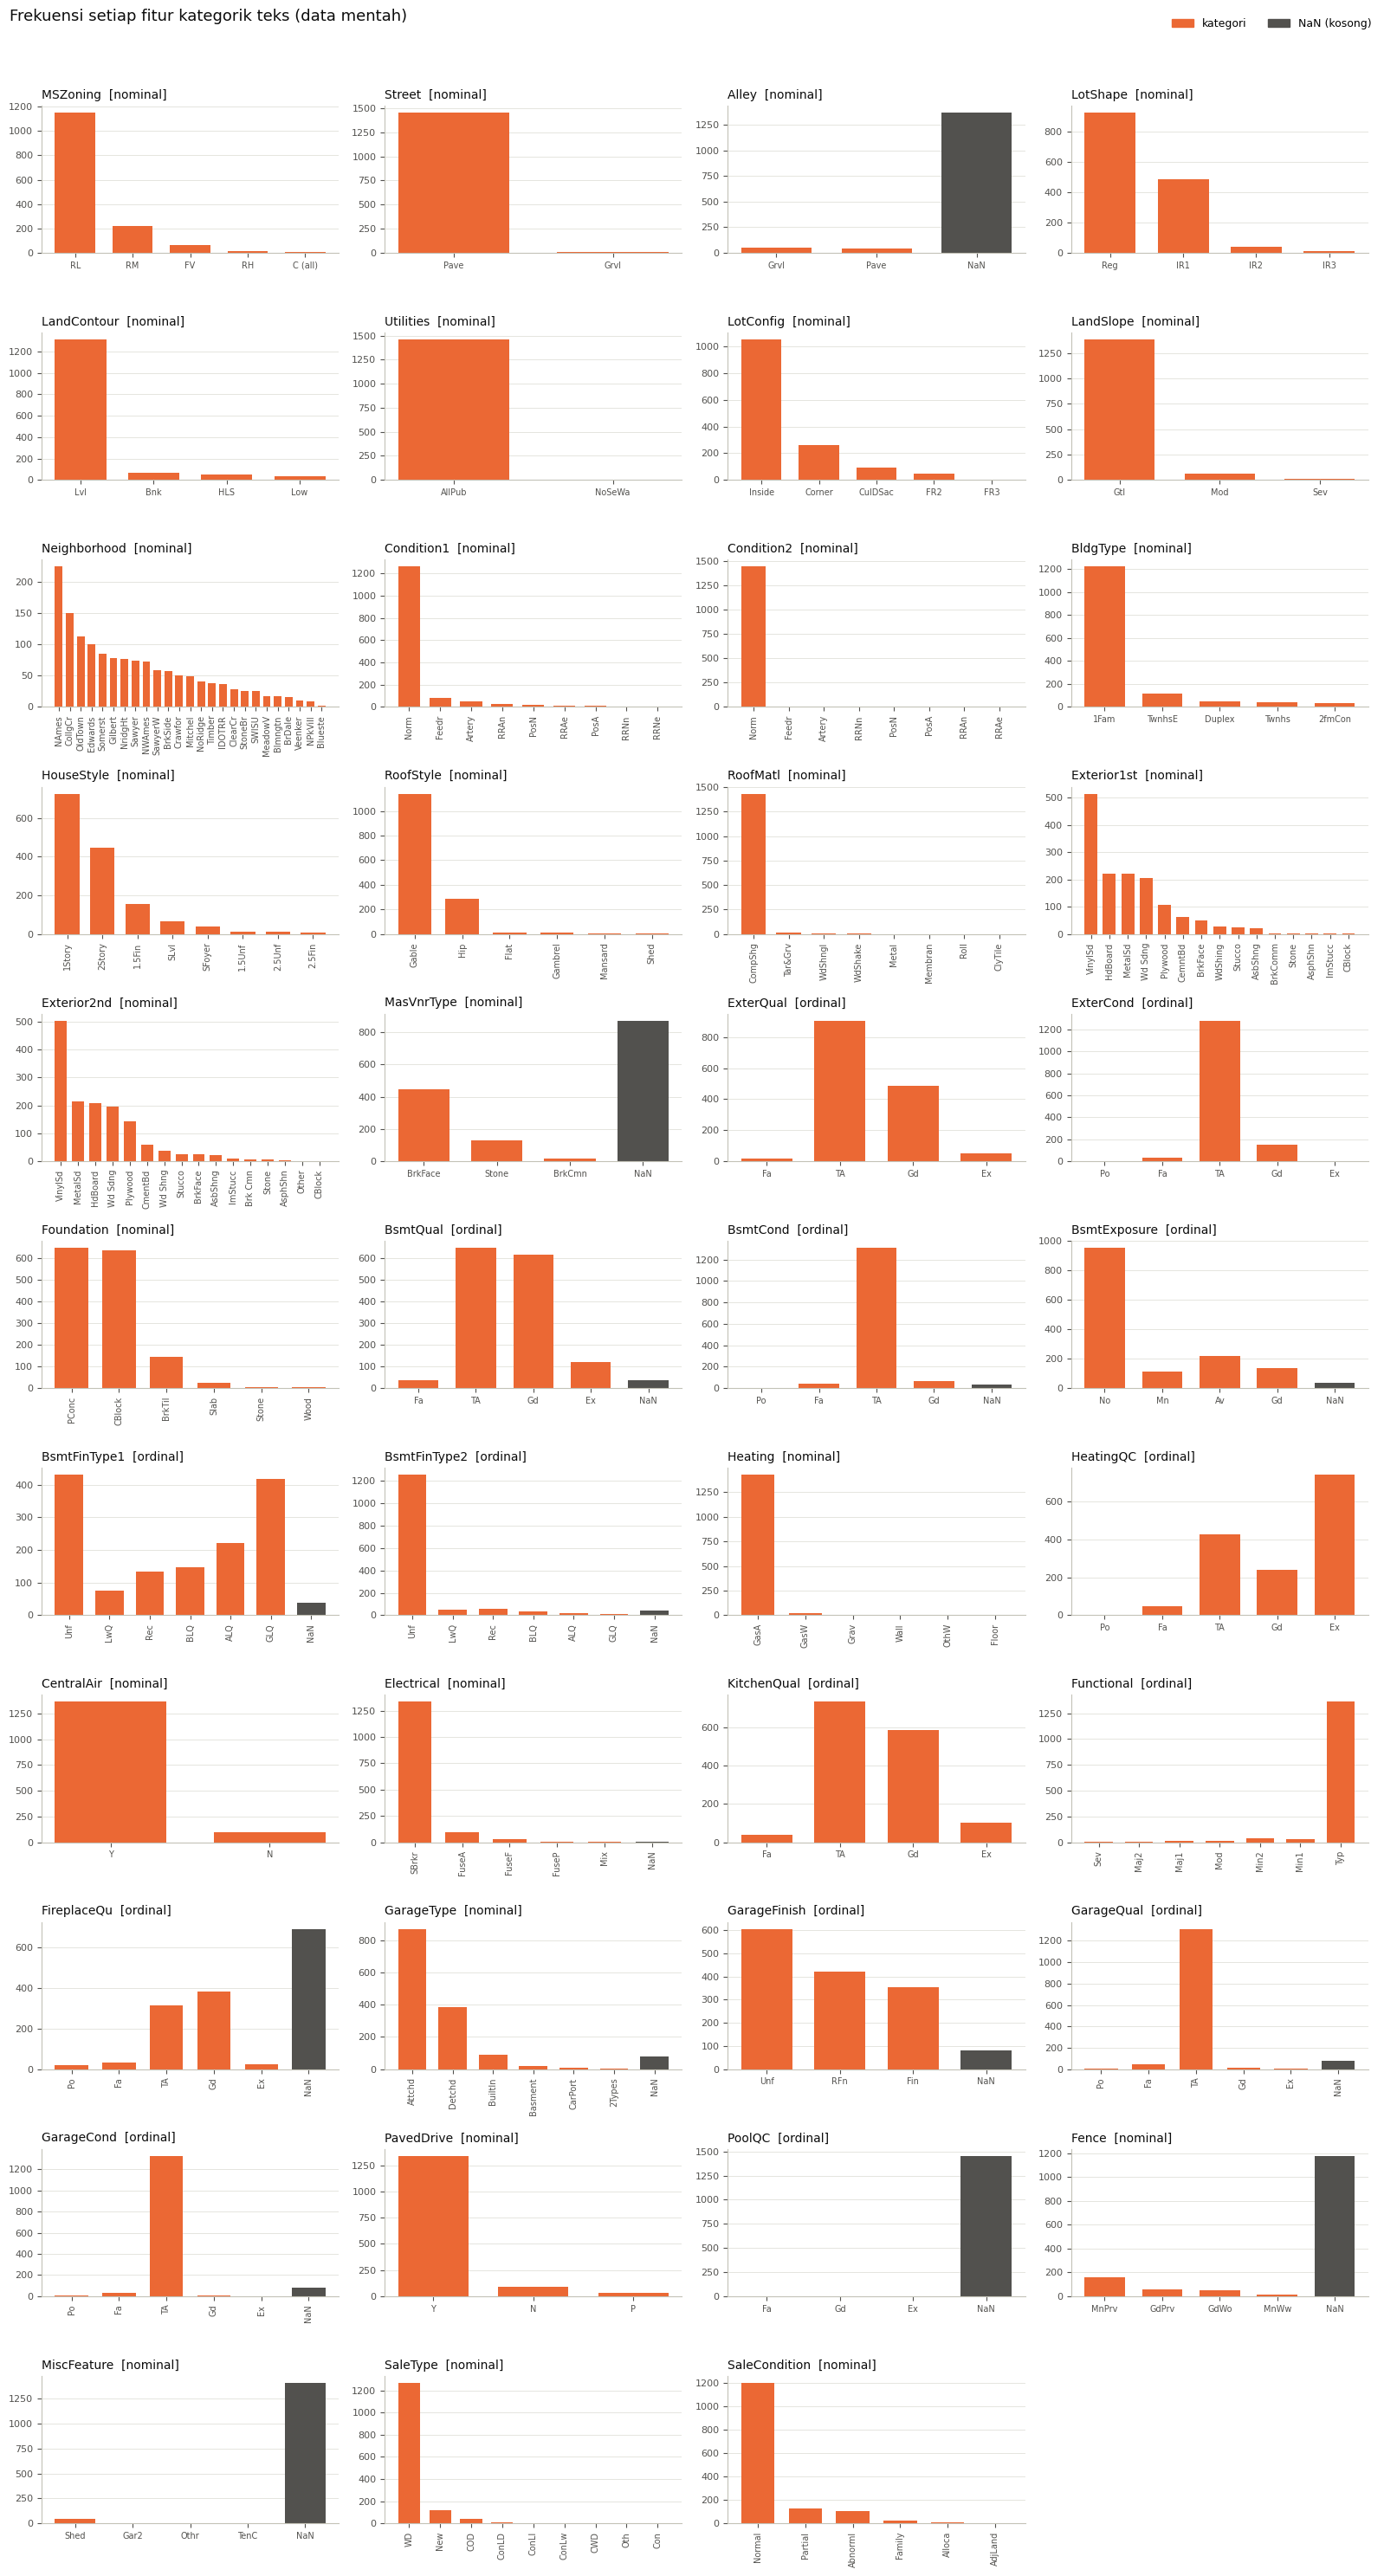

In [10]:
# fitur kategorik teks: line chart tidak bermakna untuk label teks, jadi ditampilkan sebagai frekuensi
# urutan batang: ordinal mengikuti skala (rendah -> tinggi), nominal dari yang tersering; NaN paling kanan
fitur_kat = df_raw.select_dtypes('object').columns.tolist()

fig, axes = buat_grid(len(fitur_kat), ncols=4, tinggi=2.7)
for ax, col in zip(axes, fitur_kat):
    vc = df_raw[col].value_counts()
    if col in SKALA:
        vc = vc.reindex([k for k in SKALA[col] if k in vc.index])
    n_nan = df_raw[col].isna().sum()
    if n_nan:
        vc = pd.concat([vc, pd.Series({'NaN': n_nan})])
    warna = [ABU if k == 'NaN' else ORANYE for k in vc.index]
    ax.bar(range(len(vc)), vc.values, color=warna, width=0.7)
    ax.set_xticks(range(len(vc)))
    ax.set_xticklabels(vc.index, rotation=90 if len(vc) > 5 else 0, fontsize=7)
    ax.set_title(f'{col}  [{SINGKAT[JENIS[col]]}]', loc='left')

fig.legend(handles=[Patch(color=ORANYE, label='kategori'), Patch(color=ABU, label='NaN (kosong)')],
           loc='upper right', ncol=2, bbox_to_anchor=(1, 1.0))
judul_figur(fig, 'Frekuensi setiap fitur kategorik teks (data mentah)')
plt.tight_layout(rect=[0, 0, 1, 0.985])
plt.show()

### notes
1. Urutan baris tidak membentuk tren karena data ini kumpulan penjualan, bukan deret waktu. Line chart dipakai untuk melihat lonjakan tunggal, celah kosong, dan bentuk nilai tiap fitur.
2. Lonjakan tunggal yang menonjol: `LotArea` (Id 314, 336, 250 di atas 150000 sqft), `LotFrontage` 313 ft (Id 935 dan 1299), `MiscVal` 15500 (Id 347), dan `SalePrice` 755000 / 745000 (Id 692, 1183).
3. Lonjakan `BsmtFinSF1`, `TotalBsmtSF`, `1stFlrSF`, dan `GrLivArea` terjadi di baris yang sama (Id 1299), tanda satu rumah yang ekstrem di banyak fitur sekaligus.
4. Fitur diskrit (`FullBath`, `GarageCars`, `Fireplaces`) tampak sebagai pita bertingkat, sedangkan fitur yang didominasi nol (`PoolArea`, `3SsnPorch`, `LowQualFinSF`) berupa garis datar di 0 dengan sedikit paku.
5. `LotFrontage` dan `GarageYrBlt` memperlihatkan celah pada garis di baris yang kosong.
6. Pada fitur kategorik teks, NaN (abu tua) mendominasi `PoolQC`, `MiscFeature`, `Alley`, `Fence`, dan hampir separuh `FireplaceQu`. Line chart tidak dipakai di sini karena label teks tidak punya urutan angka.
7. Fitur ordinal kualitas didominasi TA (rata-rata): dari baris yang terisi, `GarageQual` dan `GarageCond` sekitar 95%, `BsmtCond` 92%, `ExterCond` 88%, sehingga variasinya kecil.

## 6. Distribusi Fitur per Kelompok Harga

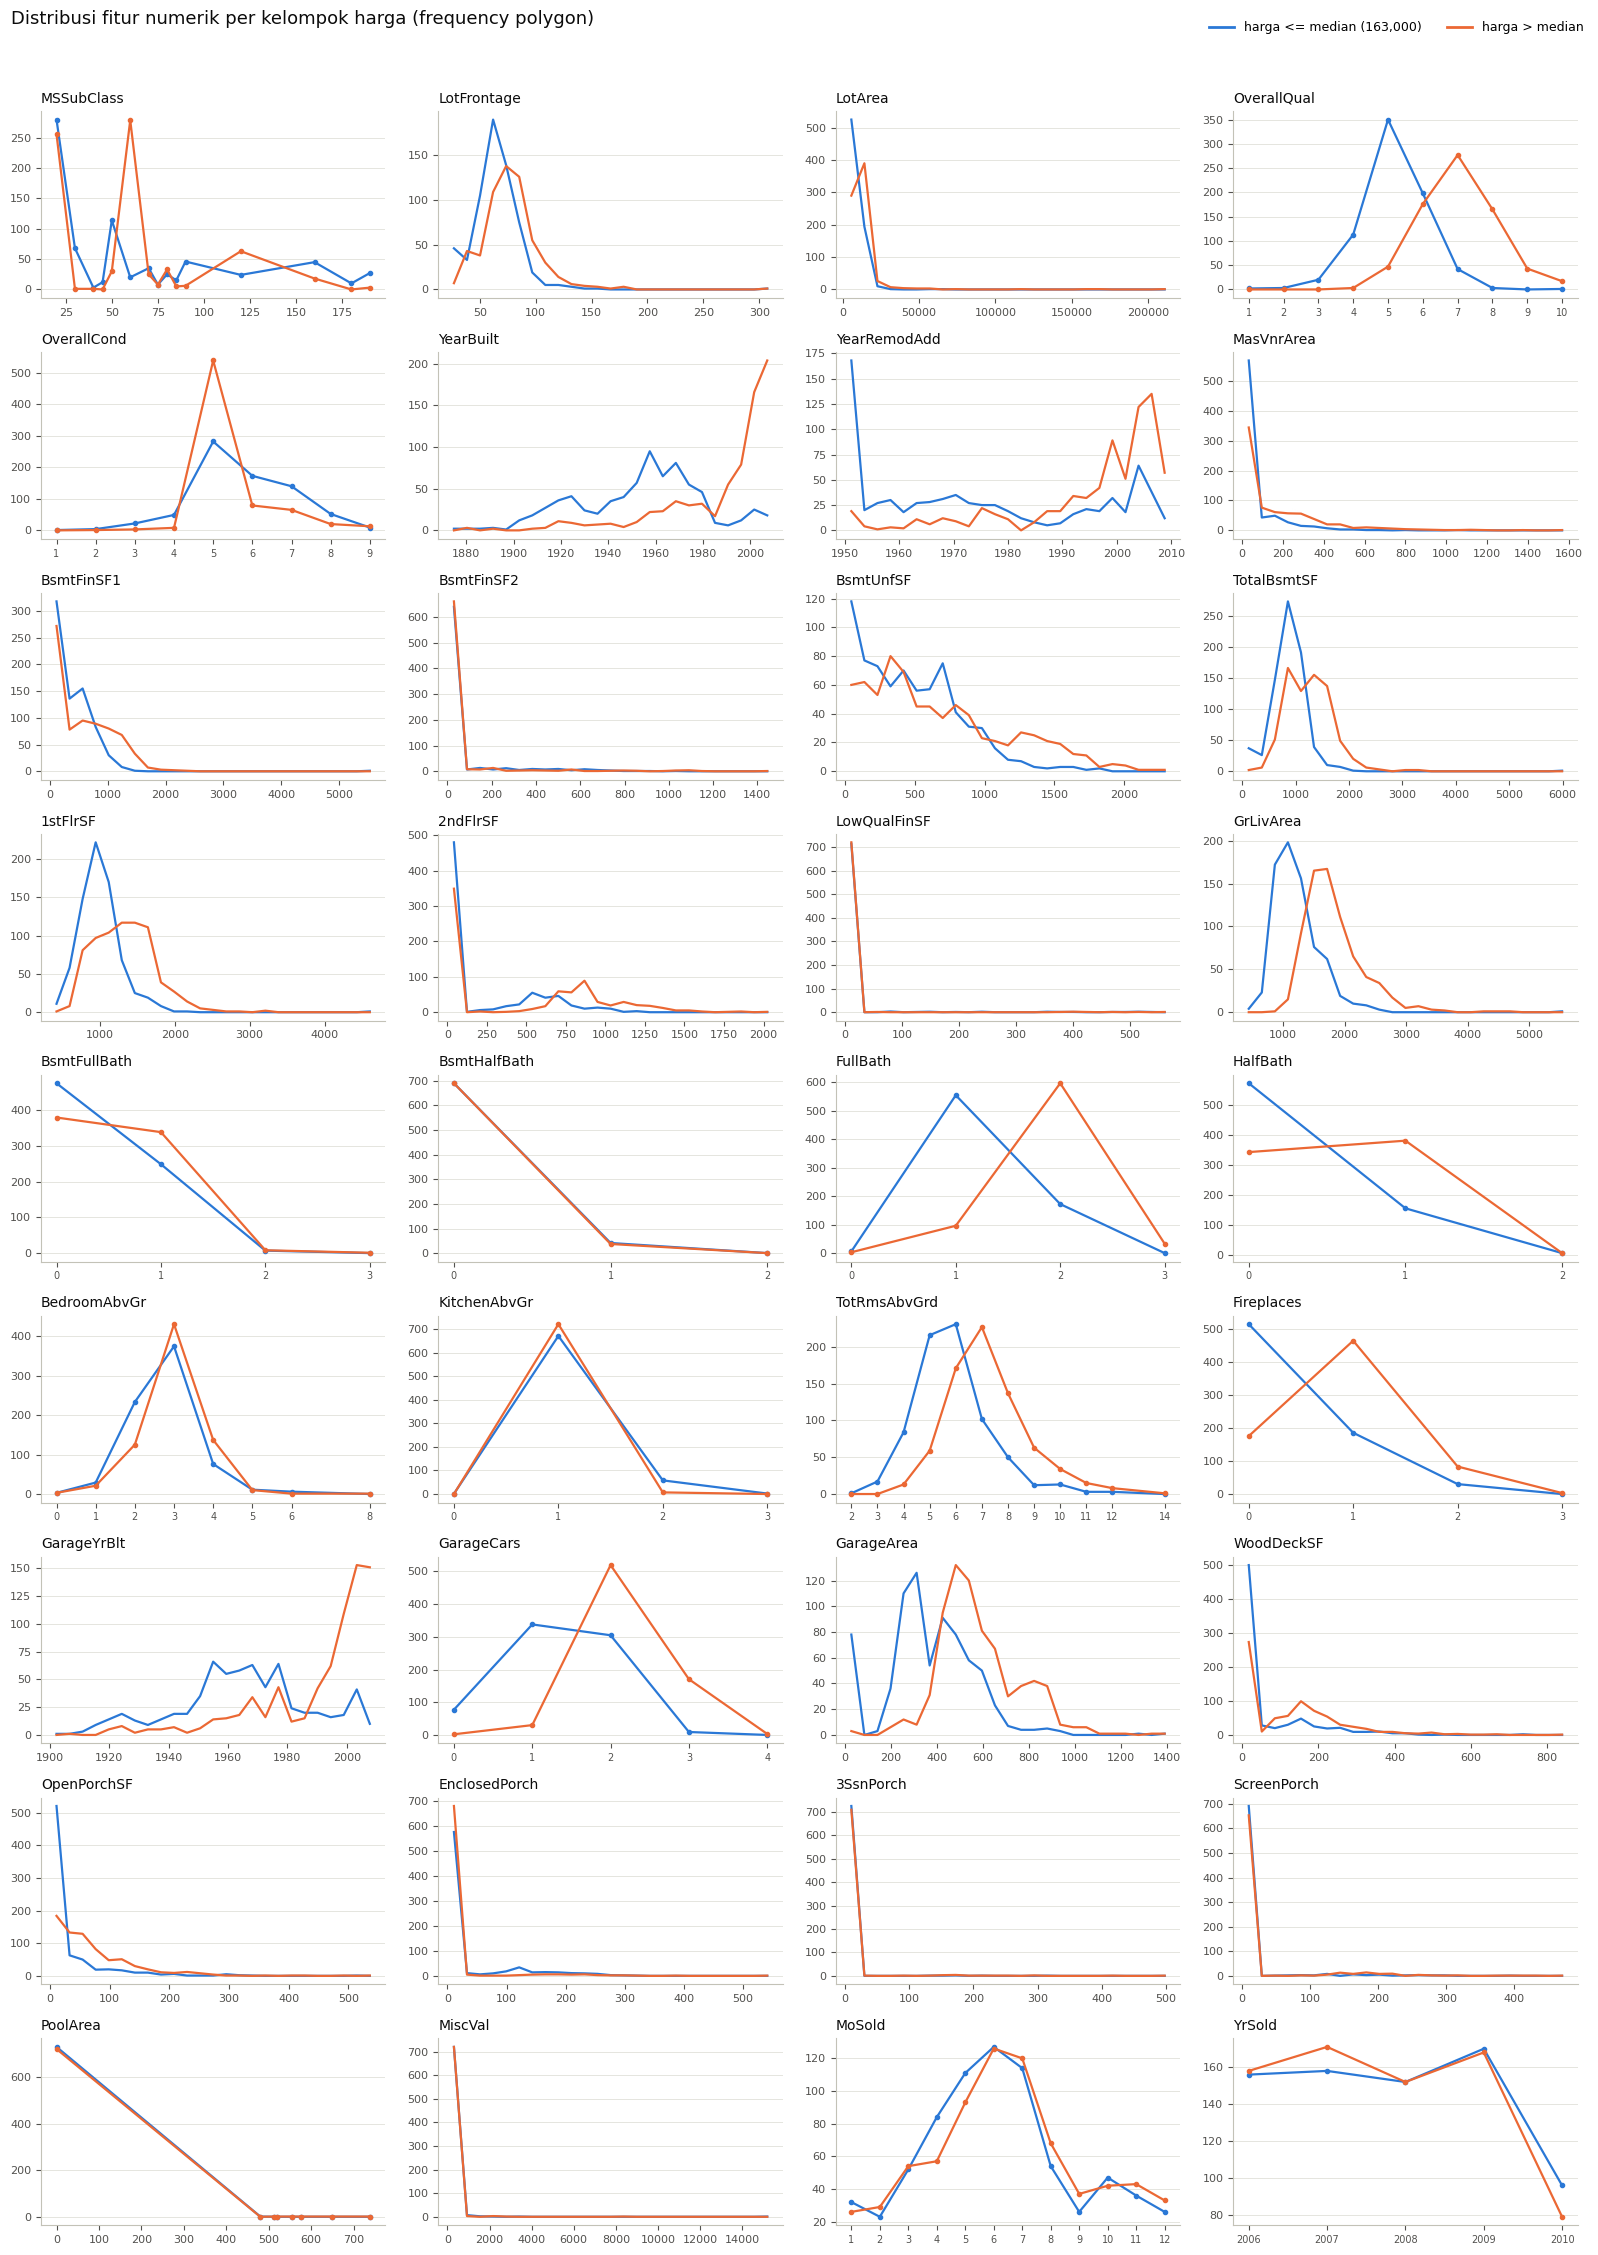

In [11]:
# frequency polygon: rumah dibagi dua di median harga
median_harga = df_raw['SalePrice'].median()
kelompok_harga = np.where(df_raw['SalePrice'] > median_harga, 'tinggi', 'rendah')
fitur_x = [c for c in fitur_num if c != 'SalePrice']

fig, axes = buat_grid(len(fitur_x), ncols=4, tinggi=2.5)
for ax, col in zip(axes, fitur_x):
    s = df_raw[col]
    if s.nunique() <= 15:
        x = np.sort(s.dropna().unique())
        for kel, warna in (('rendah', BIRU), ('tinggi', ORANYE)):
            frek = s[kelompok_harga == kel].value_counts().reindex(x, fill_value=0)
            ax.plot(x, frek.values, color=warna, lw=1.6, marker='o', markersize=3)
        if len(x) <= 12 and JENIS[col] != 'numerik kontinu':
            ax.set_xticks(x)
            ax.set_xticklabels([f'{v:g}' for v in x], fontsize=7)
    else:
        tepi = np.histogram_bin_edges(s.dropna(), bins=25)
        pusat = (tepi[:-1] + tepi[1:]) / 2
        for kel, warna in (('rendah', BIRU), ('tinggi', ORANYE)):
            frek, _ = np.histogram(s[kelompok_harga == kel].dropna(), bins=tepi)
            ax.plot(pusat, frek, color=warna, lw=1.6)
    ax.set_title(col, loc='left')

fig.legend(handles=[Line2D([], [], color=BIRU, lw=2, label=f'harga <= median ({median_harga:,.0f})'),
                    Line2D([], [], color=ORANYE, lw=2, label='harga > median')],
           loc='upper right', ncol=2, bbox_to_anchor=(1, 1.0))
judul_figur(fig, 'Distribusi fitur numerik per kelompok harga (frequency polygon)')
plt.tight_layout(rect=[0, 0, 1, 0.985])
plt.show()

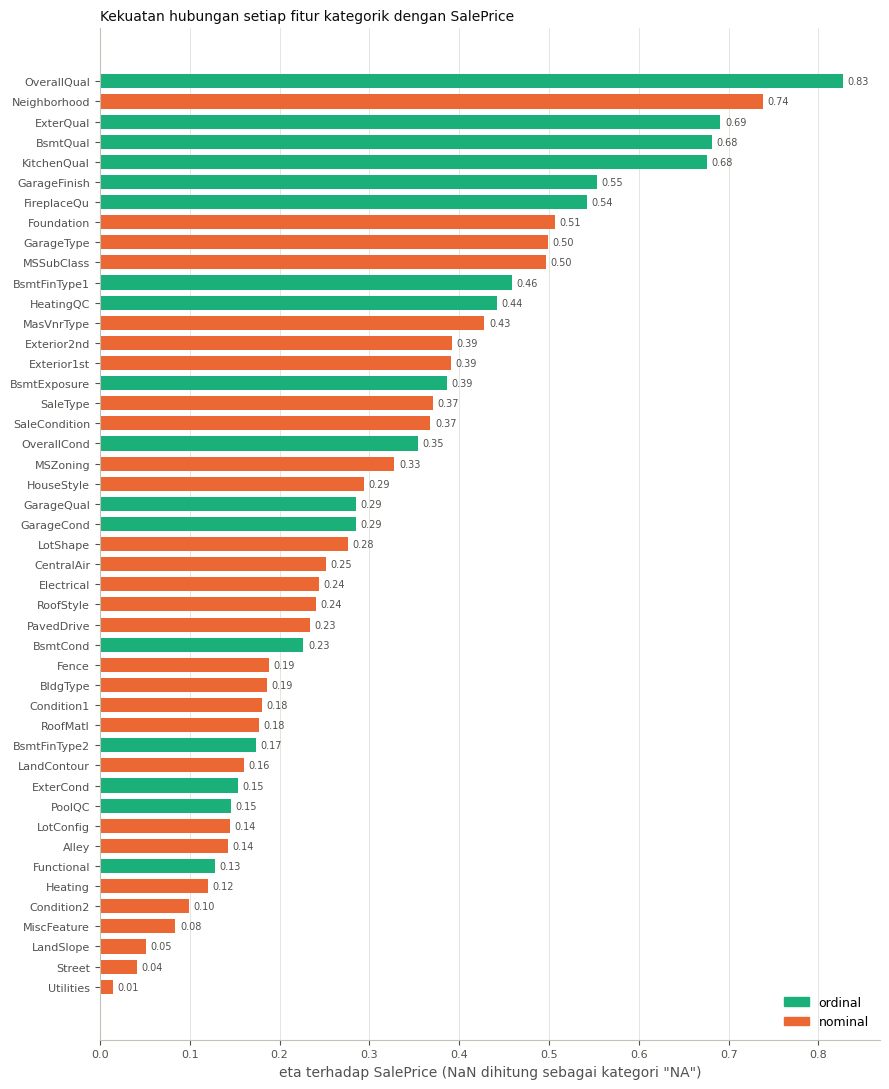

In [12]:
# kekuatan hubungan fitur kategorik dengan SalePrice memakai rasio korelasi (eta, 0-1)
def rasio_korelasi(kategori, nilai):
    kategori = pd.Series(kategori).fillna('NA').astype(str).to_numpy()
    nilai = np.asarray(nilai, dtype=float)
    rata = nilai.mean()
    ss_antar = sum((kategori == k).sum() * (nilai[kategori == k].mean() - rata) ** 2
                   for k in np.unique(kategori))
    ss_total = ((nilai - rata) ** 2).sum()
    return np.sqrt(ss_antar / ss_total)


fitur_kat_semua = ORDINAL_ANGKA + NOMINAL_ANGKA + ORDINAL_TEKS + NOMINAL_TEKS
eta = pd.Series({c: rasio_korelasi(df_raw[c], df_raw['SalePrice']) for c in fitur_kat_semua})
eta = eta.sort_values()

fig, ax = plt.subplots(figsize=(9, 11))
warna = [AQUA if 'ordinal' in JENIS[c] else ORANYE for c in eta.index]
ax.barh(eta.index, eta.values, color=warna, height=0.7)
for y, v in enumerate(eta.values):
    ax.text(v + 0.005, y, f'{v:.2f}', va='center', fontsize=7, color=ABU)
ax.grid(axis='y', visible=False)
ax.grid(axis='x', visible=True)
ax.set_xlabel('eta terhadap SalePrice (NaN dihitung sebagai kategori "NA")')
ax.legend(handles=[Patch(color=AQUA, label='ordinal'), Patch(color=ORANYE, label='nominal')], loc='lower right')
ax.set_title('Kekuatan hubungan setiap fitur kategorik dengan SalePrice', loc='left')
plt.tight_layout()
plt.show()

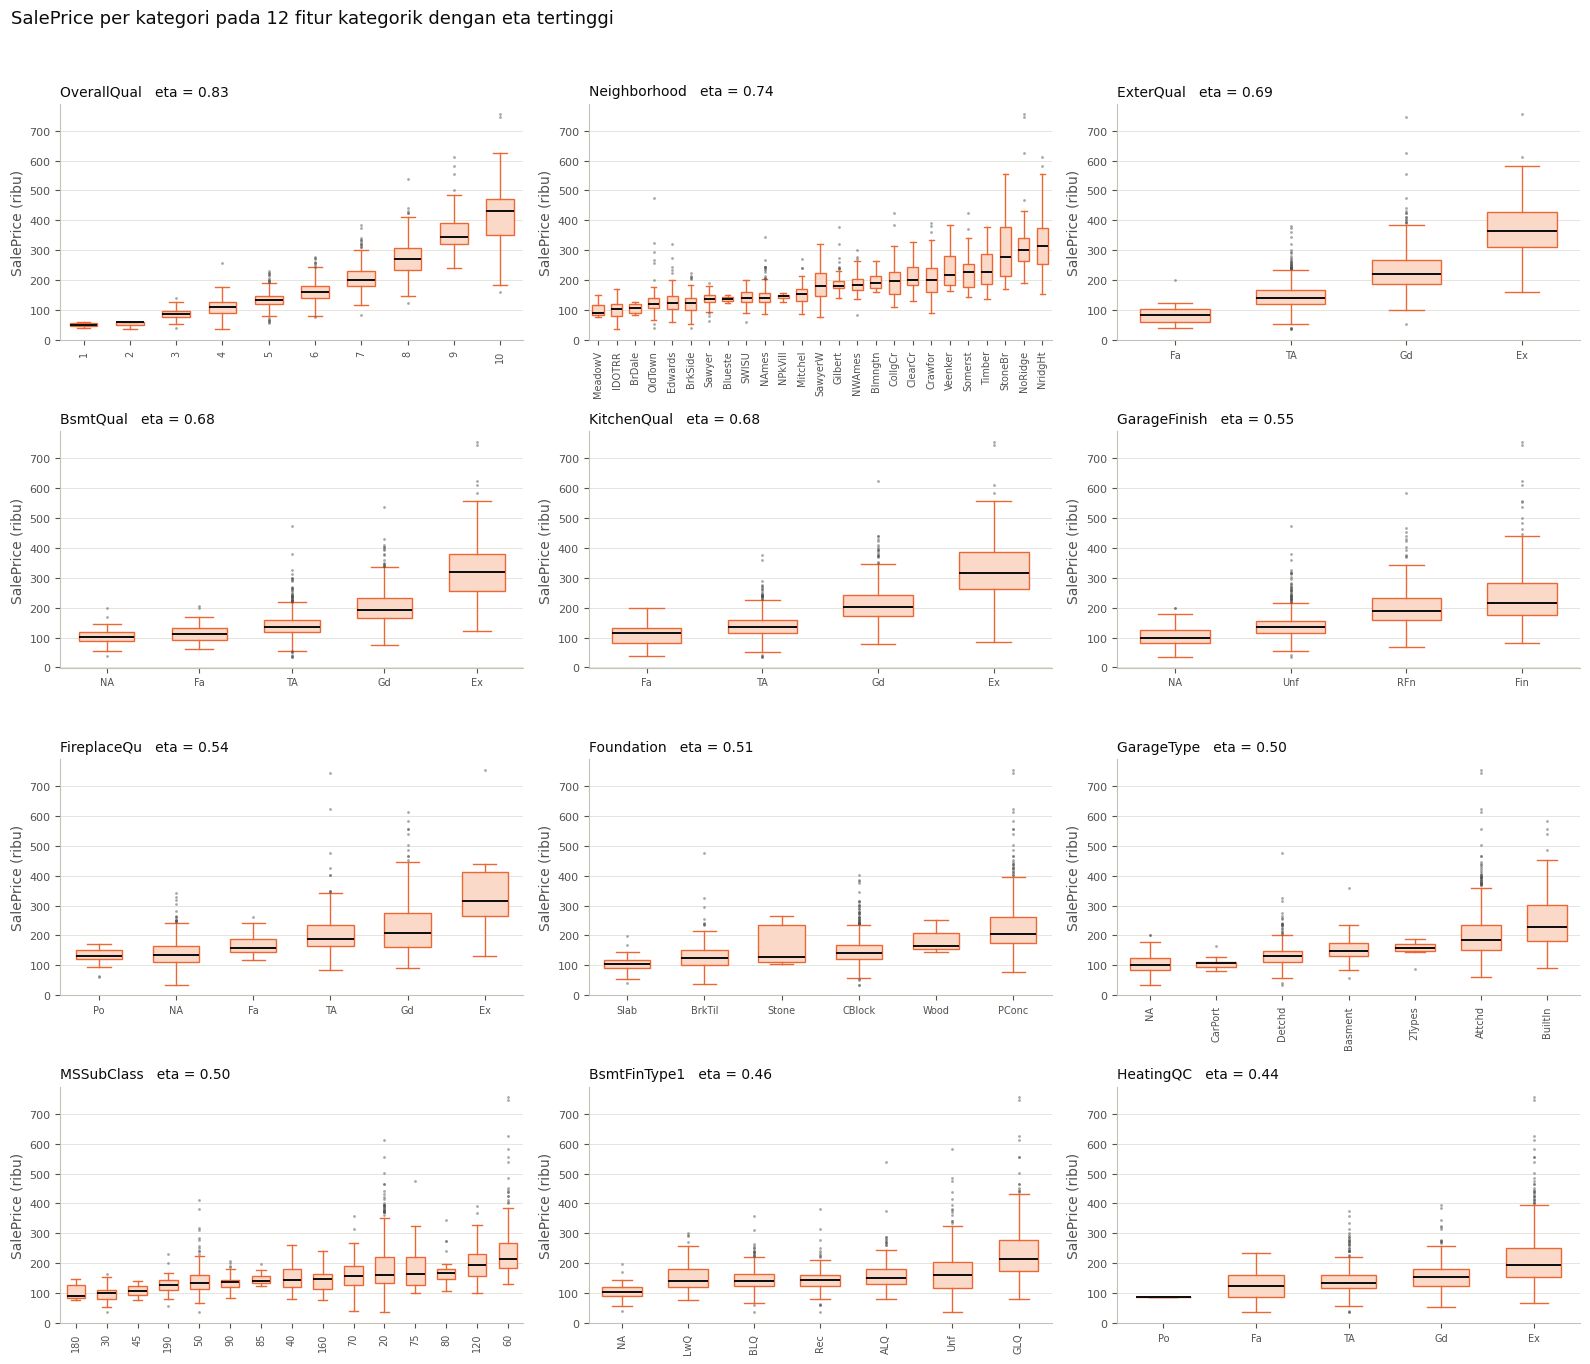

In [13]:
# sebaran harga per kategori untuk 12 fitur kategorik terkuat, kategori diurutkan dari median termurah
top_kat = eta.sort_values(ascending=False).index[:12]

fig, axes = buat_grid(len(top_kat), ncols=3, tinggi=3.4)
for ax, col in zip(axes, top_kat):
    s = df_raw[col].fillna('NA').astype(str)
    urut = df_raw.groupby(s)['SalePrice'].median().sort_values().index
    ax.boxplot([df_raw.loc[s == k, 'SalePrice'] / 1000 for k in urut], widths=0.6, patch_artist=True,
               boxprops=dict(facecolor='#fbd9c9', edgecolor=ORANYE),
               medianprops=dict(color=TINTA, linewidth=1.4),
               whiskerprops=dict(color=ORANYE), capprops=dict(color=ORANYE),
               flierprops=dict(marker='o', markersize=2, markerfacecolor=ABU, markeredgecolor='none', alpha=0.5))
    ax.set_xticks(range(1, len(urut) + 1))
    ax.set_xticklabels(urut, rotation=90 if len(urut) > 6 else 0, fontsize=7)
    ax.set_title(f'{col}   eta = {eta[col]:.2f}', loc='left')
    ax.set_ylabel('SalePrice (ribu)')

judul_figur(fig, 'SalePrice per kategori pada 12 fitur kategorik dengan eta tertinggi')
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

### notes
1. Fitur numerik yang paling memisahkan rumah murah dan mahal: `OverallQual` (puncak di 5 vs 7), `GrLivArea`, `GarageCars` (1 vs 2), `FullBath` (1 vs 2), `TotRmsAbvGrd`, dan `YearBuilt`. Rumah di atas median harga sebagian besar dibangun setelah 1990.
2. Kurva rendah dan tinggi hampir berimpit pada `MoSold`, `YrSold`, `BsmtHalfBath`, `PoolArea`, `MiscVal`, `3SsnPorch`, dan `LowQualFinSF`: fitur ini hampir tidak membedakan harga.
3. `OverallCond` berlawanan intuisi: rumah mahal justru menumpuk di nilai 5. Rumah dengan kondisi 5 umumnya rumah baru (median dibangun 1998), sedangkan kondisi 6-8 kebanyakan rumah tua (median 1945-1960).
4. Hubungan kategorik terkuat dengan harga (eta): `OverallQual` 0.83, `Neighborhood` 0.74, `ExterQual` 0.69, `BsmtQual` 0.68, `KitchenQual` 0.68. Terlemah `Utilities` 0.01, `Street` 0.04, `LandSlope` 0.05.
5. Lokasi berpengaruh besar: median harga termurah di MeadowV (88000), IDOTRR, dan BrDale, termahal di StoneBr, NoRidge, dan NridgHt (315000).
6. Pada fitur ordinal kualitas (`ExterQual`, `BsmtQual`, `KitchenQual`, `GarageFinish`) median harga naik berurutan mengikuti skala. Urutan ini perlu dipertahankan saat encoding.
7. Kategori NA (tidak ada garasi, basement, atau perapian) konsisten berada di kelompok termurah. Artinya "tidak ada fasilitas" adalah informasi, bukan data yang boleh diabaikan.

## 7. Scatter Plot Setiap Fitur

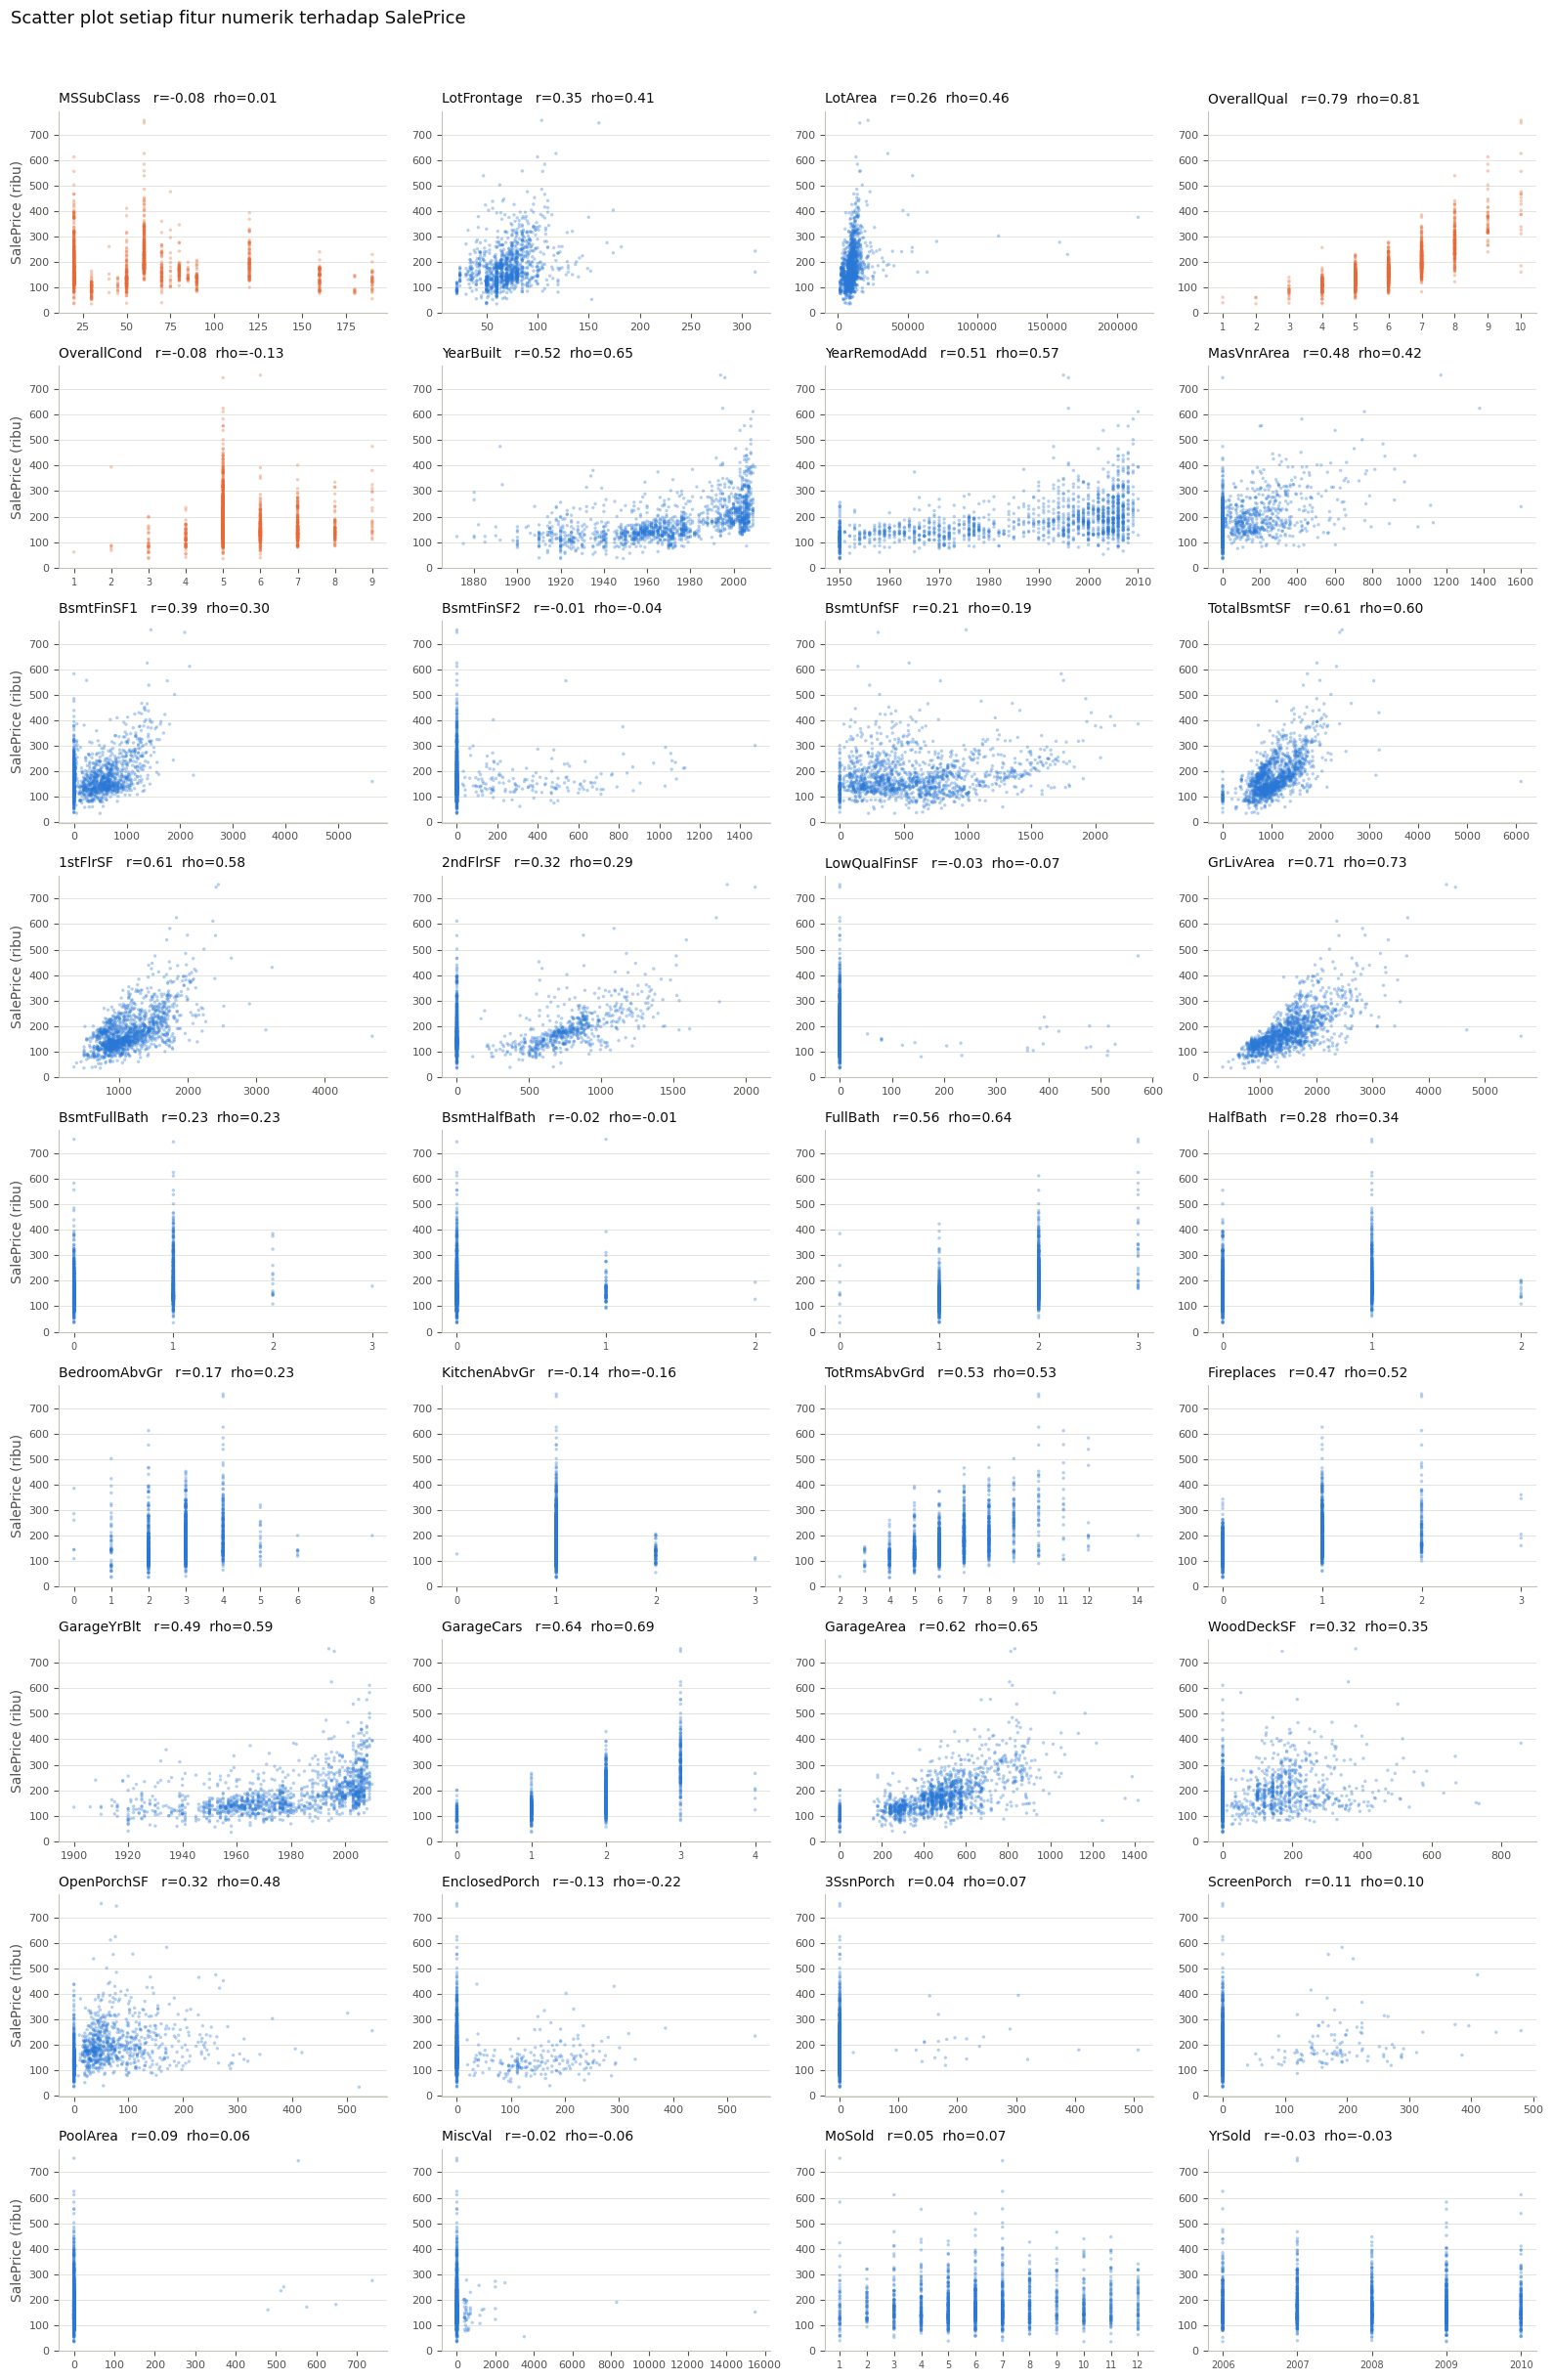

In [14]:
# setiap fitur numerik terhadap SalePrice; r = Pearson, rho = Spearman
fig, axes = buat_grid(len(fitur_x), ncols=4, tinggi=2.7)
for ax, col in zip(axes, fitur_x):
    s = df_raw[[col, 'SalePrice']].dropna()
    warna = ORANYE if JENIS[col].startswith('kategorik') else BIRU
    ax.scatter(s[col], s['SalePrice'] / 1000, s=6, alpha=0.35, color=warna, edgecolors='none')
    if s[col].nunique() <= 12 and JENIS[col] != 'numerik kontinu':
        nilai_x = np.sort(s[col].unique())
        ax.set_xticks(nilai_x)
        ax.set_xticklabels([f'{v:g}' for v in nilai_x], fontsize=7)
    r = s[col].corr(s['SalePrice'])
    rho = s[col].corr(s['SalePrice'], method='spearman')
    ax.set_title(f'{col}   r={r:.2f}  rho={rho:.2f}', loc='left')
for ax in axes[::4]:
    ax.set_ylabel('SalePrice (ribu)')

judul_figur(fig, 'Scatter plot setiap fitur numerik terhadap SalePrice')
plt.tight_layout(rect=[0, 0, 1, 0.985])
plt.show()

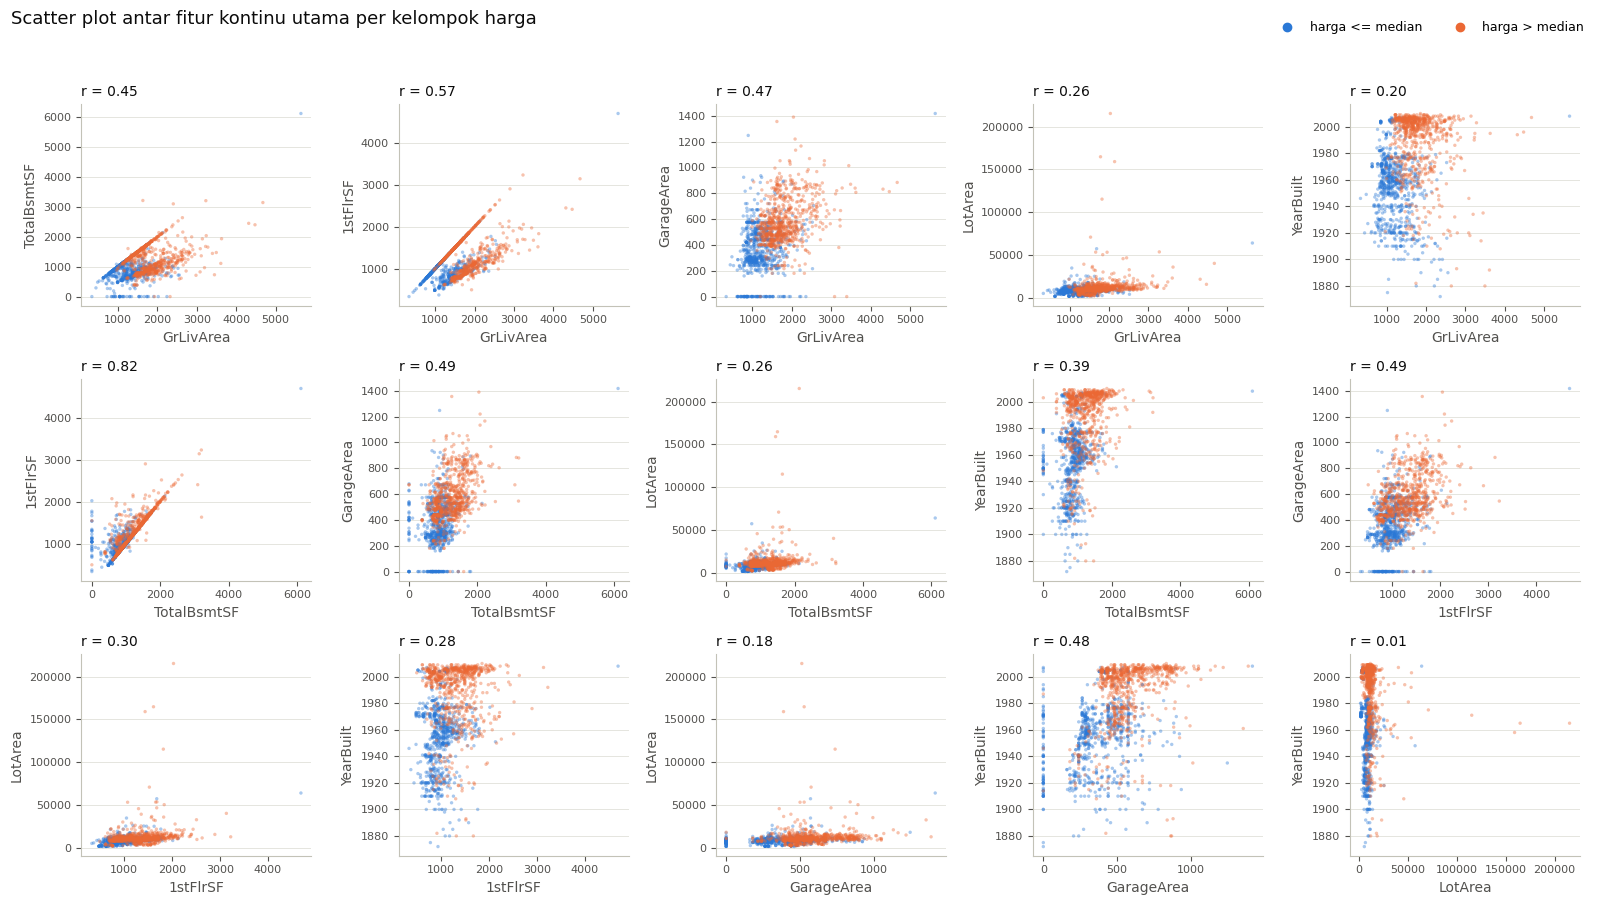

In [15]:
# scatter antar fitur kontinu utama, diwarnai kelompok harga
utama = ['GrLivArea', 'TotalBsmtSF', '1stFlrSF', 'GarageArea', 'LotArea', 'YearBuilt']
pasangan_utama = [(a, b) for i, a in enumerate(utama) for b in utama[i + 1:]]

fig, axes = buat_grid(len(pasangan_utama), ncols=5, tinggi=3.0)
for ax, (a, b) in zip(axes, pasangan_utama):
    for kel, warna in (('rendah', BIRU), ('tinggi', ORANYE)):
        m = kelompok_harga == kel
        ax.scatter(df_raw.loc[m, a], df_raw.loc[m, b], s=6, alpha=0.4, color=warna, edgecolors='none')
    ax.set_xlabel(a)
    ax.set_ylabel(b)
    ax.set_title(f'r = {df_raw[a].corr(df_raw[b]):.2f}', loc='left')

fig.legend(handles=[Line2D([], [], color=BIRU, marker='o', ls='none', label='harga <= median'),
                    Line2D([], [], color=ORANYE, marker='o', ls='none', label='harga > median')],
           loc='upper right', ncol=2, bbox_to_anchor=(1, 1.0))
judul_figur(fig, 'Scatter plot antar fitur kontinu utama per kelompok harga')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

### notes scatter
1. Hubungan linear terkuat dengan harga: `OverallQual` (r 0.79), `GrLivArea` (0.71), `GarageCars` (0.64), `GarageArea` (0.62), `TotalBsmtSF` dan `1stFlrSF` (0.61).
2. Dua rumah di kanan bawah scatter `GrLivArea` (luas di atas 4500 sqft, harga di bawah 200000) melawan pola utama. Titik yang sama muncul lagi di `TotalBsmtSF` (6110) dan `1stFlrSF` (4692).
3. Sebaran harga melebar saat luas bertambah (heteroskedastis). Ini alasan tambahan memakai log harga.
4. `LotArea` hanya r 0.26 tetapi rho 0.46: hubungannya ada, namun tertutup oleh beberapa kavling raksasa.
5. Fitur yang lebih dari 85% nol (`BsmtFinSF2`, `LowQualFinSF`, `EnclosedPorch`, `3SsnPorch`, `ScreenPorch`, `PoolArea`, `MiscVal`) tampak sebagai tiang di x = 0 dan |r|-nya dengan harga di bawah 0.15.
6. Antar fitur: `TotalBsmtSF` vs `1stFlrSF` membentuk garis diagonal tajam (banyak basement seluas lantai 1). `GrLivArea` vs `1stFlrSF` memiliki batas bawah y = x karena lantai 1 adalah bagian dari luas hunian. Rumah di atas median (oranye) menumpuk pada `YearBuilt` di atas 1990.

## 8. Korelasi Antar Fitur: Pearson vs Spearman

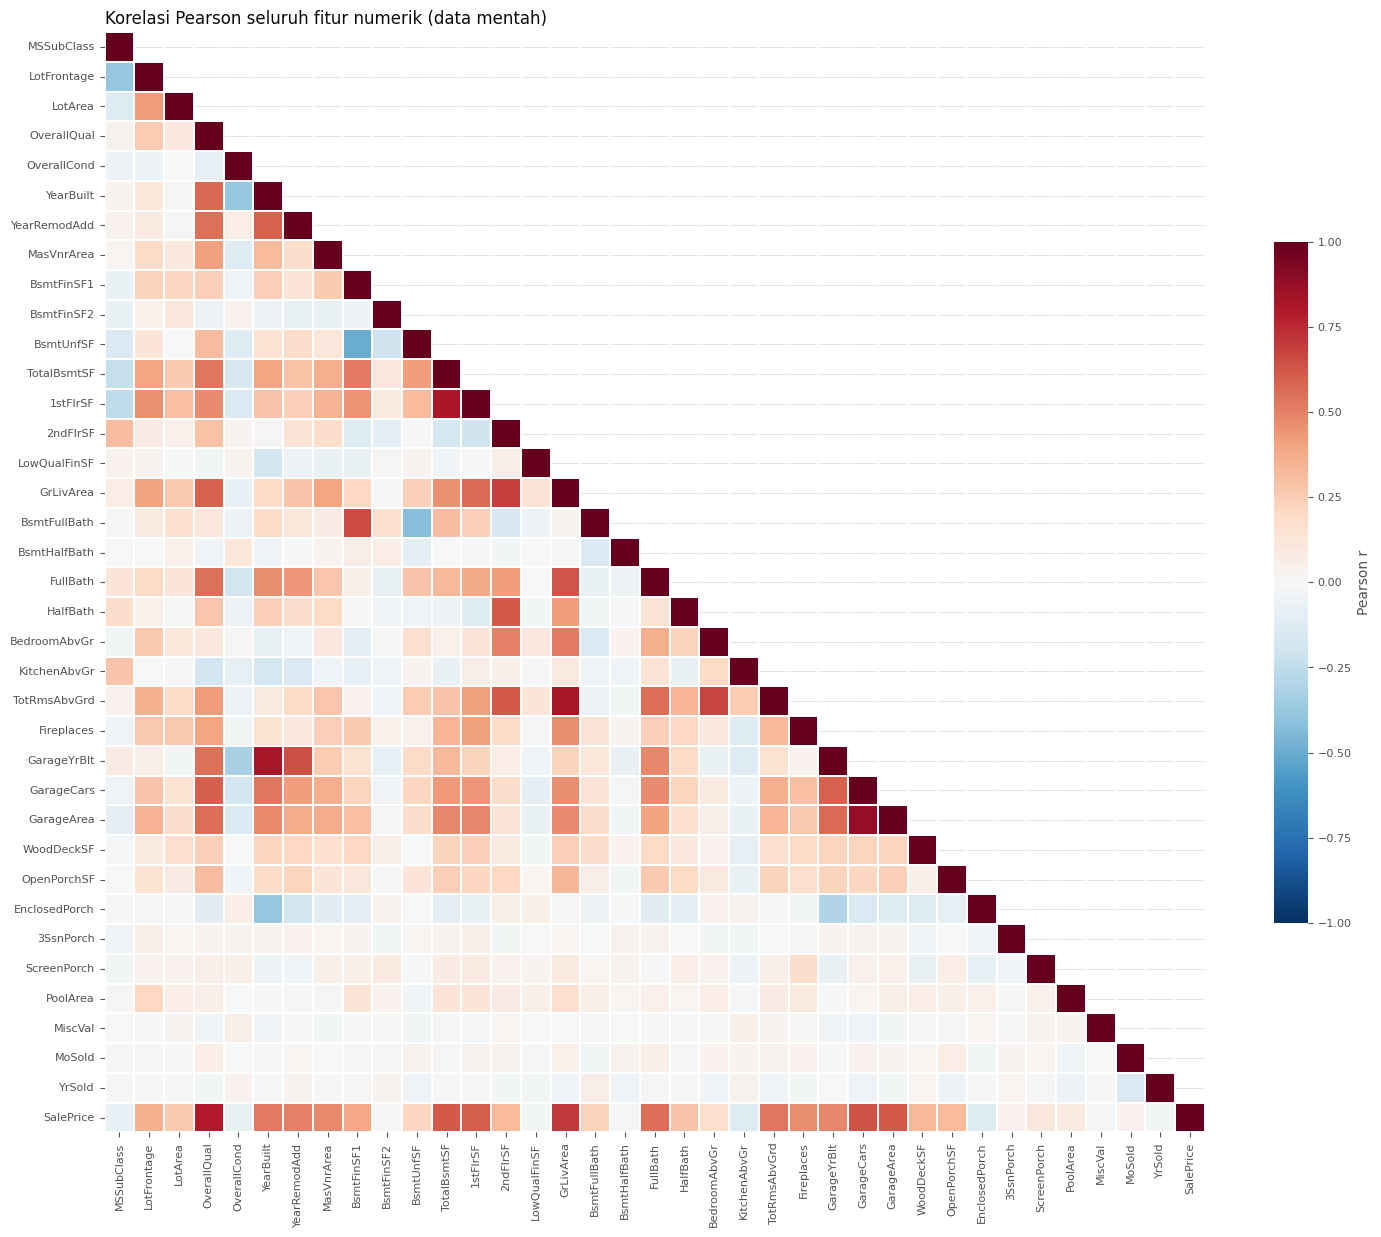

In [16]:
kor_p = df_raw[fitur_num].corr(method='pearson')
kor_s = df_raw[fitur_num].corr(method='spearman')
segitiga_atas = np.triu(np.ones_like(kor_p, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(15, 12.5))
sns.heatmap(kor_p, mask=segitiga_atas, cmap='RdBu_r', vmin=-1, vmax=1, center=0, square=True,
            linewidths=0.3, linecolor='white', cbar_kws={'shrink': 0.6, 'label': 'Pearson r'}, ax=ax)
ax.set_title('Korelasi Pearson seluruh fitur numerik (data mentah)', loc='left', fontsize=12)
ax.tick_params(labelsize=8)
plt.tight_layout()
plt.show()

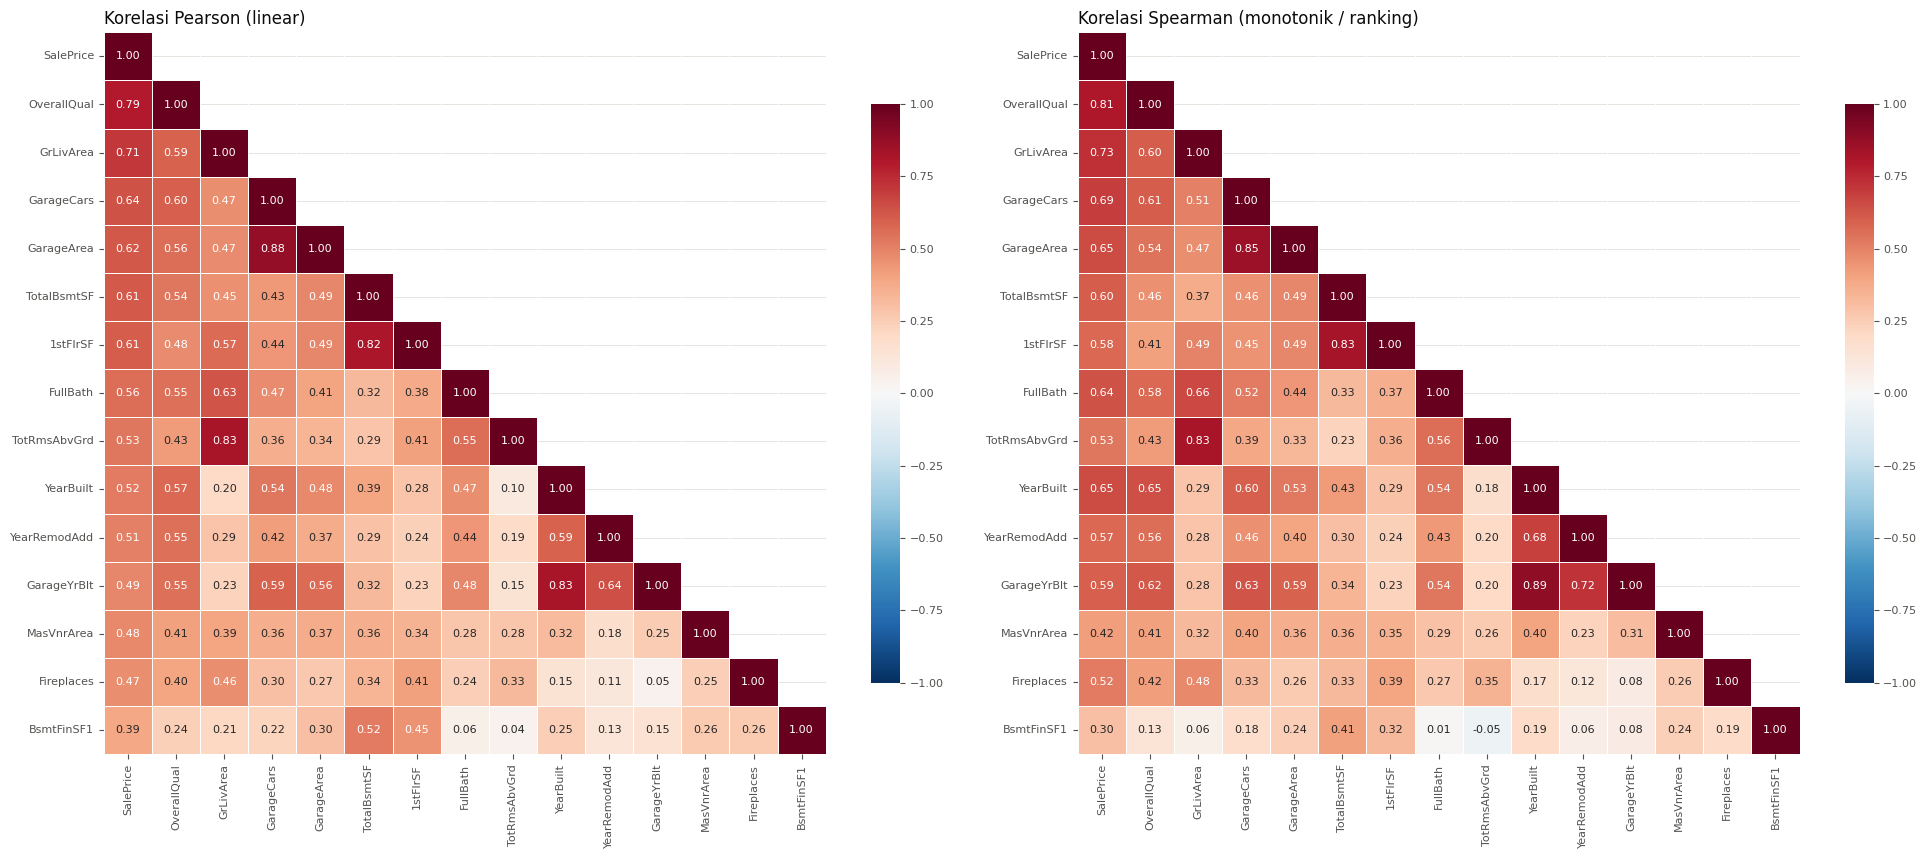

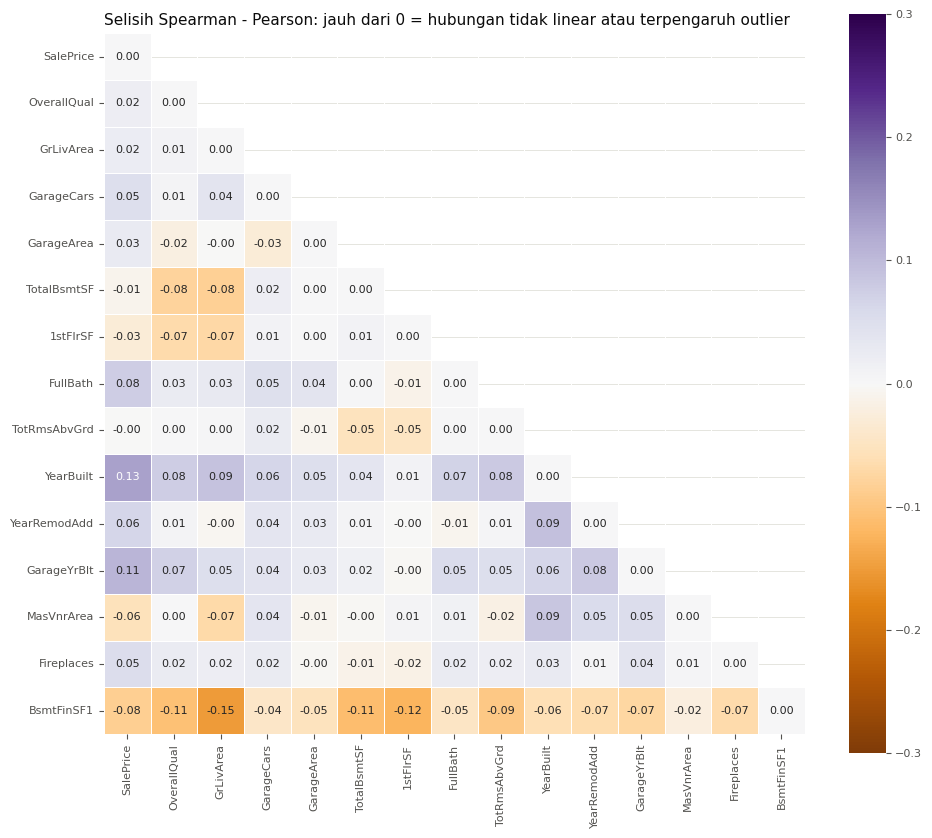

In [17]:
# 14 fitur dengan |Pearson| terbesar terhadap SalePrice, dibandingkan dengan Spearman
top_fitur = kor_p['SalePrice'].drop('SalePrice').abs().sort_values(ascending=False).index[:14].tolist()
top_fitur = ['SalePrice'] + top_fitur
mask_top = np.triu(np.ones((len(top_fitur), len(top_fitur)), dtype=bool), k=1)

fig, axes = plt.subplots(1, 2, figsize=(20, 8.5))
for ax, kor, nama in zip(axes, [kor_p, kor_s], ['Pearson (linear)', 'Spearman (monotonik / ranking)']):
    sns.heatmap(kor.loc[top_fitur, top_fitur], mask=mask_top, annot=True, fmt='.2f', cmap='RdBu_r',
                vmin=-1, vmax=1, center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.75},
                annot_kws={'size': 8}, ax=ax)
    ax.set_title(f'Korelasi {nama}', loc='left', fontsize=12)
plt.tight_layout()
plt.show()

selisih = kor_s - kor_p
fig, ax = plt.subplots(figsize=(10, 8.5))
sns.heatmap(selisih.loc[top_fitur, top_fitur], mask=mask_top, annot=True, fmt='.2f', cmap='PuOr',
            center=0, vmin=-0.3, vmax=0.3, square=True, linewidths=0.5, annot_kws={'size': 8}, ax=ax)
ax.set_title('Selisih Spearman - Pearson: jauh dari 0 = hubungan tidak linear atau terpengaruh outlier',
             loc='left', fontsize=11)
plt.tight_layout()
plt.show()

=== Pasangan dengan |Pearson| >= 0.8 (kandidat redundan) ===
     fitur_1     fitur_2  pearson  spearman  selisih
  GarageArea  GarageCars    0.882     0.853   -0.029
 GarageYrBlt   YearBuilt    0.826     0.891    0.065
TotRmsAbvGrd   GrLivArea    0.825     0.828    0.002
    1stFlrSF TotalBsmtSF    0.820     0.829    0.010

=== 10 pasangan dengan selisih Spearman - Pearson terbesar ===
     fitur_1     fitur_2  pearson  spearman  selisih
     LotArea LotFrontage    0.426     0.650    0.224
BedroomAbvGr     LotArea    0.120     0.338    0.218
TotRmsAbvGrd     LotArea    0.190     0.406    0.216
 OpenPorchSF   YearBuilt    0.189     0.393    0.204
   SalePrice     LotArea    0.264     0.456    0.193
  GarageArea     LotArea    0.180     0.367    0.187
   GrLivArea     LotArea    0.263     0.449    0.186
  GarageCars     LotArea    0.155     0.340    0.185
    2ndFlrSF  MSSubClass    0.308     0.488    0.180
 OpenPorchSF GarageYrBlt    0.228     0.394    0.166


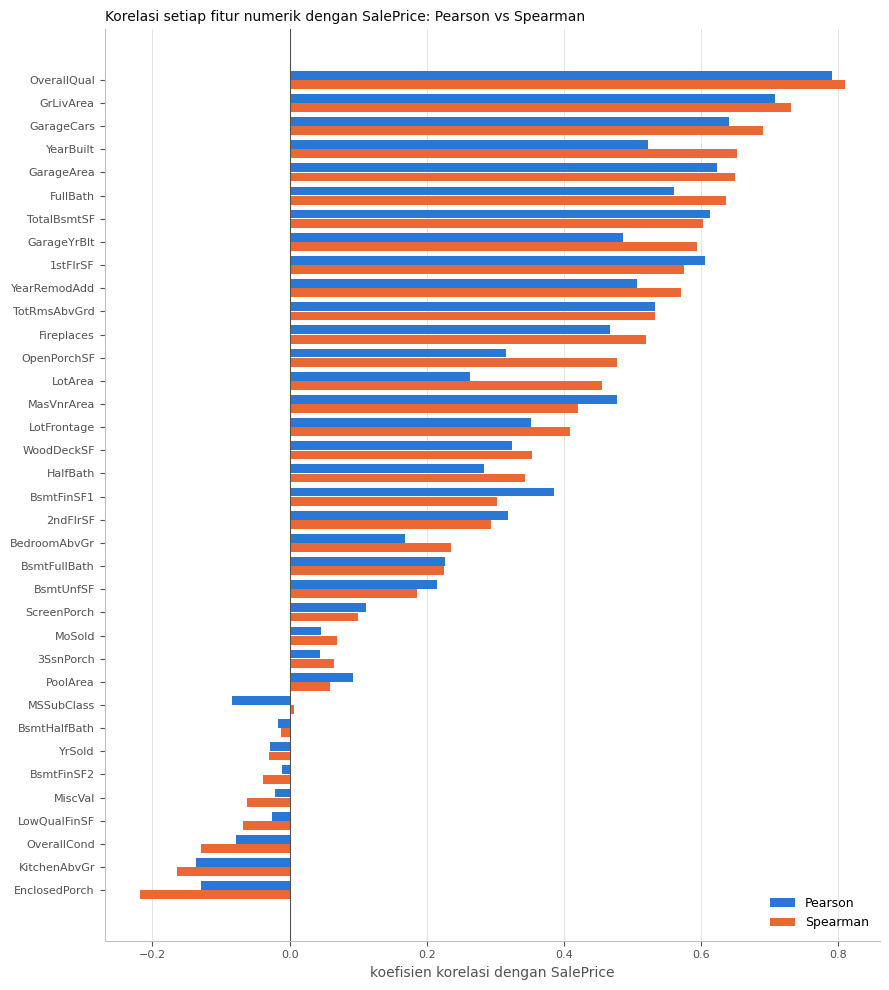

In [18]:
# tabel pasangan fitur (segitiga bawah, setiap pasangan sekali)
tril = np.tril(np.ones(kor_p.shape, dtype=bool), k=-1)
pasangan = kor_p.where(tril).stack().rename('pearson').to_frame()
pasangan['spearman'] = kor_s.where(tril).stack()
pasangan['selisih'] = pasangan['spearman'] - pasangan['pearson']
pasangan.index.names = ['fitur_1', 'fitur_2']
pasangan = pasangan.reset_index()

print('=== Pasangan dengan |Pearson| >= 0.8 (kandidat redundan) ===')
print(pasangan[pasangan['pearson'].abs() >= 0.8]
      .sort_values('pearson', key=abs, ascending=False).round(3).to_string(index=False))

print('\n=== 10 pasangan dengan selisih Spearman - Pearson terbesar ===')
print(pasangan.reindex(pasangan['selisih'].abs().sort_values(ascending=False).index)
      .head(10).round(3).to_string(index=False))

ke_target = pd.DataFrame({'pearson': kor_p['SalePrice'], 'spearman': kor_s['SalePrice']}).drop('SalePrice')
ke_target['selisih'] = ke_target['spearman'] - ke_target['pearson']

fig, ax = plt.subplots(figsize=(9, 10))
plot_df = ke_target.sort_values('spearman')
y = np.arange(len(plot_df))
ax.barh(y + 0.2, plot_df['pearson'], height=0.38, color=BIRU, label='Pearson')
ax.barh(y - 0.2, plot_df['spearman'], height=0.38, color=ORANYE, label='Spearman')
ax.set_yticks(y)
ax.set_yticklabels(plot_df.index)
ax.axvline(0, color=ABU, lw=0.8)
ax.grid(axis='y', visible=False)
ax.grid(axis='x', visible=True)
ax.set_xlabel('koefisien korelasi dengan SalePrice')
ax.legend(loc='lower right')
ax.set_title('Korelasi setiap fitur numerik dengan SalePrice: Pearson vs Spearman', loc='left')
plt.tight_layout()
plt.show()

### notes korelasi
1. Empat pasangan fitur dengan |r| >= 0.8: `GarageArea` - `GarageCars` 0.88, `GarageYrBlt` - `YearBuilt` 0.83, `TotRmsAbvGrd` - `GrLivArea` 0.83, `1stFlrSF` - `TotalBsmtSF` 0.82. Setiap pasangan mengukur hal yang sama (kapasitas garasi, umur bangunan, ukuran rumah), jadi kandidat untuk reduksi.
2. 7 dari 10 selisih Spearman - Pearson terbesar melibatkan `LotArea`, misalnya dengan `LotFrontage` (0.43 -> 0.65) dan `SalePrice` (0.26 -> 0.46). Hubungan monotoniknya ada, tetapi Pearson ditekan oleh beberapa kavling raksasa.
3. `YearBuilt` - `SalePrice`: Spearman 0.65 lebih besar dari Pearson 0.52. Hubungannya tidak linear; harga melonjak untuk rumah yang dibangun setelah sekitar 1990 dan cenderung datar untuk rumah tua.
4. `MSSubClass` r -0.08 bukan berarti tidak berhubungan. Kolom ini nominal (eta 0.50), dan Pearson tidak cocok untuk kode kategori.
5. Korelasi ke target hampir nol (|r| < 0.1): `MoSold`, `YrSold`, `OverallCond`, `BsmtHalfBath`, `BsmtFinSF2`, `LowQualFinSF`, `3SsnPorch`, `PoolArea`, `MiscVal`.
6. Korelasi negatif paling jelas: `KitchenAbvGr` (-0.14) dan `EnclosedPorch` (-0.13). Rumah dengan dua dapur (duplex) dan teras tertutup (ciri rumah tua) cenderung lebih murah.

## 9. Analisis Nilai Hilang

In [19]:
# baca ulang apa adanya (tanpa konversi 'NA'/'None' menjadi NaN) untuk melihat isi asli sel kosong
df_literal = pd.read_csv('train-2.csv', keep_default_na=False)
print('Isi asli MasVnrType:', df_literal['MasVnrType'].value_counts().to_dict())
print('Isi asli PoolQC    :', df_literal['PoolQC'].value_counts().to_dict())

# pembanding: kolom lain yang menunjukkan fasilitasnya memang tidak ada
tanpa_fasilitas = {
    'PoolQC': ('PoolArea == 0', df_raw['PoolArea'] == 0),
    'MiscFeature': ('MiscVal == 0', df_raw['MiscVal'] == 0),
    'Alley': ('definisi data: tidak ada akses gang', pd.Series(True, index=df_raw.index)),
    'Fence': ('definisi data: tidak ada pagar', pd.Series(True, index=df_raw.index)),
    'MasVnrType': ('isi asli "None"', df_literal['MasVnrType'] == 'None'),
    'FireplaceQu': ('Fireplaces == 0', df_raw['Fireplaces'] == 0),
    'LotFrontage': ('-', pd.Series(False, index=df_raw.index)),
    'MasVnrArea': ('-', pd.Series(False, index=df_raw.index)),
    'Electrical': ('-', pd.Series(False, index=df_raw.index)),
}
for c in ['GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageQual', 'GarageCond']:
    tanpa_fasilitas[c] = ('GarageArea == 0', df_raw['GarageArea'] == 0)
for c in ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']:
    tanpa_fasilitas[c] = ('TotalBsmtSF == 0', df_raw['TotalBsmtSF'] == 0)

baris = []
for col, (aturan, kondisi) in tanpa_fasilitas.items():
    kosong = df_raw[col].isna()
    baris.append({'kolom': col, 'n_kosong': kosong.sum(), 'pembanding': aturan,
                  'struktural': (kosong & kondisi).sum(), 'hilang_sebenarnya': (kosong & ~kondisi).sum()})
analisis_kosong = pd.DataFrame(baris).set_index('kolom').sort_values('n_kosong', ascending=False)
analisis_kosong['%_kosong'] = (analisis_kosong['n_kosong'] / len(df_raw) * 100).round(2)
display(analisis_kosong)
print(f'Total sel kosong      : {analisis_kosong["n_kosong"].sum()}')
print(f'  struktural          : {analisis_kosong["struktural"].sum()}')
print(f'  hilang sebenarnya   : {analisis_kosong["hilang_sebenarnya"].sum()}')

Isi asli MasVnrType: {'None': 864, 'BrkFace': 445, 'Stone': 128, 'BrkCmn': 15, 'NA': 8}
Isi asli PoolQC    : {'NA': 1453, 'Gd': 3, 'Ex': 2, 'Fa': 2}


,n_kosong,pembanding,struktural,hilang_sebenarnya,%_kosong
kolom,,,,,
PoolQC,1453,PoolArea == 0,1453,0,99.52
MiscFeature,1406,MiscVal == 0,1406,0,96.30
Alley,1369,definisi data: tidak ada akses gang,1369,0,93.77
Fence,1179,definisi data: tidak ada pagar,1179,0,80.75
MasVnrType,872,"isi asli ""None""",864,8,59.73
FireplaceQu,690,Fireplaces == 0,690,0,47.26
LotFrontage,259,-,0,259,17.74
GarageFinish,81,GarageArea == 0,81,0,5.55
GarageCond,81,GarageArea == 0,81,0,5.55


Total sel kosong      : 7829
  struktural          : 7551
  hilang sebenarnya   : 278


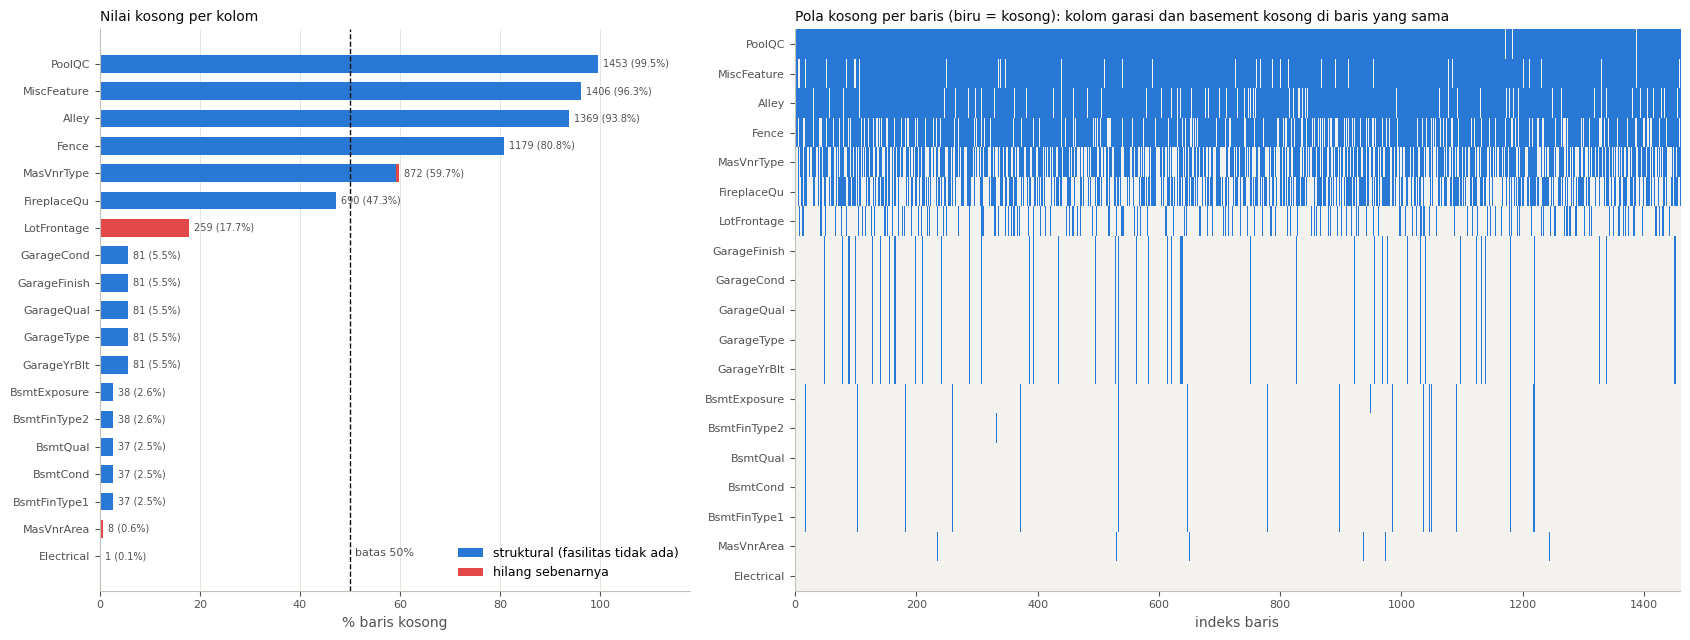

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6.5), gridspec_kw={'width_ratios': [1, 1.5]})

urut = analisis_kosong.sort_values('n_kosong')
pct_struk = urut['struktural'] / len(df_raw) * 100
pct_hilang = urut['hilang_sebenarnya'] / len(df_raw) * 100
axes[0].barh(urut.index, pct_struk, color=BIRU, height=0.65, label='struktural (fasilitas tidak ada)')
axes[0].barh(urut.index, pct_hilang, left=pct_struk, color=MERAH, height=0.65, label='hilang sebenarnya')
axes[0].axvline(50, color=TINTA, lw=1, ls='--')
axes[0].text(51, 0, 'batas 50%', fontsize=8, color=ABU)
for yy, (n, p) in enumerate(zip(urut['n_kosong'], urut['%_kosong'])):
    axes[0].text(p + 1, yy, f'{n} ({p:.1f}%)', va='center', fontsize=7, color=ABU)
axes[0].set_xlim(0, 118)
axes[0].grid(axis='y', visible=False)
axes[0].grid(axis='x', visible=True)
axes[0].set_xlabel('% baris kosong')
axes[0].legend(loc='lower right')
axes[0].set_title('Nilai kosong per kolom', loc='left')

kol_kosong = analisis_kosong.index.tolist()
matriks = df_raw[kol_kosong].isna().to_numpy().T
axes[1].imshow(matriks, aspect='auto', interpolation='nearest', cmap=ListedColormap(['#f3f2ee', BIRU]))
axes[1].set_yticks(range(len(kol_kosong)))
axes[1].set_yticklabels(kol_kosong, fontsize=8)
axes[1].set_xlabel('indeks baris')
axes[1].grid(False)
axes[1].set_title('Pola kosong per baris (biru = kosong): kolom garasi dan basement kosong di baris yang sama',
                  loc='left')
plt.tight_layout()
plt.show()

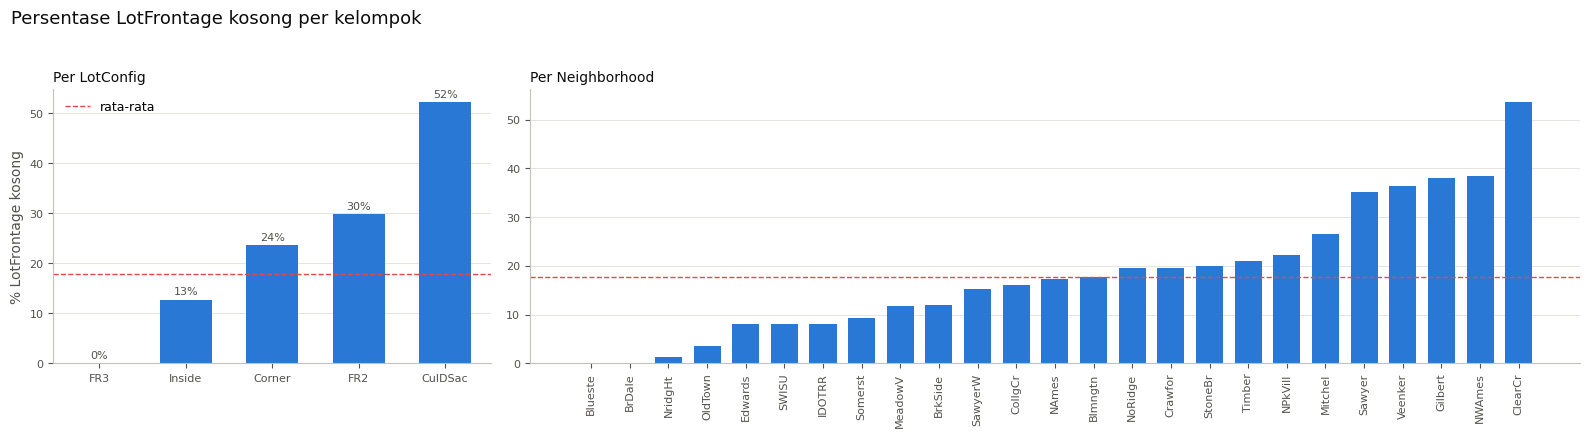

In [21]:
# LotFrontage kosong tidak acak: bergantung pada konfigurasi kavling dan lingkungan
fig, axes = plt.subplots(1, 2, figsize=(16, 4.2), gridspec_kw={'width_ratios': [1, 2.4]})

per_config = df_raw.groupby('LotConfig')['LotFrontage'].apply(lambda s: s.isna().mean() * 100).sort_values()
axes[0].bar(per_config.index, per_config.values, color=BIRU, width=0.6)
for xx, v in enumerate(per_config.values):
    axes[0].text(xx, v + 1, f'{v:.0f}%', ha='center', fontsize=8, color=ABU)
axes[0].axhline(df_raw['LotFrontage'].isna().mean() * 100, color=MERAH, lw=1, ls='--', label='rata-rata')
axes[0].set_ylabel('% LotFrontage kosong')
axes[0].legend()
axes[0].set_title('Per LotConfig', loc='left')

per_nb = df_raw.groupby('Neighborhood')['LotFrontage'].apply(lambda s: s.isna().mean() * 100).sort_values()
axes[1].bar(per_nb.index, per_nb.values, color=BIRU, width=0.7)
axes[1].axhline(df_raw['LotFrontage'].isna().mean() * 100, color=MERAH, lw=1, ls='--')
axes[1].tick_params(axis='x', rotation=90)
axes[1].set_title('Per Neighborhood', loc='left')
judul_figur(fig, 'Persentase LotFrontage kosong per kelompok', y=1.03)
plt.tight_layout()
plt.show()

### notes
1. 19 kolom berisi NaN, total 7829 sel. Sebanyak 7551 sel (96.4%) bersifat struktural: menurut dokumentasi dataset, NA berarti fasilitasnya tidak ada.
2. Bukti struktural dari kolom pembanding: `PoolQC` kosong tepat di 1453 rumah dengan `PoolArea` = 0, `FireplaceQu` di 690 rumah dengan `Fireplaces` = 0, lima kolom garasi di 81 rumah yang sama dengan `GarageArea` = 0, dan lima kolom basement di 37 rumah dengan `TotalBsmtSF` = 0.
3. Yang benar-benar hilang hanya 278 sel: `LotFrontage` 259, `MasVnrArea` 8, `MasVnrType` 8, `BsmtExposure` 1 (Id 949), `BsmtFinType2` 1 (Id 333), `Electrical` 1 (Id 1380).
4. Artefak pembacaan: pandas membaca teks "None" di `MasVnrType` sebagai NaN. Kolom ini tercatat 59.7% kosong, padahal 864 dari 872 adalah kategori "tanpa pelapis batu" dan hanya 8 yang benar-benar kosong.
5. Matriks pola kosong memperlihatkan kolom garasi kosong di baris yang sama, begitu juga kolom basement. Penyebabnya satu (fasilitas tidak ada), bukan kesalahan acak.
6. `LotFrontage` kosong tidak acak: 52% pada kavling CulDSac vs 13% pada Inside, dan per lingkungan dari 0% (Blueste, BrDale) sampai 54% (ClearCr). Imputasi median global kurang tepat; informasi kavling perlu dipakai.
7. Kolom dengan nilai kosong lebih dari 50%: `PoolQC` 99.5%, `MiscFeature` 96.3%, `Alley` 93.8%, `Fence` 80.8%, `MasVnrType` 59.7%.

## 10. Deteksi Outlier dengan Box Plot

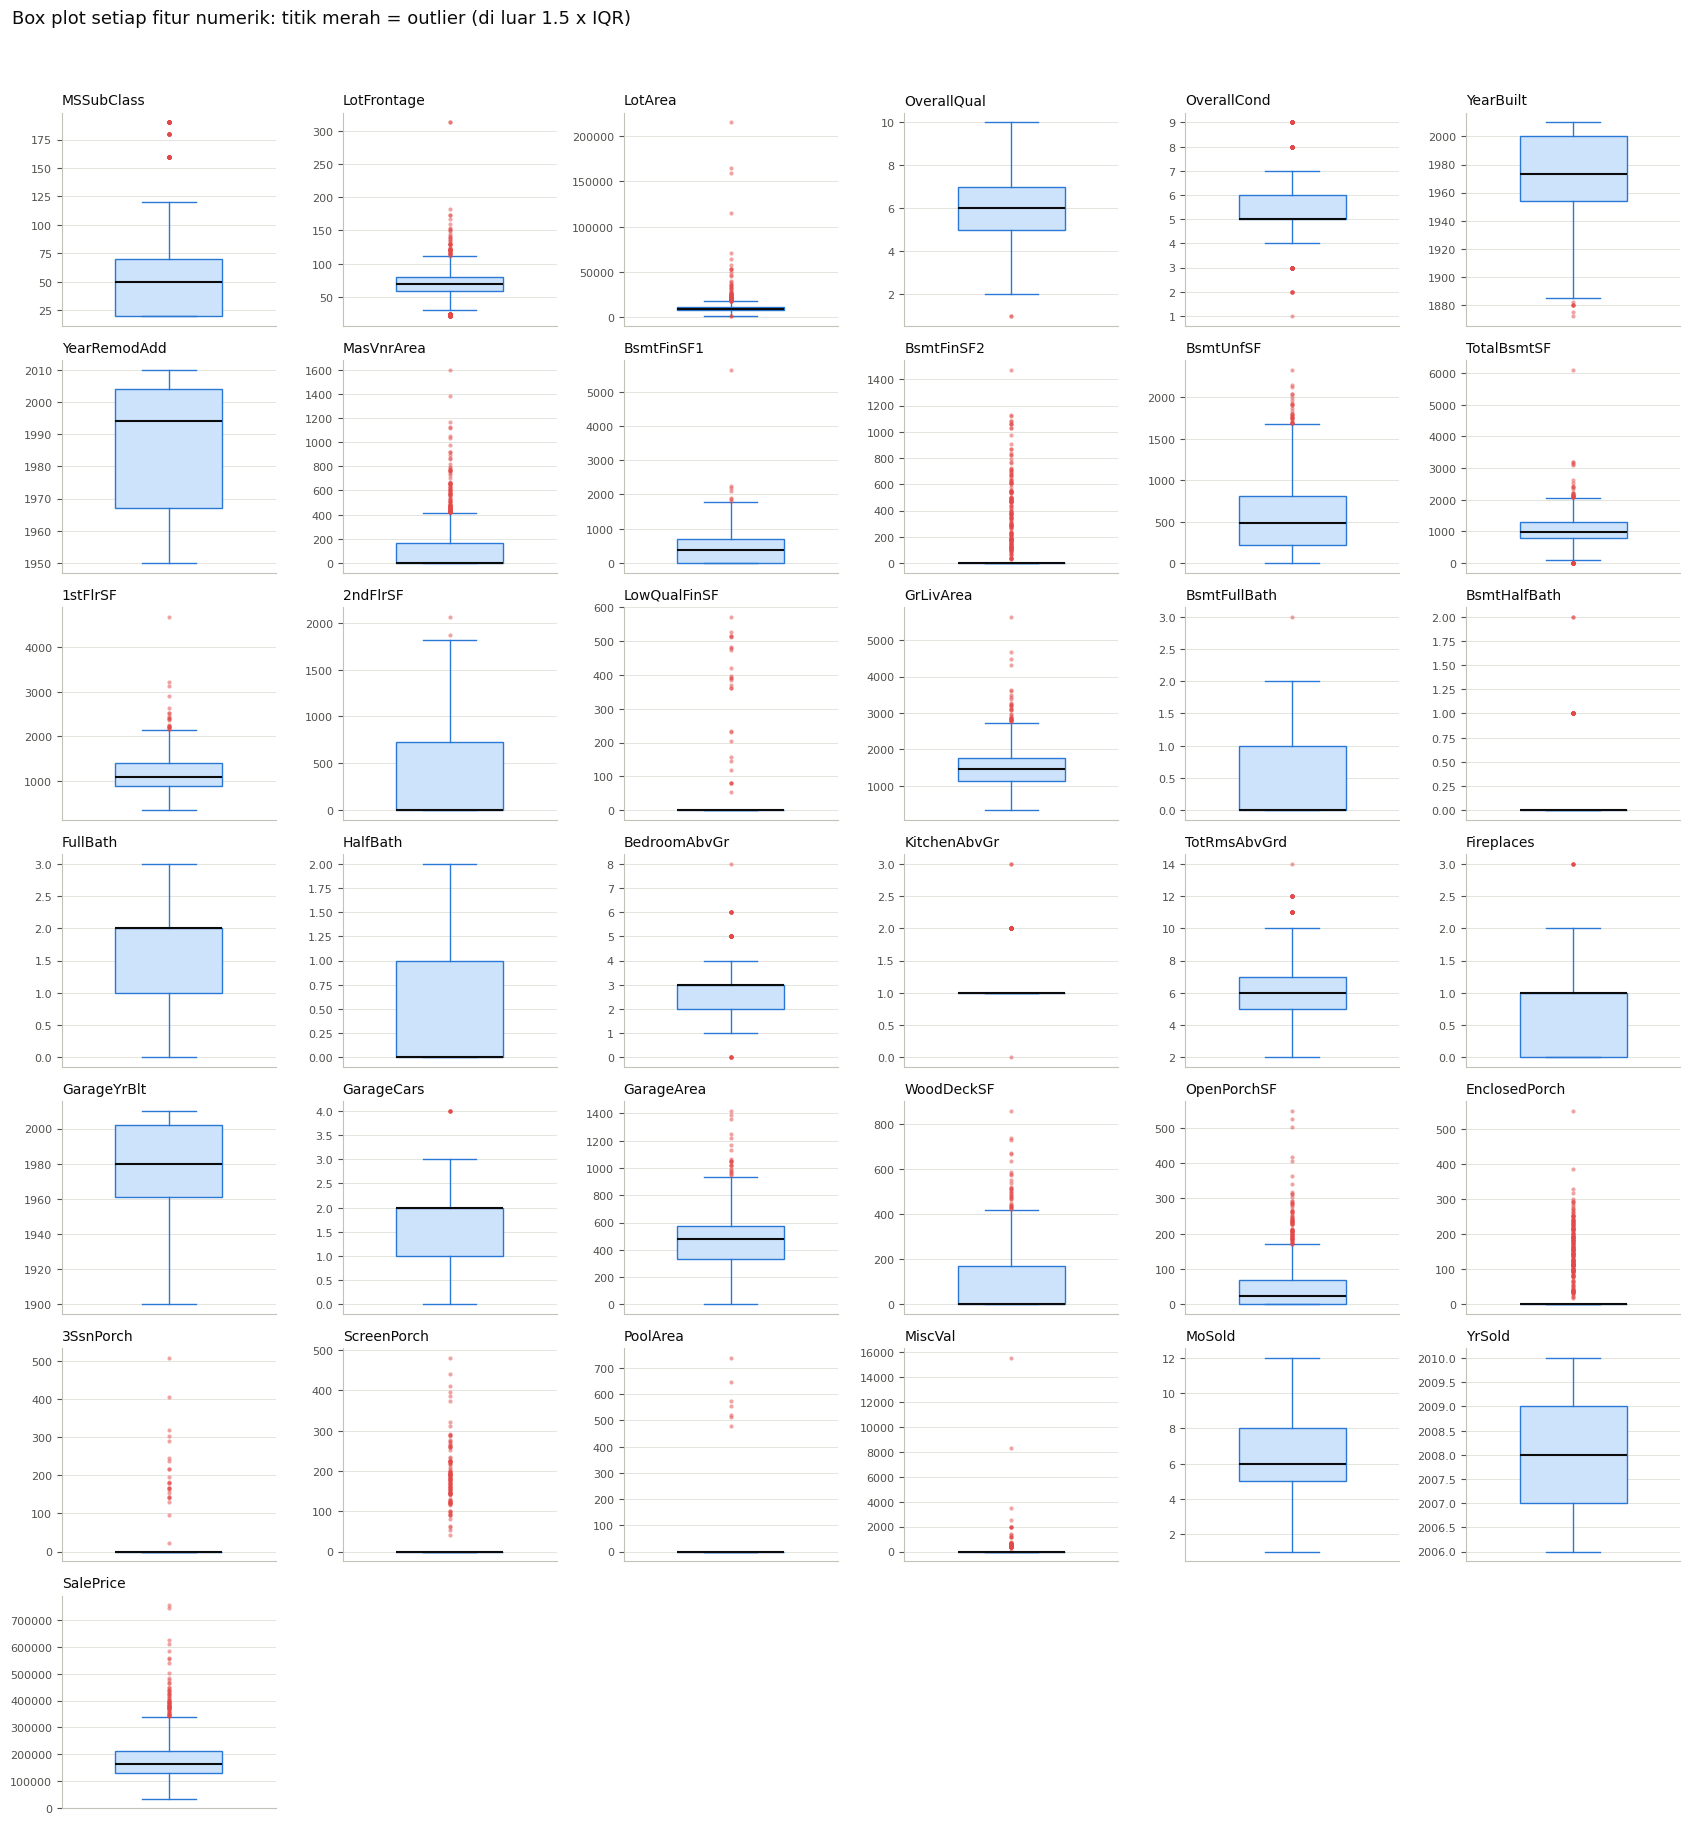

In [22]:
fitur_box = fitur_num          # semua fitur numerik termasuk SalePrice
fig, axes = buat_grid(len(fitur_box), ncols=6, tinggi=2.6, lebar=17)
for ax, col in zip(axes, fitur_box):
    ax.boxplot(df_raw[col].dropna(), widths=0.5, patch_artist=True,
               boxprops=dict(facecolor='#cde2fb', edgecolor=BIRU),
               medianprops=dict(color=TINTA, linewidth=1.5),
               whiskerprops=dict(color=BIRU), capprops=dict(color=BIRU),
               flierprops=dict(marker='o', markersize=3, markerfacecolor=MERAH,
                               markeredgecolor='none', alpha=0.5))
    ax.set_xticks([])
    ax.set_title(col, loc='left')
judul_figur(fig, 'Box plot setiap fitur numerik: titik merah = outlier (di luar 1.5 x IQR)')
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

,sifat,Q1,Q3,IQR,batas_bawah,batas_atas,n_outlier,%_outlier,%_nol,min,max
fitur,,,,,,,,,,,
EnclosedPorch,artefak (IQR = 0),0.00,0.00,0.00,0.00,0.00,208,14.25,85.75,0.0,552.0
BsmtFinSF2,artefak (IQR = 0),0.00,0.00,0.00,0.00,0.00,167,11.44,88.56,0.0,1474.0
OverallCond,nilai langka (diskrit/kode),5.00,6.00,1.00,3.50,7.50,125,8.56,0.00,1.0,9.0
ScreenPorch,artefak (IQR = 0),0.00,0.00,0.00,0.00,0.00,116,7.95,92.05,0.0,480.0
MSSubClass,nilai langka (diskrit/kode),20.00,70.00,50.00,-55.00,145.00,103,7.05,0.00,20.0,190.0
MasVnrArea,nilai ekstrem kontinu,0.00,166.00,166.00,-249.00,415.00,96,6.61,59.30,0.0,1600.0
LotFrontage,nilai ekstrem kontinu,59.00,80.00,21.00,27.50,111.50,88,7.33,0.00,21.0,313.0
BsmtHalfBath,artefak (IQR = 0),0.00,0.00,0.00,0.00,0.00,82,5.62,94.38,0.0,2.0
OpenPorchSF,nilai ekstrem kontinu,0.00,68.00,68.00,-102.00,170.00,77,5.27,44.93,0.0,547.0


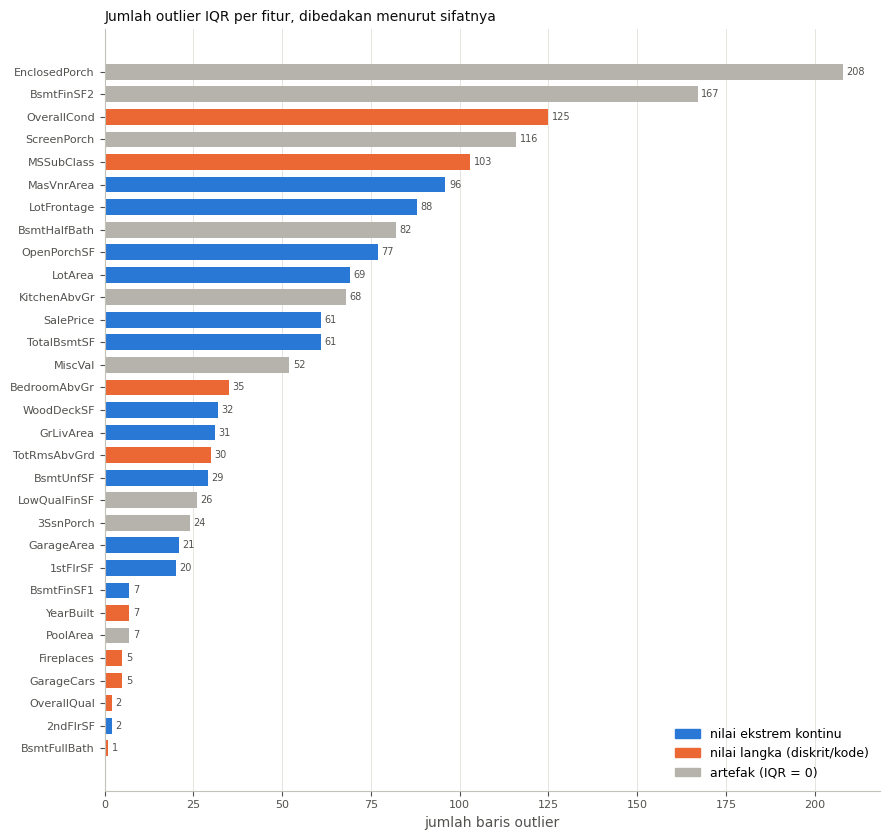

In [23]:
def ringkas_iqr(data, kolom):
    # ringkasan outlier aturan Tukey (1.5 x IQR) untuk setiap kolom
    baris = []
    for col in kolom:
        s = data[col].dropna()
        q1, q3 = s.quantile([0.25, 0.75])
        iqr = q3 - q1
        bawah, atas = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        out = s[(s < bawah) | (s > atas)]
        if iqr == 0:
            sifat = 'artefak (IQR = 0)'
        elif JENIS.get(col, '').startswith('numerik kontinu') or col == 'SalePrice':
            sifat = 'nilai ekstrem kontinu'
        else:
            sifat = 'nilai langka (diskrit/kode)'
        baris.append({'fitur': col, 'sifat': sifat, 'Q1': q1, 'Q3': q3, 'IQR': iqr,
                      'batas_bawah': bawah, 'batas_atas': atas, 'n_outlier': len(out),
                      '%_outlier': len(out) / len(s) * 100, '%_nol': (s == 0).mean() * 100,
                      'min': s.min(), 'max': s.max()})
    return pd.DataFrame(baris).set_index('fitur')


iqr_mentah = ringkas_iqr(df_raw, fitur_box).sort_values('n_outlier', ascending=False)
display(iqr_mentah.round(2))

WARNA_SIFAT = {'nilai ekstrem kontinu': BIRU, 'nilai langka (diskrit/kode)': ORANYE, 'artefak (IQR = 0)': ABU_MUDA}
plot_df = iqr_mentah[iqr_mentah['n_outlier'] > 0].sort_values('n_outlier')
fig, ax = plt.subplots(figsize=(9, 8.5))
ax.barh(plot_df.index, plot_df['n_outlier'], color=plot_df['sifat'].map(WARNA_SIFAT), height=0.7)
for yy, v in enumerate(plot_df['n_outlier']):
    ax.text(v + 1, yy, str(v), va='center', fontsize=7, color=ABU)
ax.grid(axis='y', visible=False)
ax.grid(axis='x', visible=True)
ax.set_xlabel('jumlah baris outlier')
ax.legend(handles=[Patch(color=w, label=s) for s, w in WARNA_SIFAT.items()], loc='lower right')
ax.set_title('Jumlah outlier IQR per fitur, dibedakan menurut sifatnya', loc='left')
plt.tight_layout()
plt.show()

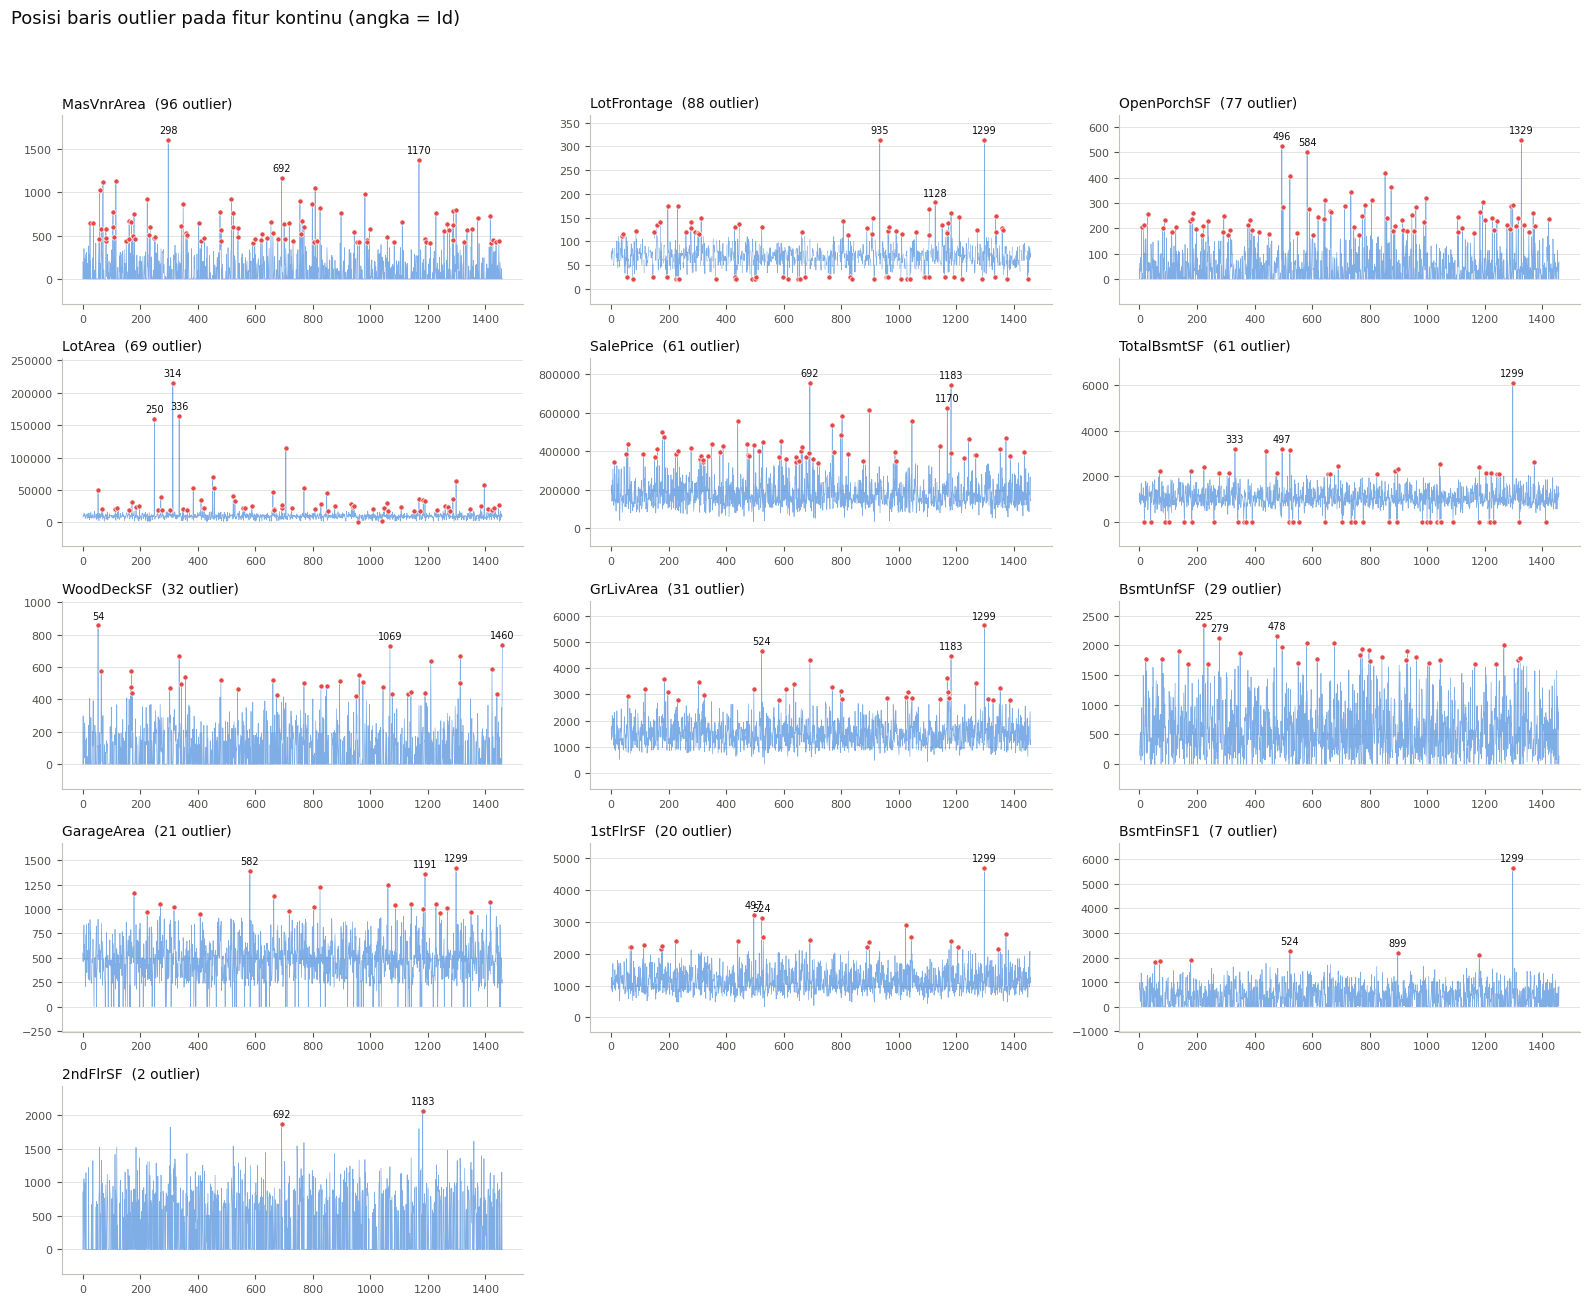

In [24]:
# posisi outlier pada fitur kontinu; angka = Id tiga nilai paling ekstrem
kontinu_out = iqr_mentah[(iqr_mentah['sifat'] == 'nilai ekstrem kontinu') & (iqr_mentah['n_outlier'] > 0)].index

fig, axes = buat_grid(len(kontinu_out), ncols=3, tinggi=2.6)
for ax, col in zip(axes, kontinu_out):
    batas = iqr_mentah.loc[col, ['batas_bawah', 'batas_atas']]
    s = df_raw[col]
    m = (s < batas['batas_bawah']) | (s > batas['batas_atas'])
    ax.plot(df_raw.index, s, color=BIRU, lw=0.5, alpha=0.6)
    ax.scatter(df_raw.index[m], s[m], s=14, color=MERAH, edgecolors='white', linewidths=0.5, zorder=3)
    for i in s[m].nlargest(3).index:
        ax.annotate(str(df_raw.at[i, 'Id']), (i, s[i]), textcoords='offset points', xytext=(0, 5),
                    ha='center', fontsize=7, color=TINTA)
    ax.margins(y=0.18)
    ax.set_title(f'{col}  ({m.sum()} outlier)', loc='left')
judul_figur(fig, 'Posisi baris outlier pada fitur kontinu (angka = Id)')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

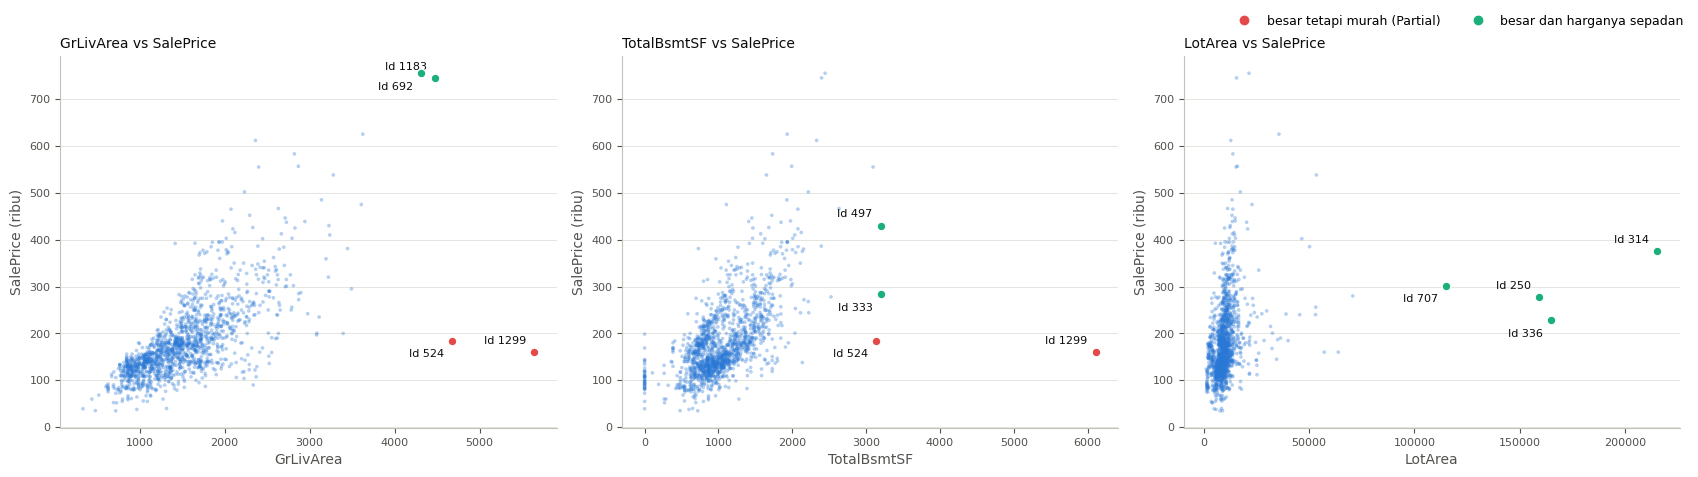

Baris dengan minimal satu outlier kontinu: 387 dari 1460


,Id,n_fitur_outlier,fitur,GrLivArea,TotalBsmtSF,LotArea,OverallQual,SaleCondition,SalePrice
1298,1299,9,"MasVnrArea, LotFrontage, OpenPorchSF, LotArea,...",5642,6110,63887,10,Partial,160000
523,524,8,"MasVnrArea, LotFrontage, OpenPorchSF, LotArea,...",4676,3138,40094,10,Partial,184750
691,692,7,"MasVnrArea, LotArea, SalePrice, TotalBsmtSF, G...",4316,2444,21535,10,Normal,755000
1182,1183,7,"LotFrontage, SalePrice, TotalBsmtSF, GrLivArea...",4476,2396,15623,10,Abnorml,745000
178,179,6,"MasVnrArea, SalePrice, TotalBsmtSF, GarageArea...",2234,2216,17423,9,Partial,501837
224,225,6,"MasVnrArea, SalePrice, TotalBsmtSF, BsmtUnfSF,...",2392,2392,13472,10,Normal,386250
496,497,5,"SalePrice, TotalBsmtSF, GrLivArea, BsmtUnfSF, ...",3228,3200,12692,8,Normal,430000
664,665,5,"OpenPorchSF, LotArea, SalePrice, TotalBsmtSF, ...",2097,2077,20896,8,Partial,423000


In [25]:
# hubungan luas dengan harga: rumah besar yang harganya justru rendah
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
for ax, col in zip(axes, ['GrLivArea', 'TotalBsmtSF', 'LotArea']):
    ax.scatter(df_raw[col], df_raw['SalePrice'] / 1000, s=7, color=BIRU, alpha=0.35, edgecolors='none')
    for urutan, i in enumerate(df_raw[col].nlargest(4).index):
        janggal = df_raw.at[i, 'SaleCondition'] == 'Partial' and df_raw.at[i, 'SalePrice'] < 300000
        ax.scatter(df_raw.at[i, col], df_raw.at[i, 'SalePrice'] / 1000, s=40,
                   color=MERAH if janggal else AQUA, edgecolors='white', zorder=3)
        ax.annotate(f"Id {df_raw.at[i, 'Id']}", (df_raw.at[i, col], df_raw.at[i, 'SalePrice'] / 1000),
                    textcoords='offset points', xytext=(-6, 6 if urutan % 2 == 0 else -12),
                    ha='right', fontsize=8, color=TINTA)
    ax.set_xlabel(col)
    ax.set_ylabel('SalePrice (ribu)')
    ax.set_title(f'{col} vs SalePrice', loc='left')
fig.legend(handles=[Line2D([], [], color=MERAH, marker='o', ls='none', label='besar tetapi murah (Partial)'),
                    Line2D([], [], color=AQUA, marker='o', ls='none', label='besar dan harganya sepadan')],
           loc='upper right', ncol=2, bbox_to_anchor=(1, 1.04))
plt.tight_layout()
plt.show()

# baris yang menjadi outlier di banyak fitur kontinu sekaligus
flag = pd.DataFrame({col: (df_raw[col] < iqr_mentah.loc[col, 'batas_bawah']) |
                          (df_raw[col] > iqr_mentah.loc[col, 'batas_atas']) for col in kontinu_out})
banyak = flag.sum(axis=1)
tabel_banyak = df_raw.loc[banyak.nlargest(8).index, ['Id', 'GrLivArea', 'TotalBsmtSF', 'LotArea',
                                                     'OverallQual', 'SaleCondition', 'SalePrice']]
tabel_banyak.insert(1, 'n_fitur_outlier', banyak[tabel_banyak.index])
tabel_banyak.insert(2, 'fitur', flag.loc[tabel_banyak.index].apply(lambda r: ', '.join(r.index[r]), axis=1))
print(f'Baris dengan minimal satu outlier kontinu: {(banyak > 0).sum()} dari {len(df_raw)}')
display(tabel_banyak)

### notes outlier
1. Jumlah outlier IQR menyesatkan bila dibaca mentah. Sembilan fitur (`EnclosedPorch` 208, `BsmtFinSF2` 167, `ScreenPorch` 116, `BsmtHalfBath` 82, `KitchenAbvGr` 68, `MiscVal` 52, `LowQualFinSF` 26, `3SsnPorch` 24, `PoolArea` 7) memiliki IQR = 0 karena didominasi satu nilai, sehingga semua nilai selain nilai dominan otomatis dianggap outlier. Ini artefak metode.
2. Pada fitur diskrit dan kode (`OverallCond` 125, `MSSubClass` 103, `BedroomAbvGr` 35, `TotRmsAbvGrd` 30), "outlier" hanyalah kategori atau hitungan yang jarang, bukan nilai ekstrem.
3. Outlier kontinu yang bermakna: `MasVnrArea` 96, `LotFrontage` 88, `OpenPorchSF` 77, `LotArea` 69, `SalePrice` 61, `TotalBsmtSF` 61. Sebanyak 387 baris memiliki minimal satu outlier kontinu.
4. Id 1299 dan 524 menjadi outlier di 9 dan 8 fitur sekaligus. Keduanya ber-`OverallQual` 10 dengan `GrLivArea` 5642 dan 4676 sqft, dijual dengan kondisi Partial (rumah baru yang belum selesai), dan harganya hanya 160000 dan 184750.
5. Id 692 dan 1183 juga sangat besar, tetapi harganya sepadan (755000 dan 745000). Rumah besar tidak otomatis anomali.
6. Empat kavling di atas 100000 sqft (Id 314, 336, 250, 707) berada di Timber dan ClearCr dengan harga 229000 - 375000. Nilainya nyata (kavling pinggiran), tetapi harga tidak naik sebanding luasnya.

## 11. Pemeriksaan Konsistensi Data

,n_pelanggaran,Id
YearRemodAdd < YearBuilt,0,
YrSold < YearBuilt,0,
YrSold < YearRemodAdd,1,524
GarageYrBlt < YearBuilt,9,"30, 94, 325, 601, 737, 1104, 1377, 1415, 1419"
GarageYrBlt > YrSold,0,
TotalBsmtSF != BsmtFinSF1 + BsmtFinSF2 + BsmtUnfSF,0,
GrLivArea != 1stFlrSF + 2ndFlrSF + LowQualFinSF,0,
GarageCars > 0 tetapi GarageArea = 0,0,
Fireplaces > 0 tetapi FireplaceQu kosong,0,
PoolArea > 0 tetapi PoolQC kosong,0,


Label Exterior (sisi rumah pertama vs kedua):
  hanya di Exterior1st: ['BrkComm', 'CemntBd', 'WdShing']
  hanya di Exterior2nd: ['Brk Cmn', 'CmentBd', 'Other', 'Wd Shng']
  Exterior1st == Exterior2nd pada 85.3% rumah
  Id  MasVnrArea
 625       288.0
 774         1.0
1231         1.0
1301       344.0
1335       312.0


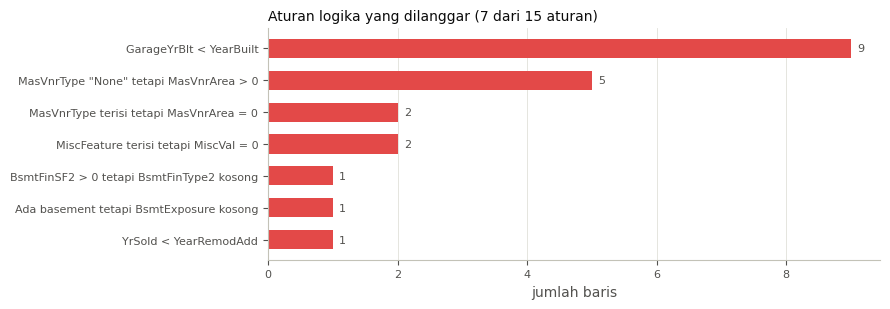

In [26]:
d = df_raw
aturan = {
    'YearRemodAdd < YearBuilt': d['YearRemodAdd'] < d['YearBuilt'],
    'YrSold < YearBuilt': d['YrSold'] < d['YearBuilt'],
    'YrSold < YearRemodAdd': d['YrSold'] < d['YearRemodAdd'],
    'GarageYrBlt < YearBuilt': d['GarageYrBlt'] < d['YearBuilt'],
    'GarageYrBlt > YrSold': d['GarageYrBlt'] > d['YrSold'],
    'TotalBsmtSF != BsmtFinSF1 + BsmtFinSF2 + BsmtUnfSF':
        d['TotalBsmtSF'] != d['BsmtFinSF1'] + d['BsmtFinSF2'] + d['BsmtUnfSF'],
    'GrLivArea != 1stFlrSF + 2ndFlrSF + LowQualFinSF':
        d['GrLivArea'] != d['1stFlrSF'] + d['2ndFlrSF'] + d['LowQualFinSF'],
    'GarageCars > 0 tetapi GarageArea = 0': (d['GarageCars'] > 0) & (d['GarageArea'] == 0),
    'Fireplaces > 0 tetapi FireplaceQu kosong': (d['Fireplaces'] > 0) & d['FireplaceQu'].isna(),
    'PoolArea > 0 tetapi PoolQC kosong': (d['PoolArea'] > 0) & d['PoolQC'].isna(),
    'MiscFeature terisi tetapi MiscVal = 0': d['MiscFeature'].notna() & (d['MiscVal'] == 0),
    'MasVnrType "None" tetapi MasVnrArea > 0': (df_literal['MasVnrType'] == 'None') & (d['MasVnrArea'] > 0),
    'MasVnrType terisi tetapi MasVnrArea = 0': d['MasVnrType'].notna() & (d['MasVnrArea'] == 0),
    'Ada basement tetapi BsmtExposure kosong': (d['TotalBsmtSF'] > 0) & d['BsmtExposure'].isna(),
    'BsmtFinSF2 > 0 tetapi BsmtFinType2 kosong': (d['BsmtFinSF2'] > 0) & d['BsmtFinType2'].isna(),
}
cek_konsisten = pd.DataFrame({
    'n_pelanggaran': {k: int(v.sum()) for k, v in aturan.items()},
    'Id': {k: ', '.join(map(str, d.loc[v, 'Id'].head(9))) for k, v in aturan.items()},
})
display(cek_konsisten)

print('Label Exterior (sisi rumah pertama vs kedua):')
print('  hanya di Exterior1st:', sorted(set(d['Exterior1st']) - set(d['Exterior2nd'])))
print('  hanya di Exterior2nd:', sorted(set(d['Exterior2nd']) - set(d['Exterior1st'])))
print(f"  Exterior1st == Exterior2nd pada {(d['Exterior1st'] == d['Exterior2nd']).mean():.1%} rumah")
print(d.loc[aturan['MasVnrType "None" tetapi MasVnrArea > 0'], ['Id', 'MasVnrArea']].to_string(index=False))

langgar = cek_konsisten[cek_konsisten['n_pelanggaran'] > 0].sort_values('n_pelanggaran')
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.barh(langgar.index, langgar['n_pelanggaran'], color=MERAH, height=0.6)
for yy, v in enumerate(langgar['n_pelanggaran']):
    ax.text(v + 0.1, yy, str(v), va='center', fontsize=8, color=ABU)
ax.grid(axis='y', visible=False)
ax.grid(axis='x', visible=True)
ax.set_xlabel('jumlah baris')
ax.set_title(f'Aturan logika yang dilanggar ({len(langgar)} dari {len(cek_konsisten)} aturan)', loc='left')
plt.tight_layout()
plt.show()

### notes
1. Aturan penjumlahan terpenuhi di semua baris: `TotalBsmtSF` = `BsmtFinSF1` + `BsmtFinSF2` + `BsmtUnfSF` dan `GrLivArea` = `1stFlrSF` + `2ndFlrSF` + `LowQualFinSF`.
2. Id 524 tercatat direnovasi 2008 tetapi terjual 2007. Baris ini sama dengan salah satu anomali harga dan dijual Partial, jadi kemungkinan transaksi sebelum rumah selesai dibangun.
3. Label salah tulis di `Exterior2nd`: "Brk Cmn", "CmentBd", "Wd Shng" seharusnya "BrkComm", "CemntBd", "WdShing" seperti di `Exterior1st`. Tanpa diperbaiki, one-hot akan membuat dua kolom berbeda untuk material yang sama.
4. `MasVnrType` "None" tetapi `MasVnrArea` > 0 di 5 rumah. Dua di antaranya bernilai 1 sqft (Id 774, 1231), jelas salah input; tiga lainnya 288-344 sqft, kemungkinan tipe pelapisnya tidak tercatat.
5. `GarageYrBlt` < `YearBuilt` di 9 rumah dengan selisih 1-10 tahun. Masuk akal bila garasi lama dipertahankan saat rumah dibangun ulang, jadi tidak diubah.
6. `MiscFeature` terisi tetapi `MiscVal` = 0 di Id 874 dan 1201. Kolom `MiscFeature` akan dibuang karena lebih dari 50% kosong, jadi tidak ditangani terpisah.

## 12. Ringkasan Masalah untuk Tahap Praproses

1. Nilai kosong: 5 kolom kosong lebih dari 50% (dibuang sesuai instruksi); NA struktural pada garasi, basement, dan perapian (diisi "Tidak Ada"); hilang sebenarnya pada `LotFrontage` (imputasi memakai informasi kavling), `MasVnrArea`, `Electrical`, `BsmtExposure`, `BsmtFinType2`.
2. Data tidak konsisten: label `Exterior2nd`, `MasVnrArea` 1 sqft, dan tahun renovasi Id 524.
3. Anomali: Id 524 dan 1299 (sangat besar, murah, dijual Partial).
4. Nilai ekstrem valid berekor panjang, terutama `LotArea` (skew 12.2), perlu dievaluasi untuk capping. Fitur yang didominasi nol tidak diperlakukan sebagai outlier.
5. Target miring (skew 1.88) sehingga perlu log1p.
6. Fitur hampir konstan: `Utilities`, `Street`, `Condition2`, `RoofMatl`, `Heating`, `PoolArea`.
7. Fitur redundan: `GarageCars` / `GarageArea`, `YearBuilt` / `GarageYrBlt`, `GrLivArea` / `TotRmsAbvGrd`, `TotalBsmtSF` / `1stFlrSF`.
8. Tipe data: `MSSubClass` harus diperlakukan sebagai nominal (one-hot), `OverallQual` / `OverallCond` tetap angka berurutan, dan 15 kolom ordinal teks perlu dipetakan ke angka sesuai urutannya.

# Praproses Data

## Langkah 2 - Pembersihan Data

### 2.1 Duplikat

In [27]:
df = df_raw.copy()
jejak = [('data mentah', *df.shape, int(df.isna().sum().sum()))]

print(f'Baris duplikat penuh          : {df.duplicated().sum()}')
print(f'Baris duplikat tanpa kolom Id : {df.drop(columns="Id").duplicated().sum()}')
print(f'Id unik                       : {df["Id"].is_unique}')

Baris duplikat penuh          : 0
Baris duplikat tanpa kolom Id : 0
Id unik                       : True


### 2.2 Hapus kolom dengan nilai hilang lebih dari 50%

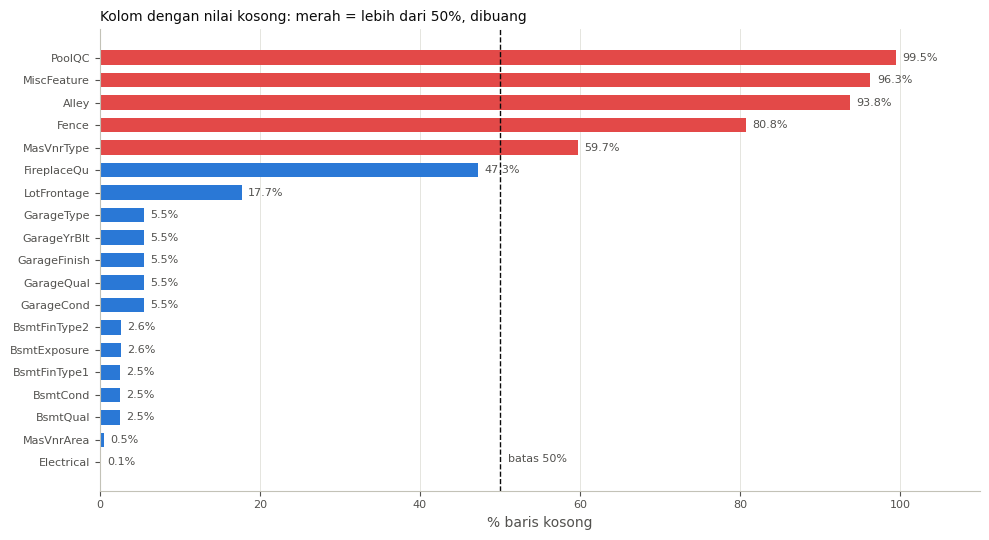

,%_kosong,n_terisi,eta_ke_SalePrice,kolom_pengganti,r_pengganti_ke_SalePrice
PoolQC,99.52,7,0.146,PoolArea,0.092
MiscFeature,96.30,54,0.084,MiscVal,-0.021
Alley,93.77,91,0.143,-,NaN
Fence,80.75,281,0.189,-,NaN
MasVnrType,59.73,588,0.428,MasVnrArea,0.477


Kolom dibuang: ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType']
Ukuran data  : (1460, 76)


In [28]:
persen_kosong = df.isna().mean().mul(100)
persen_kosong = persen_kosong[persen_kosong > 0].sort_values()
DIBUANG_50 = persen_kosong[persen_kosong > 50].sort_values(ascending=False).index.tolist()

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.barh(persen_kosong.index, persen_kosong.values, height=0.65,
        color=[MERAH if p > 50 else BIRU for p in persen_kosong])
ax.axvline(50, color=TINTA, lw=1, ls='--')
ax.text(51, 0, 'batas 50%', fontsize=8, color=ABU)
for yy, p in enumerate(persen_kosong.values):
    ax.text(p + 0.8, yy, f'{p:.1f}%', va='center', fontsize=8, color=ABU)
ax.set_xlim(0, 110)
ax.grid(axis='y', visible=False)
ax.grid(axis='x', visible=True)
ax.set_xlabel('% baris kosong')
ax.set_title('Kolom dengan nilai kosong: merah = lebih dari 50%, dibuang', loc='left')
plt.tight_layout()
plt.show()

# informasi yang masih tersimpan di kolom lain setelah kolom dibuang
pengganti = {'PoolQC': 'PoolArea', 'MiscFeature': 'MiscVal', 'MasVnrType': 'MasVnrArea',
             'Alley': '-', 'Fence': '-'}
info_dibuang = pd.DataFrame({
    '%_kosong': persen_kosong[DIBUANG_50].round(2),
    'n_terisi': df[DIBUANG_50].notna().sum(),
    'eta_ke_SalePrice': eta[DIBUANG_50].round(3),
    'kolom_pengganti': pd.Series(pengganti),
    'r_pengganti_ke_SalePrice': pd.Series({k: round(df[v].corr(df['SalePrice']), 3)
                                           for k, v in pengganti.items() if v != '-'}),
}).loc[DIBUANG_50]
display(info_dibuang)

df = df.drop(columns=DIBUANG_50)
jejak.append(('buang kolom kosong > 50%', *df.shape, int(df.isna().sum().sum())))
print(f'Kolom dibuang: {DIBUANG_50}')
print(f'Ukuran data  : {df.shape}')

### notes
1. Lima kolom dibuang: `PoolQC` 99.5%, `MiscFeature` 96.3%, `Alley` 93.8%, `Fence` 80.8%, `MasVnrType` 59.7%. `FireplaceQu` (47.3%) tepat di bawah batas dan dipertahankan.
2. Informasi yang hilang kecil. `PoolQC`, `MiscFeature`, dan `MasVnrType` punya kolom pengganti numerik (`PoolArea`, `MiscVal`, `MasVnrArea`) yang tetap menyimpan ada atau tidaknya fasilitas.
3. `Alley` dan `Fence` tidak punya pengganti, tetapi hubungannya dengan harga lemah (eta 0.14 dan 0.19).
4. Catatan untuk `MasVnrType`: kosong sebenarnya hanya 0.5% (lihat bagian 9) dan eta-nya 0.43. Kolom ini tetap dibuang agar mengikuti aturan tugas, dan sebagian besar informasinya terwakili oleh `MasVnrArea` (r 0.48).

### 2.3 Nilai kosong struktural: fasilitas tidak ada

In [29]:
TIDAK_ADA = 'Tidak Ada'
GARASI_KAT = ['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond']
BSMT_KAT = ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']

tanpa_garasi = df['GarageArea'] == 0
tanpa_bsmt = df['TotalBsmtSF'] == 0
tanpa_perapian = df['Fireplaces'] == 0

kosong_sebelum = df.isna().sum()
for kolom, tanpa in [(GARASI_KAT, tanpa_garasi), (BSMT_KAT, tanpa_bsmt), (['FireplaceQu'], tanpa_perapian)]:
    for c in kolom:
        df.loc[tanpa & df[c].isna(), c] = TIDAK_ADA

# tahun garasi untuk rumah tanpa garasi diisi tahun rumah dibangun (tidak ada tahun garasi yang bermakna)
isi_tahun = tanpa_garasi & df['GarageYrBlt'].isna()
df.loc[isi_tahun, 'GarageYrBlt'] = df.loc[isi_tahun, 'YearBuilt']

kolom_diubah = kosong_sebelum[kosong_sebelum > 0].index
hasil_struktural = pd.DataFrame({'kosong_sebelum': kosong_sebelum[kolom_diubah],
                                 'kosong_sesudah': df[kolom_diubah].isna().sum()})
hasil_struktural['diisi'] = hasil_struktural['kosong_sebelum'] - hasil_struktural['kosong_sesudah']
display(hasil_struktural.sort_values('kosong_sebelum', ascending=False))
jejak.append(('isi NA struktural', *df.shape, int(df.isna().sum().sum())))

,kosong_sebelum,kosong_sesudah,diisi
FireplaceQu,690,0,690
LotFrontage,259,259,0
GarageType,81,0,81
GarageYrBlt,81,0,81
GarageFinish,81,0,81
GarageQual,81,0,81
GarageCond,81,0,81
BsmtExposure,38,1,37
BsmtFinType2,38,1,37
BsmtQual,37,0,37


### 2.4 Nilai hilang sebenarnya

,MAE_rata2,MAE_std
KNN (LotArea + luas bangunan),11.28,1.00
KNN (LotArea),12.04,1.01
median per Neighborhood,12.78,1.24
median global,16.42,1.06


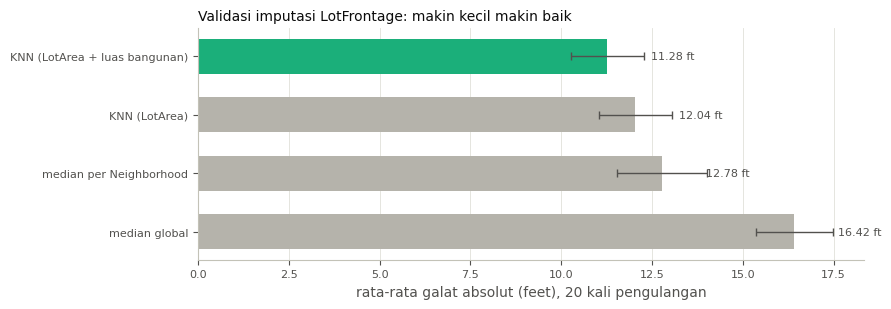

In [30]:
# validasi metode imputasi LotFrontage: sembunyikan 20% nilai yang diketahui, isi, bandingkan dengan aslinya
FITUR_KNN = ['LotArea', '1stFlrSF', 'GrLivArea', 'GarageArea', 'TotalBsmtSF']
Z = df[FITUR_KNN].copy()
Z['LotArea'] = np.log(Z['LotArea'])          # LotArea sangat miring, log agar jarak KNN tidak didominasi kavling raksasa
Z = (Z - Z.mean()) / Z.std()


def isi_knn(kolom_bantu, idx_uji):
    m = Z[kolom_bantu].copy()
    m['LotFrontage'] = df['LotFrontage']
    m.loc[idx_uji, 'LotFrontage'] = np.nan
    hasil = KNNImputer(n_neighbors=5).fit_transform(m)[:, -1]
    return pd.Series(hasil, index=m.index).loc[idx_uji]


diketahui = df.index[df['LotFrontage'].notna()]
rng = np.random.default_rng(42)
skor = {}
for ulang in range(20):
    uji = rng.choice(diketahui, size=int(0.2 * len(diketahui)), replace=False)
    latih = diketahui.difference(uji)
    asli = df.loc[uji, 'LotFrontage']
    median_latih = df.loc[latih, 'LotFrontage'].median()
    tebakan = {
        'median global': pd.Series(median_latih, index=uji),
        'median per Neighborhood': df.loc[uji, 'Neighborhood']
            .map(df.loc[latih].groupby('Neighborhood')['LotFrontage'].median()).fillna(median_latih),
        'KNN (LotArea)': isi_knn(['LotArea'], uji),
        'KNN (LotArea + luas bangunan)': isi_knn(FITUR_KNN, uji),
    }
    for nama, t in tebakan.items():
        skor.setdefault(nama, []).append((t - asli).abs().mean())

mae = pd.DataFrame({'MAE_rata2': {k: np.mean(v) for k, v in skor.items()},
                    'MAE_std': {k: np.std(v) for k, v in skor.items()}}).sort_values('MAE_rata2')
display(mae.round(2))

fig, ax = plt.subplots(figsize=(9, 3.2))
plot_df = mae.sort_values('MAE_rata2', ascending=False)
warna = [AQUA if k == mae.index[0] else ABU_MUDA for k in plot_df.index]
ax.barh(plot_df.index, plot_df['MAE_rata2'], xerr=plot_df['MAE_std'], color=warna, height=0.6,
        error_kw=dict(ecolor=ABU, lw=1, capsize=3))
for yy, v in enumerate(plot_df['MAE_rata2']):
    ax.text(v + 1.2, yy, f'{v:.2f} ft', va='center', fontsize=8, color=ABU)
ax.grid(axis='y', visible=False)
ax.grid(axis='x', visible=True)
ax.set_xlabel('rata-rata galat absolut (feet), 20 kali pengulangan')
ax.set_title('Validasi imputasi LotFrontage: makin kecil makin baik', loc='left')
plt.tight_layout()
plt.show()

In [ ]:
catatan_imputasi = []

# LotFrontage: metode terbaik dari validasi di atas
kosong_lf = df['LotFrontage'].isna()
m = Z[FITUR_KNN].copy()
m['LotFrontage'] = df['LotFrontage']
df['LotFrontage'] = np.round(KNNImputer(n_neighbors=5).fit_transform(m)[:, -1])
catatan_imputasi.append(('LotFrontage', int(kosong_lf.sum()), 'KNN (k=5) dari LotArea + luas bangunan', '-'))

# MasVnrArea: 8 baris yang MasVnrType-nya juga kosong ('NA') -> dianggap tanpa pelapis
kosong_vnr = df['MasVnrArea'].isna()
df.loc[kosong_vnr, 'MasVnrArea'] = 0
catatan_imputasi.append(('MasVnrArea', int(kosong_vnr.sum()), '0 (nilai tersering, tipe juga kosong)',
                         ', '.join(map(str, df.loc[kosong_vnr, 'Id']))))

# Electrical: 1 baris; rumah dibangun 2006
kosong_el = df['Electrical'].isna()
nilai_el = df.loc[df['YearBuilt'] >= 2000, 'Electrical'].mode()[0]
df.loc[kosong_el, 'Electrical'] = nilai_el
catatan_imputasi.append(('Electrical', int(kosong_el.sum()), f'modus rumah dibangun >= 2000 ({nilai_el})',
                         ', '.join(map(str, df.loc[kosong_el, 'Id']))))

# BsmtExposure: rumah punya basement tetapi exposure kosong -> modus rumah yang punya basement
kosong_bx = df['BsmtExposure'].isna()
nilai_bx = df.loc[df['TotalBsmtSF'] > 0, 'BsmtExposure'].mode()[0]
df.loc[kosong_bx, 'BsmtExposure'] = nilai_bx
catatan_imputasi.append(('BsmtExposure', int(kosong_bx.sum()), f'modus rumah ber-basement ({nilai_bx})',
                         ', '.join(map(str, df.loc[kosong_bx, 'Id']))))

# BsmtFinType2: BsmtFinSF2 > 0 berarti ada area jadi tipe 2 -> modus rumah dengan BsmtFinSF2 > 0
kosong_b2 = df['BsmtFinType2'].isna()
nilai_b2 = df.loc[df['BsmtFinSF2'] > 0, 'BsmtFinType2'].mode()[0]
df.loc[kosong_b2, 'BsmtFinType2'] = nilai_b2
catatan_imputasi.append(('BsmtFinType2', int(kosong_b2.sum()), f'modus rumah dengan BsmtFinSF2 > 0 ({nilai_b2})',
                         ', '.join(map(str, df.loc[kosong_b2, 'Id']))))

display(pd.DataFrame(catatan_imputasi, columns=['kolom', 'n_diisi', 'metode', 'Id']))
jejak.append(('imputasi hilang sebenarnya', *df.shape, int(df.isna().sum().sum())))
print(f'Sisa nilai kosong: {df.isna().sum().sum()}')
assert df.isna().sum().sum() == 0

,kolom,n_diisi,metode,Id
0,LotFrontage,259,KNN (k=5) dari LotArea + luas bangunan,-
1,MasVnrArea,8,"0 (nilai tersering, tipe juga kosong)","235, 530, 651, 937, 974, 978, 1244, 1279"
2,Electrical,1,modus rumah dibangun >= 2000 (SBrkr),1380
3,BsmtExposure,1,modus rumah ber-basement (No),949
4,BsmtFinType2,1,modus rumah dengan BsmtFinSF2 > 0 (Rec),333


Sisa nilai kosong: 0


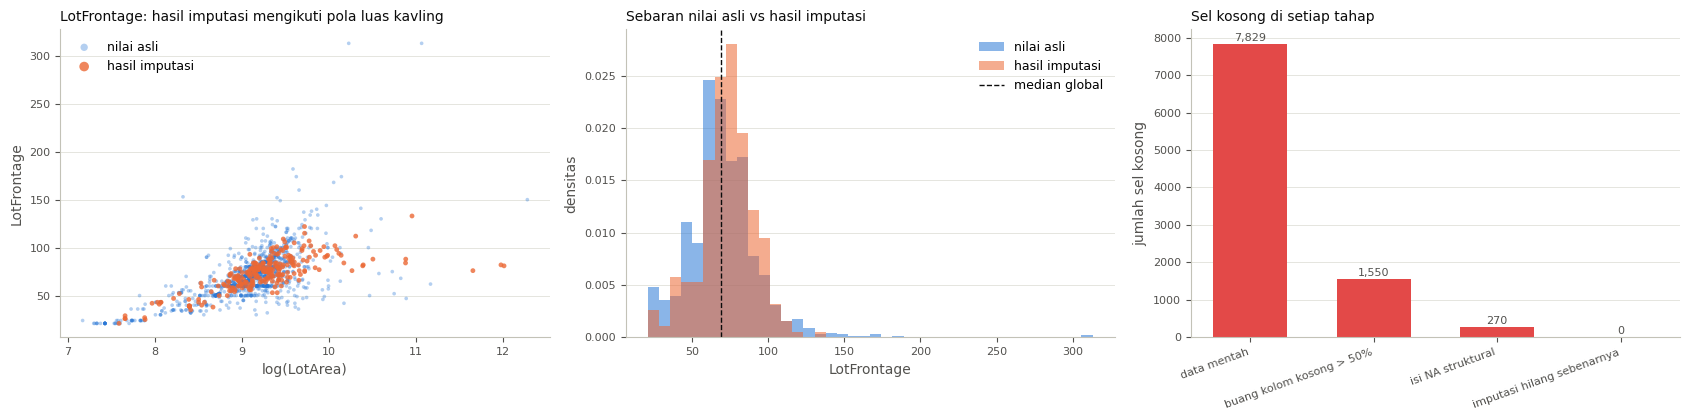

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.3))

axes[0].scatter(np.log(df.loc[~kosong_lf, 'LotArea']), df.loc[~kosong_lf, 'LotFrontage'], s=7, alpha=0.35,
                color=BIRU, edgecolors='none', label='nilai asli')
axes[0].scatter(np.log(df.loc[kosong_lf, 'LotArea']), df.loc[kosong_lf, 'LotFrontage'], s=12, alpha=0.8,
                color=ORANYE, edgecolors='none', label='hasil imputasi')
axes[0].set_xlabel('log(LotArea)')
axes[0].set_ylabel('LotFrontage')
axes[0].legend(markerscale=2)
axes[0].set_title('LotFrontage: hasil imputasi mengikuti pola luas kavling', loc='left')

tepi = np.histogram_bin_edges(df['LotFrontage'], bins=40)
axes[1].hist(df.loc[~kosong_lf, 'LotFrontage'], bins=tepi, density=True, color=BIRU, alpha=0.55, label='nilai asli')
axes[1].hist(df.loc[kosong_lf, 'LotFrontage'], bins=tepi, density=True, color=ORANYE, alpha=0.55, label='hasil imputasi')
axes[1].axvline(df_raw['LotFrontage'].median(), color=TINTA, lw=1, ls='--', label='median global')
axes[1].set_xlabel('LotFrontage')
axes[1].set_ylabel('densitas')
axes[1].legend()
axes[1].set_title('Sebaran nilai asli vs hasil imputasi', loc='left')

tahap_nama = [t[0] for t in jejak]
tahap_kosong = [t[3] for t in jejak]
axes[2].bar(range(len(jejak)), tahap_kosong, color=[MERAH if v else AQUA for v in tahap_kosong], width=0.6)
for xx, v in enumerate(tahap_kosong):
    axes[2].text(xx, v + 80, f'{v:,}', ha='center', fontsize=8, color=ABU)
axes[2].set_xticks(range(len(jejak)))
axes[2].set_xticklabels(tahap_nama, rotation=20, ha='right', fontsize=8)
axes[2].set_ylabel('jumlah sel kosong')
axes[2].set_title('Sel kosong di setiap tahap', loc='left')
plt.tight_layout()
plt.show()

### notes
1. NA struktural diisi "Tidak Ada" agar tetap menjadi kategori yang bisa dibaca model: 690 sel `FireplaceQu`, 4 x 81 sel kolom garasi, 5 x 37 sel kolom basement.
2. `GarageYrBlt` untuk 81 rumah tanpa garasi diisi `YearBuilt`. Mengisi 0 atau tahun fiktif akan menciptakan outlier buatan.
3. `LotFrontage`: KNN (k=5) dari log `LotArea` dan luas bangunan memberi galat rata-rata 11.28 ft, lebih baik dari median per Neighborhood (12.78 ft) dan median global (16.42 ft). Hasil ini dari 20 kali pengulangan dengan 20% nilai asli disembunyikan.
4. Nilai hasil imputasi mengikuti pola log(`LotArea`), tetapi sebarannya lebih sempit (80% berada di 49-94 ft) karena KNN merata-ratakan tetangga. Ini wajar untuk imputasi.
5. `MasVnrArea` (8 baris) diisi 0: `MasVnrType` di baris yang sama juga kosong, dan 0 adalah nilai tersering (59%).
6. `Electrical` (Id 1380, dibangun 2006) diisi SBrkr karena semua 385 rumah yang dibangun sejak 2000 memakai SBrkr.
7. `BsmtFinType2` (Id 333) diisi Rec, bukan modus umum Unf. `BsmtFinSF2`-nya 479 sqft, artinya area tersebut sudah jadi, jadi modus diambil dari rumah dengan `BsmtFinSF2` > 0. `BsmtExposure` (Id 949) diisi No, modus rumah yang punya basement.
8. Sel kosong turun dari 7829 menjadi 1550 (buang kolom), 270 (NA struktural), lalu 0.

### 2.5 Data tidak konsisten

Label Exterior2nd diperbaiki : 105 baris {'Brk Cmn': 'BrkComm', 'CmentBd': 'CemntBd', 'Wd Shng': 'WdShing'}
Exterior1st == Exterior2nd   : 85.3% -> 90.6%
MasVnrArea 1 -> 0            : Id [774, 1231]
Dibiarkan: GarageYrBlt < YearBuilt (9 rumah, selisih 1-10 tahun, garasi lama dipertahankan saat rumah dibangun ulang)
Ditangani di Langkah 3: Id 524 (YearRemodAdd 2008 > YrSold 2007)


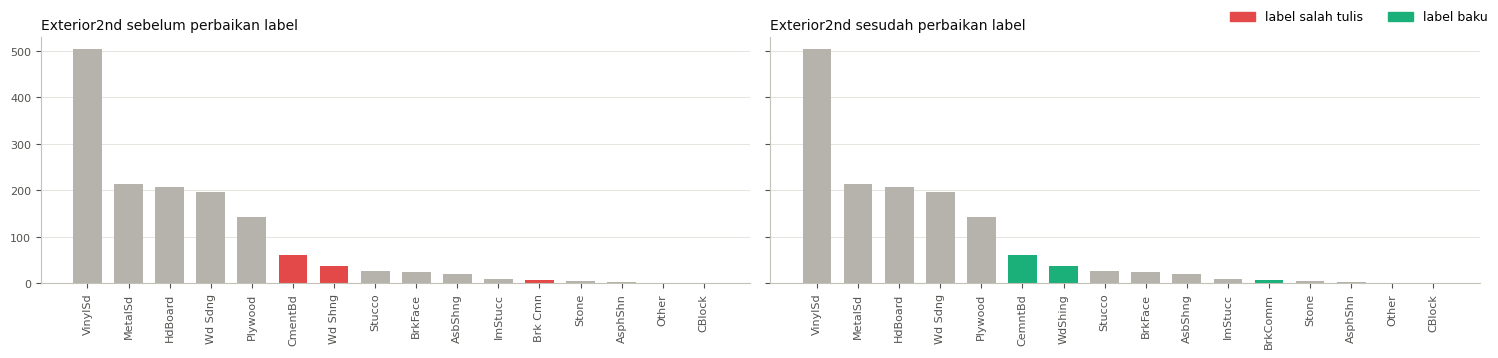

In [33]:
# label Exterior2nd disamakan dengan penulisan di Exterior1st
PERBAIKAN_LABEL = {'Brk Cmn': 'BrkComm', 'CmentBd': 'CemntBd', 'Wd Shng': 'WdShing'}
sama_sebelum = (df['Exterior1st'] == df['Exterior2nd']).mean()
n_label = df['Exterior2nd'].isin(list(PERBAIKAN_LABEL)).sum()
frek_sebelum = df['Exterior2nd'].value_counts()
df['Exterior2nd'] = df['Exterior2nd'].replace(PERBAIKAN_LABEL)
sama_sesudah = (df['Exterior1st'] == df['Exterior2nd']).mean()

# MasVnrArea 1 sqft pada rumah bertipe "None" tidak realistis -> 0
salah_vnr = (df_literal['MasVnrType'] == 'None') & (df['MasVnrArea'] == 1)
id_vnr = df.loc[salah_vnr, 'Id'].tolist()
df.loc[salah_vnr, 'MasVnrArea'] = 0

print(f'Label Exterior2nd diperbaiki : {n_label} baris {PERBAIKAN_LABEL}')
print(f'Exterior1st == Exterior2nd   : {sama_sebelum:.1%} -> {sama_sesudah:.1%}')
print(f'MasVnrArea 1 -> 0            : Id {id_vnr}')
print('Dibiarkan: GarageYrBlt < YearBuilt (9 rumah, selisih 1-10 tahun, garasi lama dipertahankan saat rumah dibangun ulang)')
print('Ditangani di Langkah 3: Id 524 (YearRemodAdd 2008 > YrSold 2007)')

fig, axes = plt.subplots(1, 2, figsize=(15, 3.6), sharey=True)
frek_sesudah = df['Exterior2nd'].value_counts()
for ax, frek, judul in [(axes[0], frek_sebelum, 'sebelum'), (axes[1], frek_sesudah, 'sesudah')]:
    warna = [MERAH if k in PERBAIKAN_LABEL else (AQUA if k in PERBAIKAN_LABEL.values() else ABU_MUDA)
             for k in frek.index]
    ax.bar(frek.index, frek.values, color=warna, width=0.7)
    ax.tick_params(axis='x', rotation=90)
    ax.set_title(f'Exterior2nd {judul} perbaikan label', loc='left')
fig.legend(handles=[Patch(color=MERAH, label='label salah tulis'), Patch(color=AQUA, label='label baku')],
           loc='upper right', ncol=2)
plt.tight_layout()
plt.show()

### notes
1. 105 baris label `Exterior2nd` diseragamkan. Kecocokan `Exterior1st` = `Exterior2nd` naik dari 85.3% ke 90.6%, sehingga material yang sama tidak lagi terpecah menjadi dua kategori.
2. `MasVnrArea` Id 774 dan 1231 diubah dari 1 menjadi 0 (tipe pelapis "None").
3. Id 524 (renovasi setelah terjual) ditangani di Langkah 3 bersama anomali lain. `GarageYrBlt` < `YearBuilt` dibiarkan karena masih masuk akal.

## Langkah 3 - Deteksi dan Penanganan Outlier

### 3.1 Anomali: rumah besar dengan harga tidak wajar

=== 6 rumah dengan harga paling jauh di bawah perkiraan ===


,Id,GrLivArea,TotalBsmtSF,OverallQual,YearRemodAdd,YrSold,SaleCondition,SalePrice,harga_per_sqft,z_residual
1298,1299,5642,6110,10,2008,2008,Partial,160000,28.36,-6.58
523,524,4676,3138,10,2008,2007,Partial,184750,39.51,-5.44
30,31,1317,649,4,1950,2008,Normal,40000,30.37,-5.18
495,496,720,720,4,1950,2009,Abnorml,34900,48.47,-4.53
1349,1350,2358,684,8,1987,2008,Normal,122000,51.74,-4.30
632,633,1411,1386,7,1977,2009,Family,82500,58.47,-4.27


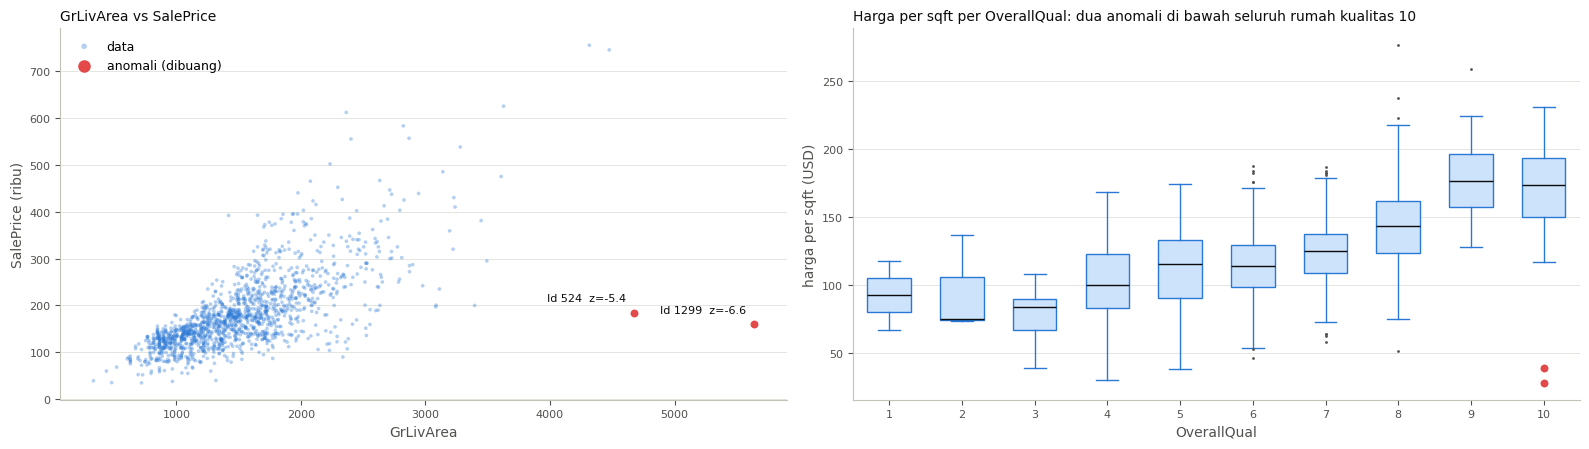

Dibuang: Id [524, 1299]   ukuran data: (1458, 76)
Pearson GrLivArea - SalePrice: 0.709 -> 0.735


In [34]:
# residual regresi log(SalePrice) ~ log(GrLivArea) + OverallQual: harga yang jauh di bawah perkiraan
X_reg = np.column_stack([np.ones(len(df)), np.log(df['GrLivArea']), df['OverallQual']])
y_reg = np.log(df['SalePrice'])
beta, *_ = np.linalg.lstsq(X_reg, y_reg, rcond=None)
resid = y_reg - X_reg @ beta

cek_anomali = df[['Id', 'GrLivArea', 'TotalBsmtSF', 'OverallQual', 'YearRemodAdd', 'YrSold',
                  'SaleCondition', 'SalePrice']].copy()
cek_anomali['harga_per_sqft'] = df['SalePrice'] / df['GrLivArea']
cek_anomali['z_residual'] = (resid - resid.mean()) / resid.std()
print('=== 6 rumah dengan harga paling jauh di bawah perkiraan ===')
display(cek_anomali.nsmallest(6, 'z_residual').round(2))

anomali = cek_anomali[(cek_anomali['GrLivArea'] > 4000) & (cek_anomali['z_residual'] < -3)]

fig, axes = plt.subplots(1, 2, figsize=(16, 4.6))
ax = axes[0]
normal = ~df['Id'].isin(anomali['Id'])
ax.scatter(df.loc[normal, 'GrLivArea'], df.loc[normal, 'SalePrice'] / 1000, s=7, alpha=0.35,
           color=BIRU, edgecolors='none', label='data')
ax.scatter(anomali['GrLivArea'], anomali['SalePrice'] / 1000, s=45, color=MERAH, edgecolors='white',
           zorder=3, label='anomali (dibuang)')
for _, r in anomali.iterrows():
    ax.annotate(f"Id {r['Id']}  z={r['z_residual']:.1f}", (r['GrLivArea'], r['SalePrice'] / 1000),
                textcoords='offset points', xytext=(-6, 8), ha='right', fontsize=8, color=TINTA)
ax.set_xlabel('GrLivArea')
ax.set_ylabel('SalePrice (ribu)')
ax.legend(loc='upper left', markerscale=1.5)
ax.set_title('GrLivArea vs SalePrice', loc='left')

ax = axes[1]
q_level = sorted(df['OverallQual'].unique())
ax.boxplot([cek_anomali.loc[df['OverallQual'] == q, 'harga_per_sqft'] for q in q_level], widths=0.6,
           patch_artist=True, boxprops=dict(facecolor='#cde2fb', edgecolor=BIRU),
           medianprops=dict(color=TINTA), whiskerprops=dict(color=BIRU), capprops=dict(color=BIRU),
           flierprops=dict(marker='o', markersize=2, markerfacecolor=ABU, markeredgecolor='none'))
ax.set_xticks(range(1, len(q_level) + 1))
ax.set_xticklabels(q_level)
ax.scatter(anomali['OverallQual'] - q_level[0] + 1, anomali['harga_per_sqft'], s=45, color=MERAH,
           edgecolors='white', zorder=3)
ax.set_xlabel('OverallQual')
ax.set_ylabel('harga per sqft (USD)')
ax.set_title('Harga per sqft per OverallQual: dua anomali di bawah seluruh rumah kualitas 10', loc='left')
plt.tight_layout()
plt.show()

r_sebelum = df['GrLivArea'].corr(df['SalePrice'])
df = df[~df['Id'].isin(anomali['Id'])].reset_index(drop=True)
r_sesudah = df['GrLivArea'].corr(df['SalePrice'])
jejak.append(('hapus 2 anomali', *df.shape, int(df.isna().sum().sum())))
print(f"Dibuang: Id {anomali['Id'].tolist()}   ukuran data: {df.shape}")
print(f'Pearson GrLivArea - SalePrice: {r_sebelum:.3f} -> {r_sesudah:.3f}')

### 3.2 Nilai ekstrem valid: capping atau dibiarkan

,max,P99,max/P99,n_di_atas_P99,skew,skew_cap,pearson,pearson_cap,spearman,perubahan_pearson
fitur,,,,,,,,,,
LotFrontage,313.0,135.29,2.314,15,1.361,0.271,0.370,0.380,0.415,0.010
LotArea,215245.0,35402.61,6.080,15,12.574,2.197,0.268,0.401,0.457,0.132
BsmtUnfSF,2336.0,1797.15,1.300,15,0.921,0.843,0.214,0.207,0.185,-0.007
TotalBsmtSF,3206.0,2136.00,1.501,14,0.512,0.222,0.651,0.642,0.604,-0.010
1stFlrSF,3228.0,2200.73,1.467,15,0.888,0.678,0.632,0.626,0.576,-0.006
GrLivArea,4476.0,3083.72,1.451,15,1.011,0.740,0.735,0.719,0.732,-0.016
GarageArea,1390.0,988.16,1.407,15,0.132,-0.033,0.629,0.633,0.650,0.004


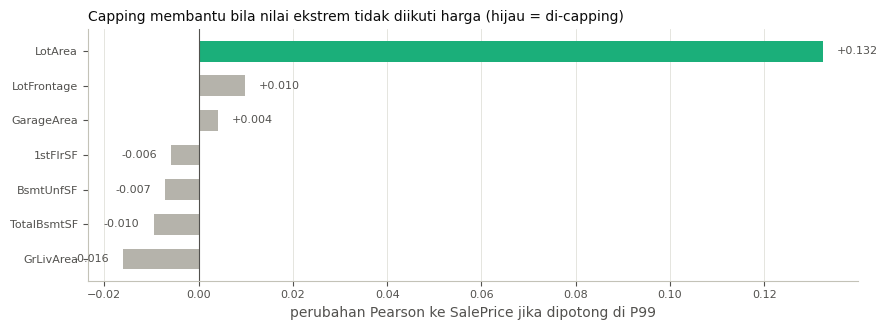

In [35]:
# fitur kontinu yang tidak didominasi nol: apakah memotong nilai di atas P99 memperbaiki hubungan dengan harga?
kandidat = [c for c in KONTINU if c in df.columns and (df[c] == 0).mean() < 0.25]
evaluasi = []
for c in kandidat:
    s = df[c]
    p99 = s.quantile(0.99)
    dipotong = s.clip(upper=p99)
    evaluasi.append({'fitur': c, 'max': s.max(), 'P99': p99, 'max/P99': s.max() / p99,
                     'n_di_atas_P99': int((s > p99).sum()), 'skew': s.skew(), 'skew_cap': dipotong.skew(),
                     'pearson': s.corr(df['SalePrice']), 'pearson_cap': dipotong.corr(df['SalePrice']),
                     'spearman': s.corr(df['SalePrice'], method='spearman')})
evaluasi = pd.DataFrame(evaluasi).set_index('fitur')
evaluasi['perubahan_pearson'] = evaluasi['pearson_cap'] - evaluasi['pearson']
display(evaluasi.round(3))

fig, ax = plt.subplots(figsize=(9, 3.4))
plot_df = evaluasi.sort_values('perubahan_pearson')
ax.barh(plot_df.index, plot_df['perubahan_pearson'], height=0.6,
        color=[AQUA if v > 0.01 else ABU_MUDA for v in plot_df['perubahan_pearson']])
ax.axvline(0, color=ABU, lw=0.8)
for yy, v in enumerate(plot_df['perubahan_pearson']):
    ax.text(v + (0.003 if v >= 0 else -0.003), yy, f'{v:+.3f}', va='center',
            ha='left' if v >= 0 else 'right', fontsize=8, color=ABU)
ax.grid(axis='y', visible=False)
ax.grid(axis='x', visible=True)
ax.set_xlabel('perubahan Pearson ke SalePrice jika dipotong di P99')
ax.set_title('Capping membantu bila nilai ekstrem tidak diikuti harga (hijau = di-capping)', loc='left')
plt.tight_layout()
plt.show()

LotArea     : 15 baris dipotong ke 35,403   max 215,245 -> 35,403   skew 12.57 -> 2.20


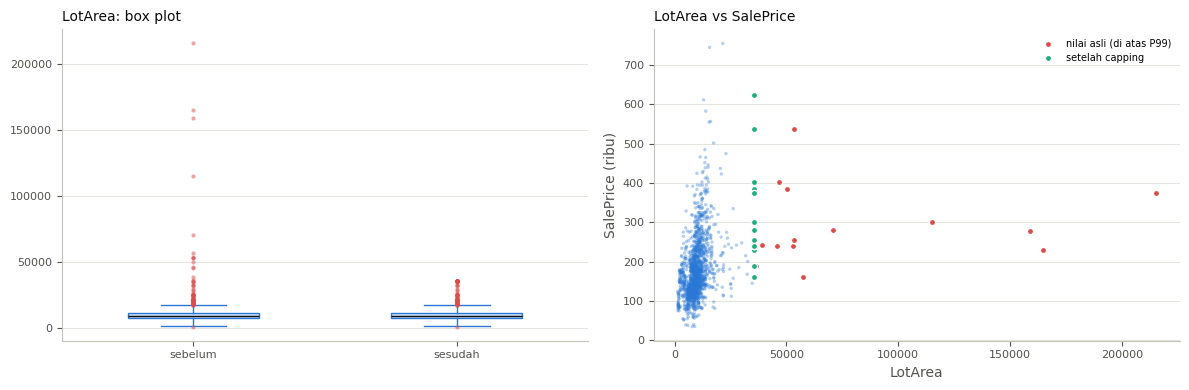

In [36]:
DI_CAP = evaluasi.index[evaluasi['perubahan_pearson'] > 0.01].tolist()
sebelum_cap = df[DI_CAP].copy()
batas_cap = {}
for c in DI_CAP:
    batas_cap[c] = df[c].quantile(0.99)
    df[c] = df[c].clip(upper=batas_cap[c])
jejak.append(('capping P99 (train_clean.csv)', *df.shape, int(df.isna().sum().sum())))

for c in DI_CAP:
    n = (sebelum_cap[c] > batas_cap[c]).sum()
    print(f'{c:12s}: {n} baris dipotong ke {batas_cap[c]:,.0f}   max {sebelum_cap[c].max():,.0f} -> {df[c].max():,.0f}'
          f'   skew {sebelum_cap[c].skew():.2f} -> {df[c].skew():.2f}')

fig, axes = plt.subplots(1, len(DI_CAP) * 2, figsize=(8 * len(DI_CAP) + 4, 4))
for i, c in enumerate(DI_CAP):
    ax = axes[2 * i]
    ax.boxplot([sebelum_cap[c], df[c]], widths=0.5, patch_artist=True,
               boxprops=dict(facecolor='#cde2fb', edgecolor=BIRU), medianprops=dict(color=TINTA),
               whiskerprops=dict(color=BIRU), capprops=dict(color=BIRU),
               flierprops=dict(marker='o', markersize=3, markerfacecolor=MERAH, markeredgecolor='none', alpha=0.5))
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['sebelum', 'sesudah'])
    ax.set_title(f'{c}: box plot', loc='left')

    ax = axes[2 * i + 1]
    dipotong = sebelum_cap[c] > batas_cap[c]
    ax.scatter(sebelum_cap.loc[~dipotong, c], df.loc[~dipotong, 'SalePrice'] / 1000, s=6, alpha=0.35,
               color=BIRU, edgecolors='none')
    ax.scatter(sebelum_cap.loc[dipotong, c], df.loc[dipotong, 'SalePrice'] / 1000, s=20, color=MERAH,
               edgecolors='white', label='nilai asli (di atas P99)')
    ax.scatter(df.loc[dipotong, c], df.loc[dipotong, 'SalePrice'] / 1000, s=20, color=AQUA,
               edgecolors='white', label='setelah capping')
    ax.set_xlabel(c)
    ax.set_ylabel('SalePrice (ribu)')
    ax.legend(fontsize=7)
    ax.set_title(f'{c} vs SalePrice', loc='left')
plt.tight_layout()
plt.show()

,mentah,bersih,sifat
fitur,,,
EnclosedPorch,208,208,artefak (IQR = 0)
BsmtFinSF2,167,167,artefak (IQR = 0)
ScreenPorch,116,116,artefak (IQR = 0)
MasVnrArea,96,97,nilai ekstrem kontinu
LotFrontage,88,95,nilai ekstrem kontinu
OpenPorchSF,77,75,nilai ekstrem kontinu
LotArea,69,66,nilai ekstrem kontinu
SalePrice,61,61,nilai ekstrem kontinu
TotalBsmtSF,61,59,nilai ekstrem kontinu


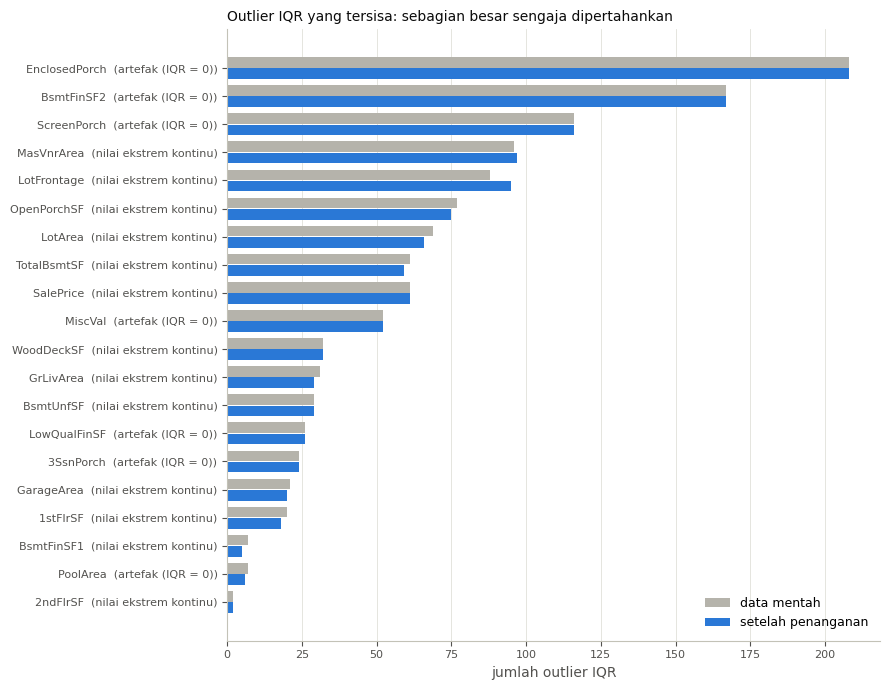

In [37]:
# outlier IQR sebelum (data mentah) vs sesudah penanganan, fitur kontinu dan target
fitur_banding = [c for c in KONTINU if c in df.columns] + ['SalePrice']
iqr_bersih = ringkas_iqr(df, fitur_banding)
banding_out = pd.DataFrame({'mentah': iqr_mentah.loc[fitur_banding, 'n_outlier'],
                            'bersih': iqr_bersih['n_outlier'],
                            'sifat': iqr_bersih['sifat']})
display(banding_out.sort_values('mentah', ascending=False))

plot_df = banding_out.sort_values('mentah')
y = np.arange(len(plot_df))
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(y + 0.2, plot_df['mentah'], height=0.38, color=ABU_MUDA, label='data mentah')
ax.barh(y - 0.2, plot_df['bersih'], height=0.38, color=BIRU, label='setelah penanganan')
ax.set_yticks(y)
ax.set_yticklabels([f'{i}  ({s})' for i, s in zip(plot_df.index, plot_df['sifat'])], fontsize=8)
ax.grid(axis='y', visible=False)
ax.grid(axis='x', visible=True)
ax.set_xlabel('jumlah outlier IQR')
ax.legend(loc='lower right')
ax.set_title('Outlier IQR yang tersisa: sebagian besar sengaja dipertahankan', loc='left')
plt.tight_layout()
plt.show()

### notes
1. Dihapus 2 baris, Id 524 dan 1299. Harganya 5.4 dan 6.6 simpangan baku di bawah perkiraan dari luas dan kualitas; harga per sqft 40 dan 28 USD, sementara median rumah `OverallQual` 10 adalah 174 USD; keduanya dijual Partial, dan Id 524 tercatat direnovasi setelah terjual. Transaksi rumah yang belum selesai ini bukan populasi yang sama dengan penjualan normal.
2. Setelah dihapus, Pearson `GrLivArea` - `SalePrice` naik dari 0.709 ke 0.735.
3. Tidak semua rumah murah dibuang. Id 31 dan 496 juga jauh di bawah perkiraan (z -5.2 dan -4.5), tetapi keduanya rumah berkualitas 4 (Id 496 hanya 720 sqft), jadi harga rendahnya masih masuk akal untuk kualitasnya.
4. Capping P99 hanya pada `LotArea`: 15 kavling dipotong ke 35403 sqft, skew turun dari 12.57 ke 2.20, dan Pearson ke harga naik dari 0.268 ke 0.401 (mendekati Spearman 0.457). Kavling raksasa itu valid, tetapi harganya tidak naik sebanding luasnya, jadi nilainya disesuaikan, bukan barisnya dibuang.
5. Fitur lain tidak di-capping karena Pearson tidak membaik atau malah turun (`GrLivArea` -0.016, `TotalBsmtSF` -0.010): nilai ekstremnya sejalan dengan harga dan informatif. `LotFrontage` nyaris lolos (+0.0099).
6. Outlier yang tersisa sengaja dipertahankan: artefak IQR pada fitur yang didominasi nol, 61 rumah mahal pada `SalePrice`, dan nilai langka pada fitur diskrit. `LotArea` masih punya 66 outlier IQR karena batas capping (P99 = 35403) jauh di atas batas IQR (17673). Tujuannya hanya menjinakkan ekor ekstrem, bukan menghapus variasi.
7. Outlier `LotFrontage` naik dari 88 ke 95: 86 berasal dari nilai asli dan 9 dari nilai imputasi untuk kavling sangat besar atau sangat kecil.

## Ekspor Data Bersih

In [38]:
df.to_csv('train_clean.csv', index=False)
print(f'Tersimpan: train_clean.csv  ({df.shape[0]} baris x {df.shape[1]} kolom, sel kosong: {df.isna().sum().sum()})')

Tersimpan: train_clean.csv  (1458 baris x 76 kolom, sel kosong: 0)


## Perbandingan Data Mentah vs Data Bersih

train_clean.csv dibaca ulang: (1458, 76), sel kosong: 0


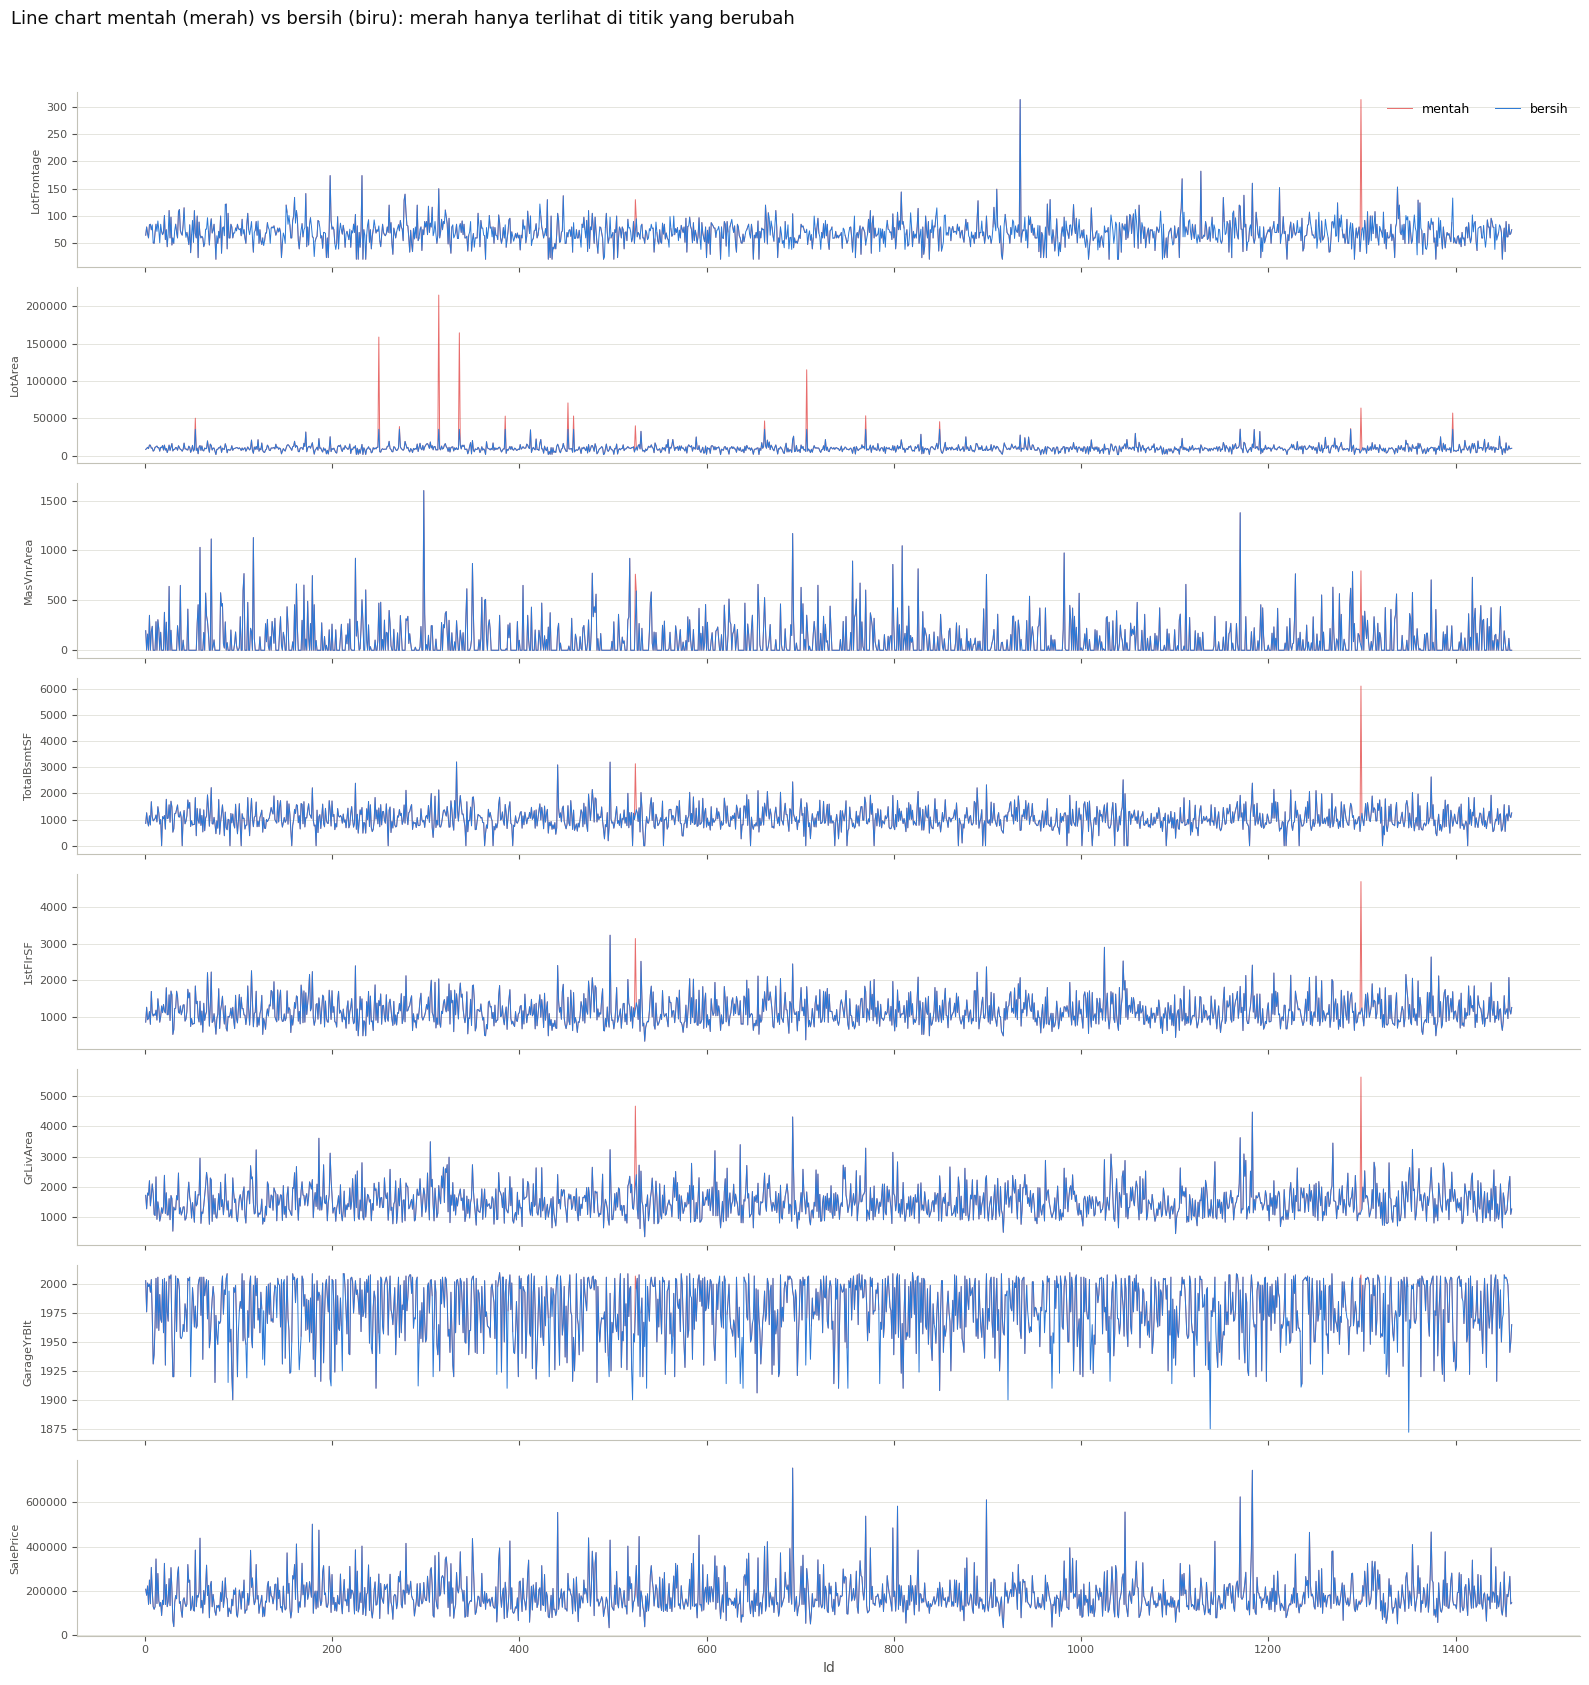

In [39]:
bersih = pd.read_csv('train_clean.csv')
mentah = df_raw
print(f'train_clean.csv dibaca ulang: {bersih.shape}, sel kosong: {bersih.isna().sum().sum()}')

fitur_line = ['LotFrontage', 'LotArea', 'MasVnrArea', 'TotalBsmtSF', '1stFlrSF', 'GrLivArea', 'GarageYrBlt', 'SalePrice']
fig, axes = plt.subplots(len(fitur_line), 1, figsize=(16, 2.1 * len(fitur_line)), sharex=True)
for ax, col in zip(axes, fitur_line):
    ax.plot(mentah['Id'], mentah[col], color=MERAH, lw=0.7, alpha=0.8, label='mentah')
    ax.plot(bersih['Id'], bersih[col], color=BIRU, lw=0.7, label='bersih')
    ax.set_ylabel(col, fontsize=8)
axes[0].legend(ncol=2, loc='upper right')
axes[-1].set_xlabel('Id')
judul_figur(fig, 'Line chart mentah (merah) vs bersih (biru): merah hanya terlihat di titik yang berubah')
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

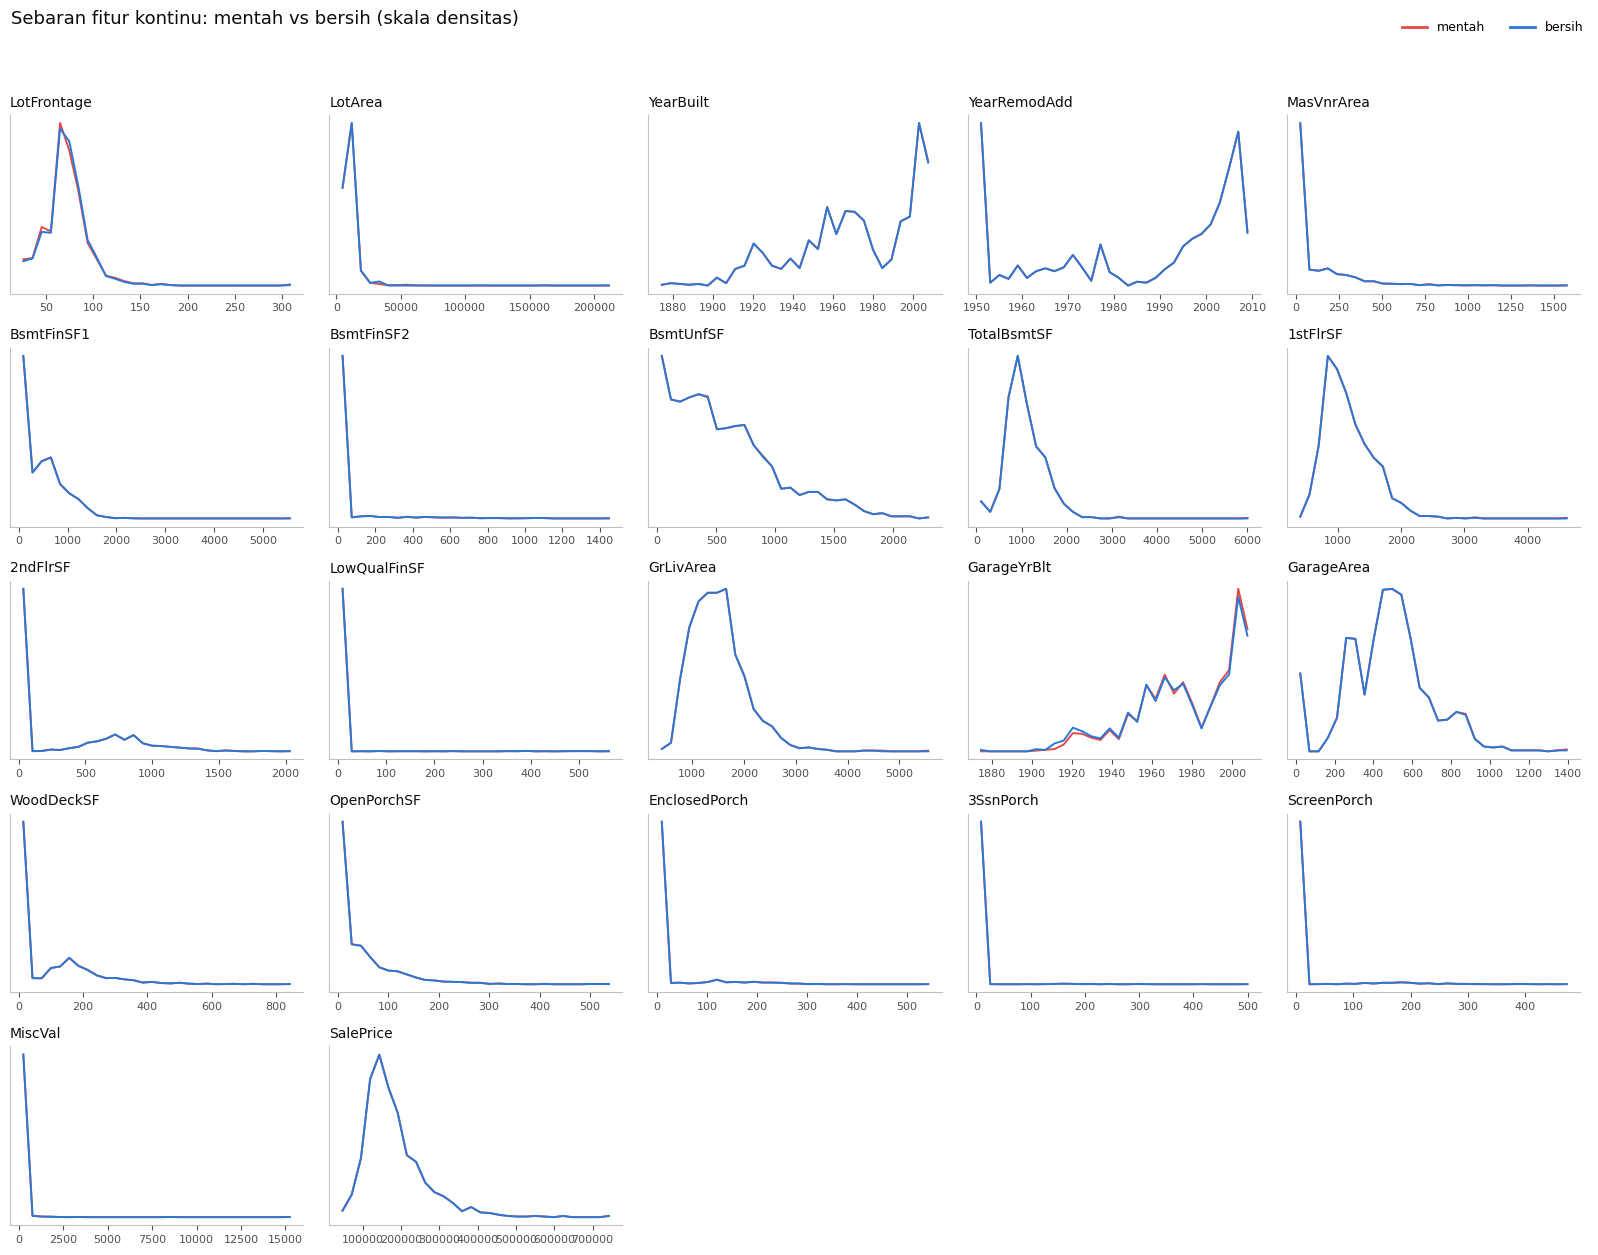

In [40]:
fitur_densitas = [c for c in fitur_num if c in bersih.columns and bersih[c].nunique() > 15]
fig, axes = buat_grid(len(fitur_densitas), ncols=5, tinggi=2.5)
for ax, col in zip(axes, fitur_densitas):
    tepi = np.histogram_bin_edges(pd.concat([mentah[col], bersih[col]]).dropna(), bins=30)
    pusat = (tepi[:-1] + tepi[1:]) / 2
    for sumber, warna, nama in ((mentah, MERAH, 'mentah'), (bersih, BIRU, 'bersih')):
        dens, _ = np.histogram(sumber[col].dropna(), bins=tepi, density=True)
        ax.plot(pusat, dens, color=warna, lw=1.4, label=nama)
    ax.set_title(col, loc='left')
    ax.set_yticks([])
fig.legend(handles=[Line2D([], [], color=MERAH, lw=2, label='mentah'), Line2D([], [], color=BIRU, lw=2, label='bersih')],
           loc='upper right', ncol=2, bbox_to_anchor=(1, 1.0))
judul_figur(fig, 'Sebaran fitur kontinu: mentah vs bersih (skala densitas)')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

Fitur dengan pergeseran mean atau std > 0.5%: 12 dari 37


,mean_mentah,mean_bersih,std_mentah,std_bersih,skew_mentah,skew_bersih,geser_mean_%,geser_std_%
LotArea,10516.83,10004.08,9981.26,4854.17,12.21,2.20,-4.88,-51.37
LotFrontage,70.05,70.40,24.28,22.39,2.16,1.36,0.50,-7.81
TotalBsmtSF,1057.43,1052.54,438.71,414.98,1.52,0.51,-0.46,-5.41
BsmtFinSF1,443.64,438.83,456.10,432.97,1.69,0.76,-1.08,-5.07
PoolArea,2.76,2.43,40.18,38.21,14.83,15.95,-11.80,-4.90
1stFlrSF,1162.63,1158.85,386.59,372.04,1.38,0.89,-0.32,-3.76
GrLivArea,1515.46,1510.47,525.48,507.88,1.37,1.01,-0.33,-3.35
OpenPorchSF,46.66,46.25,66.26,65.31,2.36,2.34,-0.89,-1.42
MasVnrArea,103.69,102.19,181.07,179.11,2.67,2.70,-1.44,-1.08
GarageArea,472.98,472.05,213.80,212.24,0.18,0.13,-0.20,-0.73


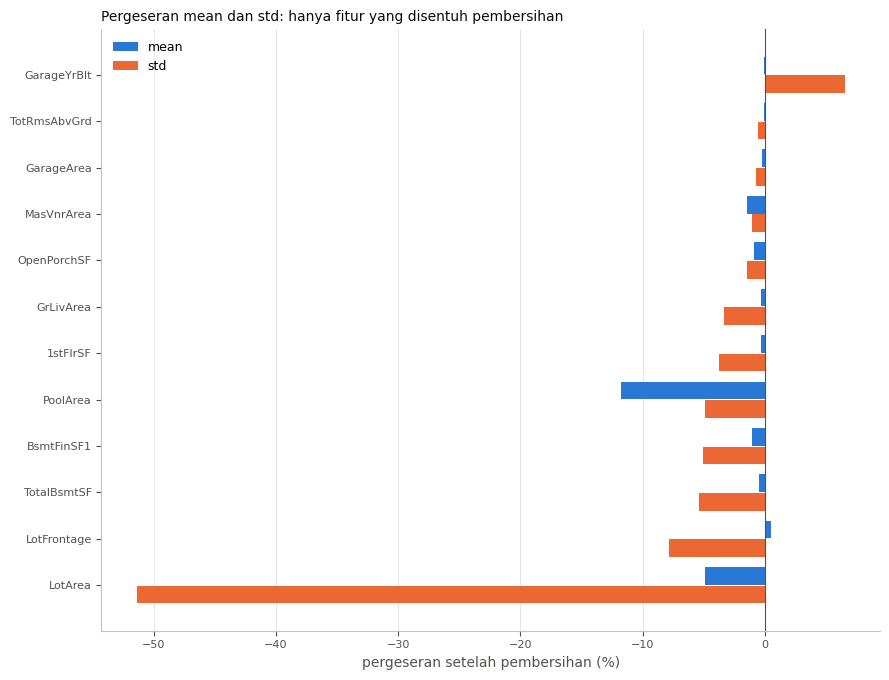

In [41]:
kol_banding = [c for c in fitur_num if c in bersih.columns]
banding_stat = pd.DataFrame({
    'mean_mentah': mentah[kol_banding].mean(), 'mean_bersih': bersih[kol_banding].mean(),
    'std_mentah': mentah[kol_banding].std(), 'std_bersih': bersih[kol_banding].std(),
    'skew_mentah': mentah[kol_banding].skew(), 'skew_bersih': bersih[kol_banding].skew(),
})
banding_stat['geser_mean_%'] = (banding_stat['mean_bersih'] / banding_stat['mean_mentah'] - 1) * 100
banding_stat['geser_std_%'] = (banding_stat['std_bersih'] / banding_stat['std_mentah'] - 1) * 100
berubah = banding_stat[(banding_stat['geser_mean_%'].abs() > 0.5) | (banding_stat['geser_std_%'].abs() > 0.5)]
print(f'Fitur dengan pergeseran mean atau std > 0.5%: {len(berubah)} dari {len(banding_stat)}')
display(berubah.round(2).sort_values('geser_std_%'))

plot_df = berubah.sort_values('geser_std_%')
y = np.arange(len(plot_df))
fig, ax = plt.subplots(figsize=(9, 0.45 * len(plot_df) + 1.5))
ax.barh(y + 0.2, plot_df['geser_mean_%'], height=0.38, color=BIRU, label='mean')
ax.barh(y - 0.2, plot_df['geser_std_%'], height=0.38, color=ORANYE, label='std')
ax.axvline(0, color=ABU, lw=0.8)
ax.set_yticks(y)
ax.set_yticklabels(plot_df.index)
ax.grid(axis='y', visible=False)
ax.grid(axis='x', visible=True)
ax.set_xlabel('pergeseran setelah pembersihan (%)')
ax.legend(loc='upper left')
ax.set_title('Pergeseran mean dan std: hanya fitur yang disentuh pembersihan', loc='left')
plt.tight_layout()
plt.show()

### notes
1. Pembersihan hanya menghapus 2 baris (0.14%) dan 5 kolom. Sebanyak 25 dari 37 fitur numerik bergeser kurang dari 0.5% pada mean dan std, dan kurva densitas mentah dan bersih berimpit di hampir semua fitur.
2. Perubahan besar hanya terjadi di fitur yang memang ditangani: `LotArea` std turun 51% dan skew dari 12.2 ke 2.2 (capping).
3. `PoolArea` mean turun 11.8% karena Id 1299 memiliki kolam 480 sqft (1 dari 7 kolam di data). `TotalBsmtSF`, `BsmtFinSF1`, dan `1stFlrSF` std turun 3.8-5.4% karena Id 1299 memegang nilai maksimumnya.
4. `GarageYrBlt` std naik 6.5%. Rumah tanpa garasi rata-rata dibangun tahun 1942, jauh lebih tua dari rata-rata tahun garasi (1978), sehingga ekor kiri bertambah.
5. `LotFrontage` std turun 7.8% karena nilai imputasi berada di sekitar pusat sebaran.

## Langkah 4 - Transformasi Data

### 4.1 Target

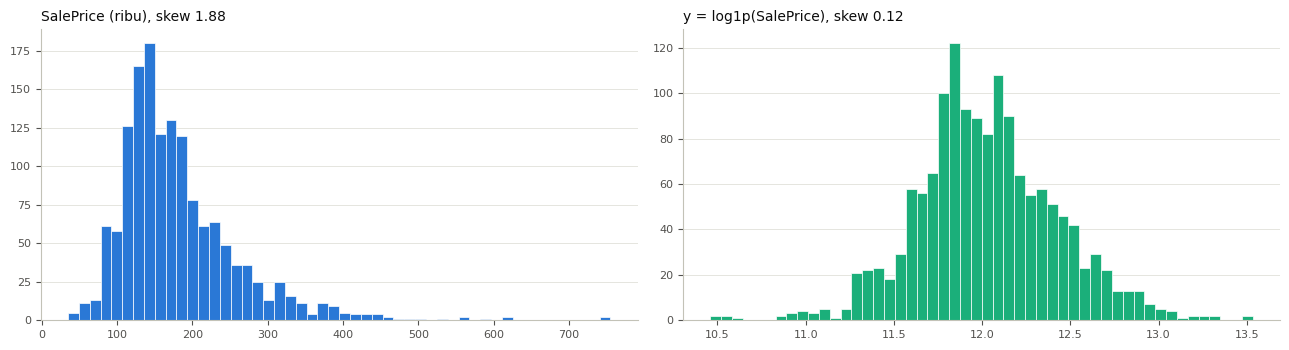

X: (1458, 74)   y: (1458,)


In [42]:
# target dipisah dan tidak ikut distandarisasi / PCA; log1p membuat sebarannya mendekati normal
y = np.log1p(df['SalePrice'])
X = df.drop(columns=['Id', 'SalePrice'])

fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
axes[0].hist(df['SalePrice'] / 1000, bins=50, color=BIRU, edgecolor='white', linewidth=0.5)
axes[0].set_title(f"SalePrice (ribu), skew {df['SalePrice'].skew():.2f}", loc='left')
axes[1].hist(y, bins=50, color=AQUA, edgecolor='white', linewidth=0.5)
axes[1].set_title(f'y = log1p(SalePrice), skew {y.skew():.2f}', loc='left')
plt.tight_layout()
plt.show()
print(f'X: {X.shape}   y: {y.shape}')

### 4.2 Encoding atribut kategoris

Ordinal (dipetakan ke angka) : 14 kolom
Nominal (one-hot)            : 25 kolom -> 183 kolom dummy
Ukuran X: (1458, 74) -> (1458, 232)
Jika semua kategorik di-one-hot: 294 kolom

Contoh hasil encoding (5 baris pertama):


sebelum                                                 sesudah                                                                                                                     
  ExterQual BsmtExposure GarageFinish CentralAir MSZoning ExterQual BsmtExposure GarageFinish MSZoning_C (all) MSZoning_FV MSZoning_RH MSZoning_RL MSZoning_RM CentralAir_N CentralAir_Y
0        Gd           No          RFn          Y       RL         4            1            2                0           0           0           1           0            0            1
1        TA           Gd          RFn          Y       RL         3            4            2                0           0           0           1           0            0            1
2        Gd           Mn          RFn          Y       RL         4            2            2                0           0           0           1           0            0            1
3        TA           No          Unf          Y       RL         3            1            1                0           0           0           1           0            0            1
4        Gd           Av          RFn          Y       RL         4            3            2                0           0           0           1           0            0            1

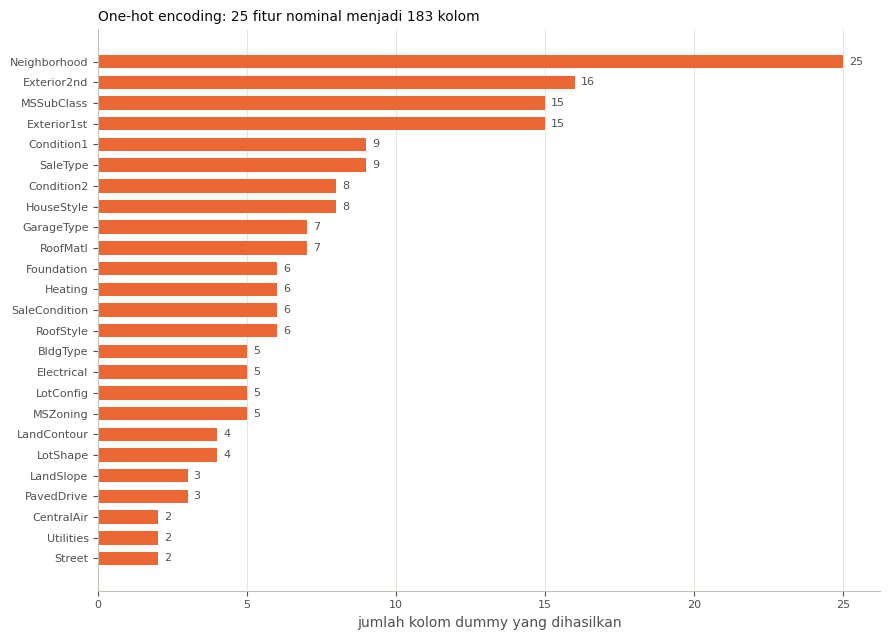

In [43]:
X = X.copy()
X['MSSubClass'] = X['MSSubClass'].astype(str)          # kode tipe bangunan, bukan besaran

# ordinal: skala kualitas diubah jadi angka berurutan, 'Tidak Ada' = 0
ORDINAL_DIPAKAI = [c for c in SKALA if c in X.columns]
contoh_idx = X.index[:5]
contoh_sebelum = X.loc[contoh_idx, ['ExterQual', 'BsmtExposure', 'GarageFinish', 'CentralAir', 'MSZoning']].copy()
for col in ORDINAL_DIPAKAI:
    peta = {TIDAK_ADA: 0} | {kat: i + 1 for i, kat in enumerate(SKALA[col])}
    X[col] = X[col].map(peta)
assert X[ORDINAL_DIPAKAI].isna().sum().sum() == 0, 'ada kategori ordinal yang tidak terpetakan'

# nominal: one-hot encoding
NOMINAL = NOMINAL_ANGKA + [c for c in NOMINAL_TEKS if c in X.columns]
n_kategori = X[NOMINAL].nunique().sort_values()
X_enc = pd.get_dummies(X, columns=NOMINAL, prefix_sep='_', dtype=int)
DUMMY = [c for c in X_enc.columns if c not in X.columns]
NUMERIK = [c for c in X_enc.columns if c in X.columns]

n_onehot_semua = X[NOMINAL].nunique().sum() + X[ORDINAL_DIPAKAI].nunique().sum() + (X.shape[1] - len(NOMINAL) - len(ORDINAL_DIPAKAI))
print(f'Ordinal (dipetakan ke angka) : {len(ORDINAL_DIPAKAI)} kolom')
print(f'Nominal (one-hot)            : {len(NOMINAL)} kolom -> {len(DUMMY)} kolom dummy')
print(f'Ukuran X: {X.shape} -> {X_enc.shape}')
print(f'Jika semua kategorik di-one-hot: {n_onehot_semua} kolom')

print('\nContoh hasil encoding (5 baris pertama):')
contoh_sesudah = pd.concat([X.loc[contoh_idx, ['ExterQual', 'BsmtExposure', 'GarageFinish']],
                            X_enc.loc[contoh_idx, [c for c in DUMMY if c.startswith(('CentralAir_', 'MSZoning_'))]]], axis=1)
display(pd.concat({'sebelum': contoh_sebelum, 'sesudah': contoh_sesudah}, axis=1))

fig, ax = plt.subplots(figsize=(9, 6.5))
ax.barh(n_kategori.index, n_kategori.values, color=ORANYE, height=0.65)
for yy, v in enumerate(n_kategori.values):
    ax.text(v + 0.2, yy, str(v), va='center', fontsize=8, color=ABU)
ax.grid(axis='y', visible=False)
ax.grid(axis='x', visible=True)
ax.set_xlabel('jumlah kolom dummy yang dihasilkan')
ax.set_title(f'One-hot encoding: {len(NOMINAL)} fitur nominal menjadi {len(DUMMY)} kolom', loc='left')
plt.tight_layout()
plt.show()

### 4.3 Transformasi log untuk fitur yang miring

Di-log1p (16 fitur): ['LotFrontage', 'LotArea', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal']
Miring tetapi tidak di-log karena log justru memperburuk skew: [('BsmtUnfSF', np.float64(0.92), np.float64(-2.18))]


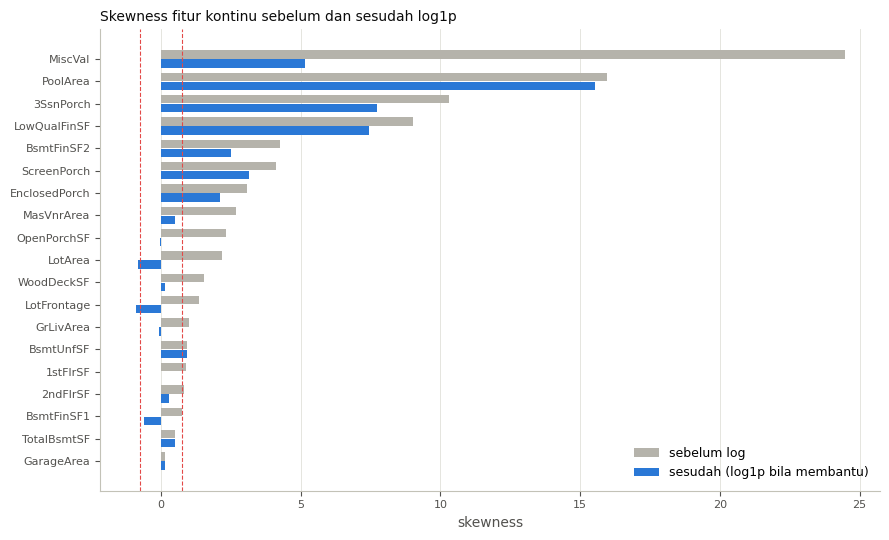

In [44]:
# log1p dipakai jika |skew| > 0.75 DAN hasilnya benar-benar lebih simetris
kontinu_ada = [c for c in KONTINU if c in X_enc.columns]
skew_awal = X_enc[kontinu_ada].skew()
skew_jika_log = np.log1p(X_enc[kontinu_ada]).skew()
kandidat_log = skew_awal[skew_awal.abs() > 0.75].index
DI_LOG = [c for c in kandidat_log if abs(skew_jika_log[c]) < abs(skew_awal[c])]
TIDAK_DILOG = [c for c in kandidat_log if c not in DI_LOG]
X_enc[DI_LOG] = np.log1p(X_enc[DI_LOG])
skew_akhir = X_enc[kontinu_ada].skew()
print(f'Di-log1p ({len(DI_LOG)} fitur): {DI_LOG}')
print(f'Miring tetapi tidak di-log karena log justru memperburuk skew: '
      f'{[(c, round(skew_awal[c], 2), round(skew_jika_log[c], 2)) for c in TIDAK_DILOG]}')

plot_df = pd.DataFrame({'sebelum': skew_awal, 'sesudah': skew_akhir}).sort_values('sebelum')
y_pos = np.arange(len(plot_df))
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(y_pos + 0.2, plot_df['sebelum'], height=0.38, color=ABU_MUDA, label='sebelum log')
ax.barh(y_pos - 0.2, plot_df['sesudah'], height=0.38, color=BIRU, label='sesudah (log1p bila membantu)')
for batas in (-0.75, 0.75):
    ax.axvline(batas, color=MERAH, lw=0.8, ls='--')
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df.index)
ax.grid(axis='y', visible=False)
ax.grid(axis='x', visible=True)
ax.set_xlabel('skewness')
ax.legend(loc='lower right')
ax.set_title('Skewness fitur kontinu sebelum dan sesudah log1p', loc='left')
plt.tight_layout()
plt.show()

### 4.4 Normalisasi dan standarisasi

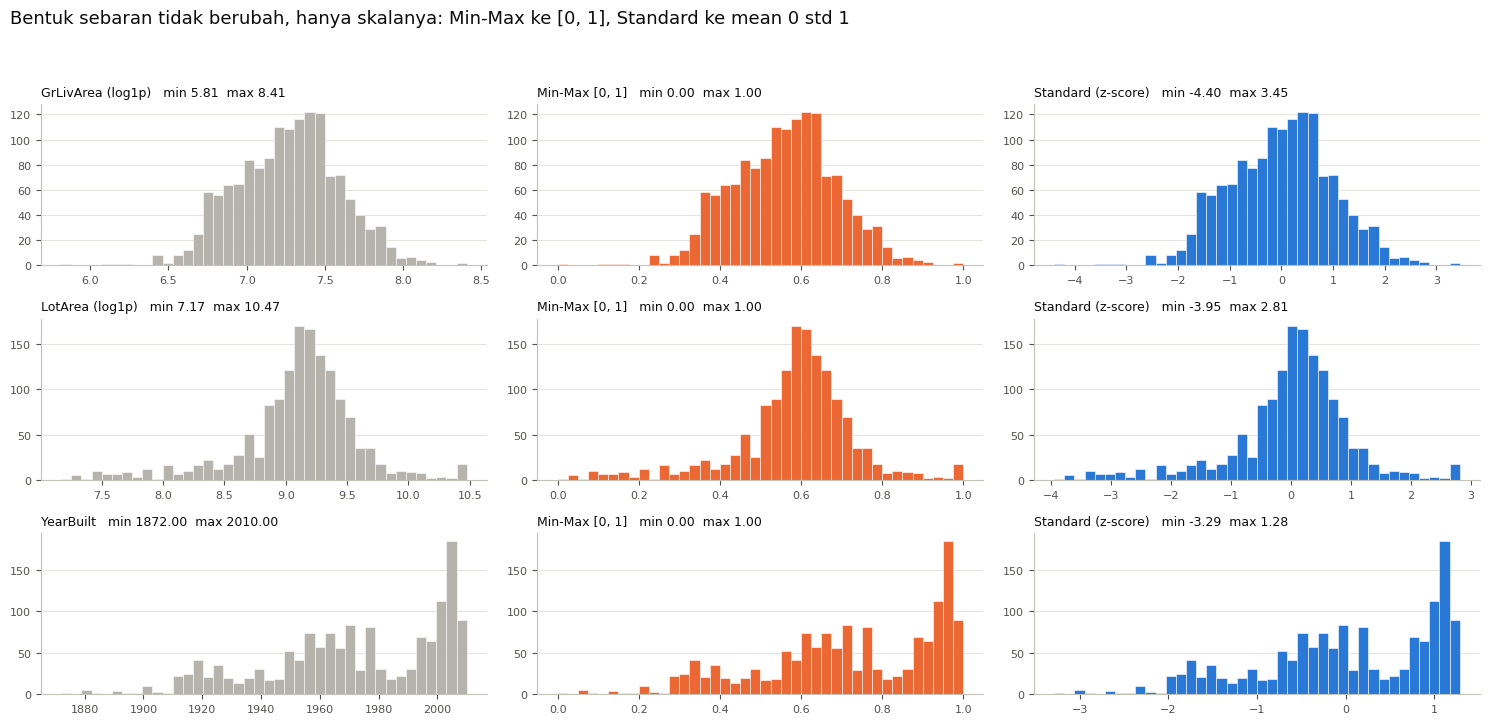

In [45]:
# perbandingan Min-Max vs Standard pada tiga fitur dengan bentuk sebaran berbeda
contoh_fitur = ['GrLivArea', 'LotArea', 'YearBuilt']
minmax = MinMaxScaler().fit_transform(X_enc[contoh_fitur])
standar = StandardScaler().fit_transform(X_enc[contoh_fitur])

fig, axes = plt.subplots(len(contoh_fitur), 3, figsize=(15, 2.4 * len(contoh_fitur)))
for i, col in enumerate(contoh_fitur):
    label_asli = f'{col} (log1p)' if col in DI_LOG else col
    for j, (nilai, nama, warna) in enumerate([(X_enc[col], label_asli, ABU_MUDA),
                                               (minmax[:, i], 'Min-Max [0, 1]', ORANYE),
                                               (standar[:, i], 'Standard (z-score)', BIRU)]):
        axes[i, j].hist(nilai, bins=40, color=warna, edgecolor='white', linewidth=0.4)
        axes[i, j].set_title(f'{nama}   min {np.min(nilai):.2f}  max {np.max(nilai):.2f}', loc='left', fontsize=9)
judul_figur(fig, 'Bentuk sebaran tidak berubah, hanya skalanya: Min-Max ke [0, 1], Standard ke mean 0 std 1')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Kolom distandarisasi: 49   kolom dummy (tetap 0/1): 183
mean setelah standarisasi: 1.5e-14 (maks |mean|)
std setelah standarisasi : 1.000 - 1.000


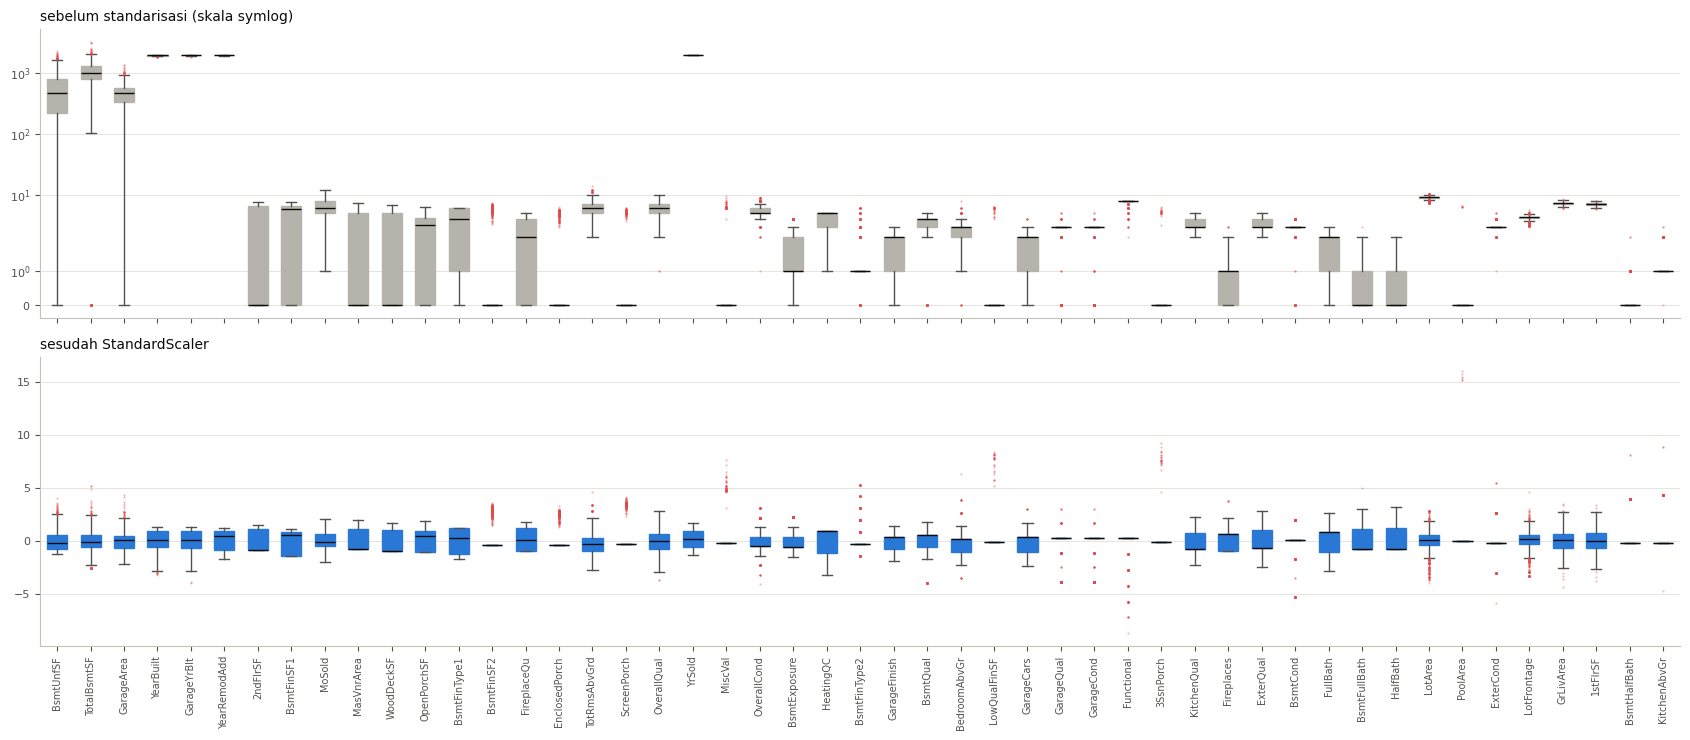

In [46]:
# StandardScaler untuk semua kolom non-dummy; kolom dummy 0/1 dibiarkan
scaler = StandardScaler()
X_std = X_enc.copy()
X_std[NUMERIK] = scaler.fit_transform(X_enc[NUMERIK])

print(f'Kolom distandarisasi: {len(NUMERIK)}   kolom dummy (tetap 0/1): {len(DUMMY)}')
print(f"mean setelah standarisasi: {X_std[NUMERIK].mean().abs().max():.1e} (maks |mean|)")
print(f"std setelah standarisasi : {X_std[NUMERIK].std(ddof=0).min():.3f} - {X_std[NUMERIK].std(ddof=0).max():.3f}")

urut = X_enc[NUMERIK].std().sort_values(ascending=False).index
fig, axes = plt.subplots(2, 1, figsize=(17, 7.5), sharex=True)
for ax, data, judul, warna in [(axes[0], X_enc, 'sebelum standarisasi (skala symlog)', ABU_MUDA),
                               (axes[1], X_std, 'sesudah StandardScaler', BIRU)]:
    ax.boxplot([data[c] for c in urut], widths=0.6, patch_artist=True,
               boxprops=dict(facecolor=warna, edgecolor=warna), medianprops=dict(color=TINTA),
               whiskerprops=dict(color=ABU), capprops=dict(color=ABU),
               flierprops=dict(marker='o', markersize=1.5, markerfacecolor=MERAH, markeredgecolor='none', alpha=0.4))
    ax.set_title(judul, loc='left')
axes[0].set_yscale('symlog')
axes[1].set_xticks(range(1, len(urut) + 1))
axes[1].set_xticklabels(urut, rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

### notes
1. Target dipisah sebagai y = log1p(`SalePrice`) dengan skew 0.12, dan tidak ikut distandarisasi atau PCA. `Id` dibuang dari fitur karena hanya nomor urut.
2. Encoding campuran. 14 fitur ordinal dipetakan ke angka sesuai urutan (Tidak Ada = 0, Po = 1, ..., Ex = 5) karena median harga naik mengikuti skala tersebut (bagian 6); one-hot pada fitur ordinal akan membuang informasi urutan ini.
3. 25 fitur nominal (termasuk `MSSubClass`) di-one-hot menjadi 183 kolom, sehingga X menjadi 232 kolom. Jika semua kategorik di-one-hot, hasilnya 294 kolom.
4. One-hot dilakukan tanpa `drop_first`. Kolom kembar yang muncul (misalnya `CentralAir_Y` dan `CentralAir_N`, r = -1) disaring pada langkah korelasi.
5. log1p diterapkan pada 16 fitur kontinu yang miring. `BsmtUnfSF` tidak di-log karena log justru mengubah skew dari 0.92 menjadi -2.18: 8% nilai nol terpisah jauh dari sisanya.
6. Fitur yang didominasi nol (`PoolArea`, `3SsnPorch`, `LowQualFinSF`, `MiscVal`) tetap miring setelah log (skew 5-16). Masalahnya adalah massa di nol, bukan ekor panjang, jadi log tidak cukup.
7. Min-Max dan Standard tidak mengubah bentuk sebaran, hanya skalanya. StandardScaler dipilih karena PCA bekerja dengan varians (butuh mean 0 dan varians setara), sedangkan Min-Max ditentukan oleh satu nilai terkecil dan terbesar sehingga mudah tertekan oleh nilai ekstrem.
8. Kolom dummy dibiarkan 0/1. Jika distandarisasi, dummy untuk kategori 1% akan bernilai sekitar 10 dan mendominasi PCA.

## Langkah 5 - Reduksi Dimensi

### 5.1 Fitur hampir konstan

Kolom dengan satu nilai > 99% baris: 69 dari 232
Condition1       Condition1_PosA, Condition1_RRAe, Condition1_R...
Condition2       Condition2_Artery, Condition2_Feedr, Condition...
Electrical                        Electrical_FuseP, Electrical_Mix
Exterior1st      Exterior1st_AsphShn, Exterior1st_BrkComm, Exte...
Exterior2nd      Exterior2nd_AsphShn, Exterior2nd_BrkComm, Exte...
Foundation                       Foundation_Stone, Foundation_Wood
GarageType                   GarageType_2Types, GarageType_CarPort
Heating          Heating_Floor, Heating_Grav, Heating_OthW, Hea...
HouseStyle       HouseStyle_1.5Unf, HouseStyle_2.5Fin, HouseSty...
LandSlope                                            LandSlope_Sev
LotConfig                                            LotConfig_FR3
LotShape                                              LotShape_IR3
MSSubClass            MSSubClass_180, MSSubClass_40, MSSubClass_45
MSZoning                                          MSZoning_C (all)
Neighborhood 

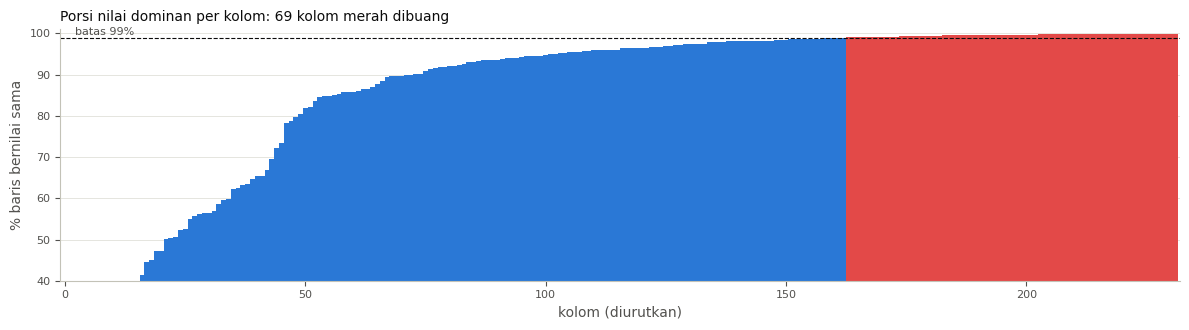

Ukuran X: (1458, 232) -> (1458, 163)


In [47]:
porsi_dominan = X_std.apply(lambda s: s.value_counts(normalize=True).iloc[0])
HAMPIR_KONSTAN = porsi_dominan[porsi_dominan > 0.99].index.tolist()


def asal_fitur(kolom):
    # nama fitur asli dari kolom dummy (mis. 'Neighborhood_Blueste' -> 'Neighborhood')
    for c in NOMINAL:
        if kolom.startswith(c + '_'):
            return c
    return kolom


asal = pd.Series({c: asal_fitur(c) for c in HAMPIR_KONSTAN})
print(f'Kolom dengan satu nilai > 99% baris: {len(HAMPIR_KONSTAN)} dari {X_std.shape[1]}')
print(asal.groupby(asal).apply(lambda s: ', '.join(s.index)).to_string())

urut = porsi_dominan.sort_values().to_numpy()
fig, ax = plt.subplots(figsize=(12, 3.4))
ax.bar(range(len(urut)), urut * 100, width=1.0, color=[MERAH if v > 0.99 else BIRU for v in urut])
ax.axhline(99, color=TINTA, lw=0.8, ls='--')
ax.text(2, 99.6, 'batas 99%', fontsize=8, color=ABU)
ax.set_xlim(-1, len(urut))
ax.set_ylim(40, 101)
ax.set_xlabel('kolom (diurutkan)')
ax.set_ylabel('% baris bernilai sama')
ax.set_title(f'Porsi nilai dominan per kolom: {len(HAMPIR_KONSTAN)} kolom merah dibuang', loc='left')
plt.tight_layout()
plt.show()

X_nzv = X_std.drop(columns=HAMPIR_KONSTAN)
print(f'Ukuran X: {X_std.shape} -> {X_nzv.shape}')

### 5.2 Analisis korelasi antar atribut

,fitur_1,fitur_2,r,|r_y| fitur_1,|r_y| fitur_2,keputusan
0,BldgType_Duplex,MSSubClass_90,1.000,0.117,0.117,buang MSSubClass_90
1,CentralAir_Y,CentralAir_N,-1.000,0.352,0.352,buang CentralAir_N
2,SaleCondition_Partial,SaleType_New,0.987,0.327,0.331,buang SaleCondition_Partial
3,BldgType_2fmCon,MSSubClass_190,0.983,0.110,0.105,buang MSSubClass_190
4,Exterior2nd_VinylSd,Exterior1st_VinylSd,0.978,0.338,0.336,buang Exterior1st_VinylSd
5,Exterior2nd_CemntBd,Exterior1st_CemntBd,0.974,0.092,0.094,buang Exterior2nd_CemntBd
6,Exterior2nd_MetalSd,Exterior1st_MetalSd,0.973,0.168,0.173,buang Exterior2nd_MetalSd
7,GarageCond,GarageQual,0.959,0.357,0.363,buang GarageCond
8,GarageType_Tidak Ada,GarageCond,-0.946,0.323,0.357,sudah terwakili
9,GarageType_Tidak Ada,GarageQual,-0.942,0.323,0.363,buang GarageType_Tidak Ada


Dibuang karena korelasi > 0.8: 28 kolom ['MSSubClass_90', 'CentralAir_N', 'SaleCondition_Partial', 'MSSubClass_190', 'Exterior1st_VinylSd', 'Exterior2nd_CemntBd', 'Exterior2nd_MetalSd', 'GarageCond', 'GarageType_Tidak Ada', 'MSSubClass_80', 'MSSubClass_50', 'RoofStyle_Gable', 'LotShape_IR1', 'LandSlope_Mod', 'GarageArea', 'Exterior2nd_HdBoard', 'BsmtFinType2', 'Fireplaces', 'MSZoning_FV', 'HouseStyle_1Story', 'Exterior2nd_Wd Sdng', 'Electrical_FuseA', 'PavedDrive_N', 'BsmtFinSF1', 'Exterior2nd_AsbShng', 'GarageYrBlt', 'TotRmsAbvGrd', 'MSZoning_RL']


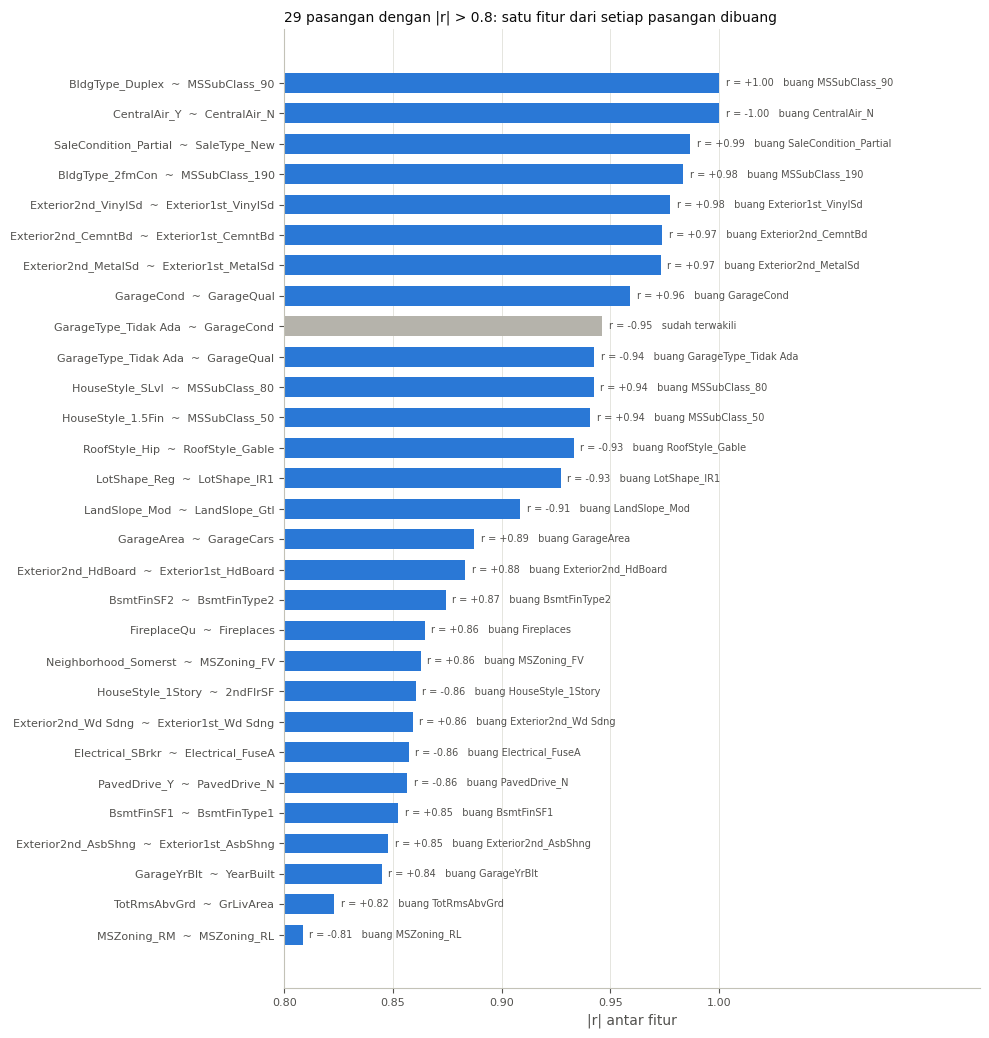

Ukuran X: (1458, 163) -> (1458, 135)


In [48]:
BATAS_KOR = 0.8
kor = X_nzv.corr()
kor_ke_y = X_nzv.corrwith(y).abs()

tril = np.tril(np.ones(kor.shape, dtype=bool), k=-1)
pasangan_x = kor.where(tril).stack().rename('r').reset_index()
pasangan_x.columns = ['fitur_1', 'fitur_2', 'r']
tinggi = pasangan_x[pasangan_x['r'].abs() > BATAS_KOR].sort_values('r', key=abs, ascending=False)

# dari setiap pasangan, buang fitur yang korelasinya ke target lebih lemah
DIBUANG_KOR, catatan = [], []
for a, b, r in tinggi.itertuples(index=False):
    if a in DIBUANG_KOR or b in DIBUANG_KOR:
        keputusan = 'sudah terwakili'
    else:
        buang = a if kor_ke_y[a] < kor_ke_y[b] else b
        DIBUANG_KOR.append(buang)
        keputusan = f'buang {buang}'
    catatan.append({'fitur_1': a, 'fitur_2': b, 'r': r, '|r_y| fitur_1': kor_ke_y[a],
                    '|r_y| fitur_2': kor_ke_y[b], 'keputusan': keputusan})
display(pd.DataFrame(catatan).round(3))
print(f'Dibuang karena korelasi > {BATAS_KOR}: {len(DIBUANG_KOR)} kolom {DIBUANG_KOR}')

plot_df = pd.DataFrame(catatan).iloc[::-1]
label = [f"{a}  ~  {b}" for a, b in zip(plot_df['fitur_1'], plot_df['fitur_2'])]
fig, ax = plt.subplots(figsize=(10, 0.32 * len(plot_df) + 1.2))
ax.barh(label, plot_df['r'].abs(), height=0.65,
        color=[ABU_MUDA if k == 'sudah terwakili' else BIRU for k in plot_df['keputusan']])
for yy, (v, k) in enumerate(zip(plot_df['r'], plot_df['keputusan'])):
    ax.text(abs(v) + 0.003, yy, f'r = {v:+.2f}   {k}', va='center', fontsize=7, color=ABU)
ax.set_xlim(BATAS_KOR, 1.12)
ax.set_xticks([0.8, 0.85, 0.9, 0.95, 1.0])
ax.tick_params(axis='y', labelsize=8)
ax.grid(axis='y', visible=False)
ax.grid(axis='x', visible=True)
ax.set_xlabel('|r| antar fitur')
ax.set_title(f'{len(plot_df)} pasangan dengan |r| > {BATAS_KOR}: satu fitur dari setiap pasangan dibuang', loc='left')
plt.tight_layout()
plt.show()

X_red = X_nzv.drop(columns=DIBUANG_KOR)
print(f'Ukuran X: {X_nzv.shape} -> {X_red.shape}')

### 5.3 PCA (Principal Component Analysis)

80% varians: 24 komponen dari 135 fitur
90% varians: 37 komponen dari 135 fitur
95% varians: 51 komponen dari 135 fitur
Porsi varians total dari kolom numerik: 86.4%, dari dummy: 13.6%
Ukuran X setelah PCA (95% varians): (1458, 51)
Korelasi PC1 dengan log harga: 0.906


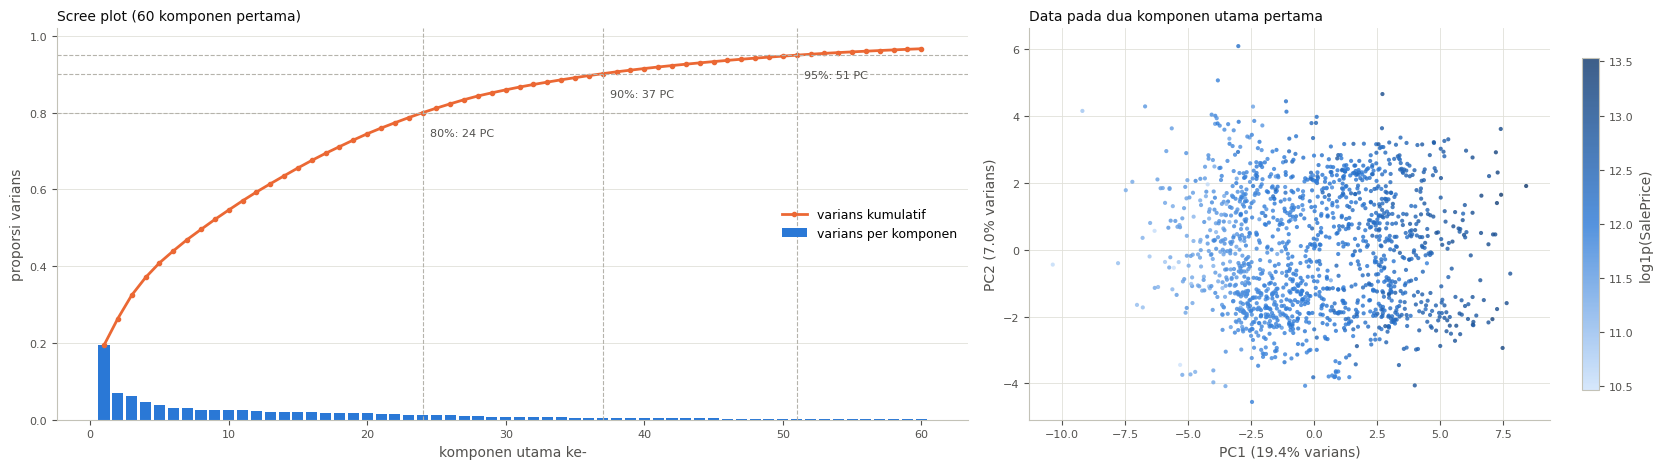

In [49]:
pca_penuh = PCA(random_state=42).fit(X_red)
rasio = pca_penuh.explained_variance_ratio_
kumulatif = rasio.cumsum()
k = {p: int(np.argmax(kumulatif >= p) + 1) for p in (0.80, 0.90, 0.95)}
for p, n in k.items():
    print(f'{p:.0%} varians: {n} komponen dari {X_red.shape[1]} fitur')

var_num = X_red[[c for c in X_red.columns if c in NUMERIK]].var().sum()
var_dummy = X_red[[c for c in X_red.columns if c not in NUMERIK]].var().sum()
print(f'Porsi varians total dari kolom numerik: {var_num / (var_num + var_dummy):.1%}, dari dummy: {var_dummy / (var_num + var_dummy):.1%}')

pca = PCA(n_components=0.95, random_state=42)
X_pca = pd.DataFrame(pca.fit_transform(X_red), columns=[f'PC{i + 1}' for i in range(pca.n_components_)])
print(f'Ukuran X setelah PCA (95% varians): {X_pca.shape}')
print(f"Korelasi PC1 dengan log harga: {X_pca['PC1'].corr(y):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(17, 4.8), gridspec_kw={'width_ratios': [1.4, 1]})
n_tampil = min(60, len(rasio))
ax = axes[0]
ax.bar(range(1, n_tampil + 1), rasio[:n_tampil], color=BIRU, width=0.8, label='varians per komponen')
ax.plot(range(1, n_tampil + 1), kumulatif[:n_tampil], color=ORANYE, lw=2, marker='o', markersize=3,
        label='varians kumulatif')
for p, n in k.items():
    ax.axhline(p, color=ABU_MUDA, lw=0.8, ls='--')
    ax.axvline(n, color=ABU_MUDA, lw=0.8, ls='--')
    ax.text(n + 0.5, p - 0.06, f'{p:.0%}: {n} PC', fontsize=8, color=ABU)
ax.set_ylim(0, 1.02)
ax.set_xlabel('komponen utama ke-')
ax.set_ylabel('proporsi varians')
ax.legend(loc='center right')
ax.set_title(f'Scree plot ({n_tampil} komponen pertama)', loc='left')

ax = axes[1]
sc = ax.scatter(X_pca['PC1'], X_pca['PC2'], c=y, cmap=CMAP_SEKUENSIAL, s=9, alpha=0.8, edgecolors='none')
cbar = plt.colorbar(sc, ax=ax, shrink=0.85)
cbar.set_label('log1p(SalePrice)')
ax.set_xlabel(f'PC1 ({rasio[0]:.1%} varians)')
ax.set_ylabel(f'PC2 ({rasio[1]:.1%} varians)')
ax.grid(axis='x', visible=True)
ax.set_title('Data pada dua komponen utama pertama', loc='left')
plt.tight_layout()
plt.show()

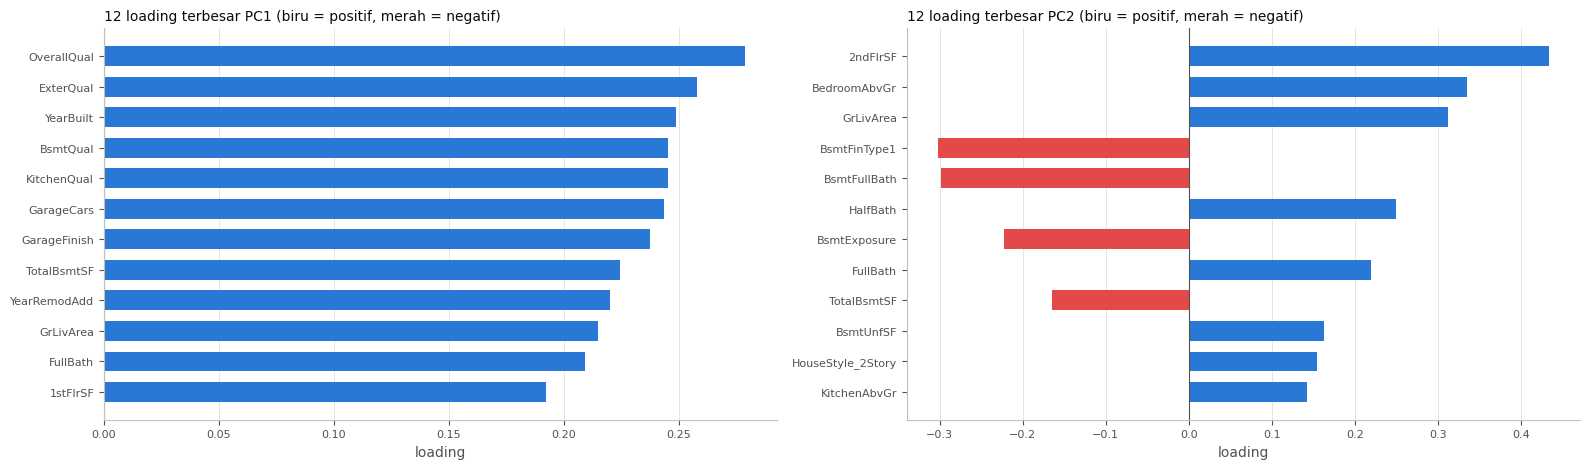

In [50]:
# fitur yang paling membentuk PC1 dan PC2
muatan = pd.DataFrame(pca.components_[:2].T, index=X_red.columns, columns=['PC1', 'PC2'])

fig, axes = plt.subplots(1, 2, figsize=(16, 4.8))
for ax, pc in zip(axes, ['PC1', 'PC2']):
    top = muatan[pc].reindex(muatan[pc].abs().sort_values().index[-12:])
    ax.barh(top.index, top.values, color=[BIRU if v > 0 else MERAH for v in top.values], height=0.65)
    ax.axvline(0, color=ABU, lw=0.8)
    ax.grid(axis='y', visible=False)
    ax.grid(axis='x', visible=True)
    ax.set_xlabel('loading')
    ax.set_title(f'12 loading terbesar {pc} (biru = positif, merah = negatif)', loc='left')
plt.tight_layout()
plt.show()

### notes
1. 69 kolom yang satu nilainya mencakup lebih dari 99% baris dibuang: `Street` dan `Utilities` (masing-masing 2 kolom), `PoolArea`, dan dummy kategori langka (paling banyak 14 rumah), misalnya 8 dari `Condition2` dan 6 dari `RoofMatl`. Kolom seperti ini hampir tidak membedakan rumah dan membuat korelasi serta PCA tidak stabil.
2. Ada 29 pasangan dengan |r| > 0.8, dan 28 kolom dibuang (satu pasangan sudah terwakili). Dari setiap pasangan dipertahankan fitur yang korelasinya ke log harga lebih kuat.
3. Redundansi muncul dalam tiga bentuk:
   - kolom kembar hasil one-hot: `CentralAir_Y` / `CentralAir_N` (r = -1), `SaleType_New` / `SaleCondition_Partial` (0.99, rumah baru dijual sebelum selesai), dan material yang sama di `Exterior1st` / `Exterior2nd` (0.85-0.98);
   - kode yang tumpang tindih: `MSSubClass` sudah memuat tipe bangunan dan gaya rumah (`MSSubClass_90` = `BldgType_Duplex`, r = 1.00);
   - ukuran fisik yang sama: `GarageArea` / `GarageCars` (0.89), `GarageQual` / `GarageCond` (0.96), `GarageYrBlt` / `YearBuilt` (0.84), `TotRmsAbvGrd` / `GrLivArea` (0.82).
4. PCA pada 135 fitur: 24 komponen menjelaskan 80% varians, 37 komponen 90%, dan 51 komponen 95%. PC1 sendiri menjelaskan 19.4% varians, PC2 7.0%.
5. PC1 adalah sumbu kualitas dan ukuran rumah, dengan loading terbesar `OverallQual`, `ExterQual`, `YearBuilt`, `BsmtQual`, `KitchenQual`, `GarageCars`. Korelasinya dengan log harga 0.906, padahal PCA tidak melihat target sama sekali.
6. PC2 membedakan rumah bertingkat dari rumah satu lantai dengan basement jadi: positif untuk `2ndFlrSF`, `BedroomAbvGr`, `GrLivArea`, `HalfBath`; negatif untuk `BsmtFullBath`, `BsmtFinType1`, `BsmtExposure`, `TotalBsmtSF`.
7. Kolom numerik menyumbang 86.4% varians total (dummy 0/1 hanya 13.6%), jadi komponen utama terutama dibentuk oleh fitur numerik.
8. Hasil PCA tidak diekspor. `train_clean.csv` berhenti di tahap pembersihan, sebelum encoding, agar tetap terbaca dalam satuan aslinya.

## Ringkasan Dataset Akhir

,tahap,baris,kolom,sel_kosong
0,data mentah,1460,81,7829
1,buang kolom kosong > 50%,1460,76,1550
2,isi NA struktural,1460,76,270
3,imputasi hilang sebenarnya,1460,76,0
4,hapus 2 anomali,1458,76,0
5,capping P99 (train_clean.csv),1458,76,0
6,pisah Id dan target,1458,74,0
7,encoding,1458,232,0
8,buang fitur hampir konstan,1458,163,0
9,buang fitur berkorelasi tinggi,1458,135,0


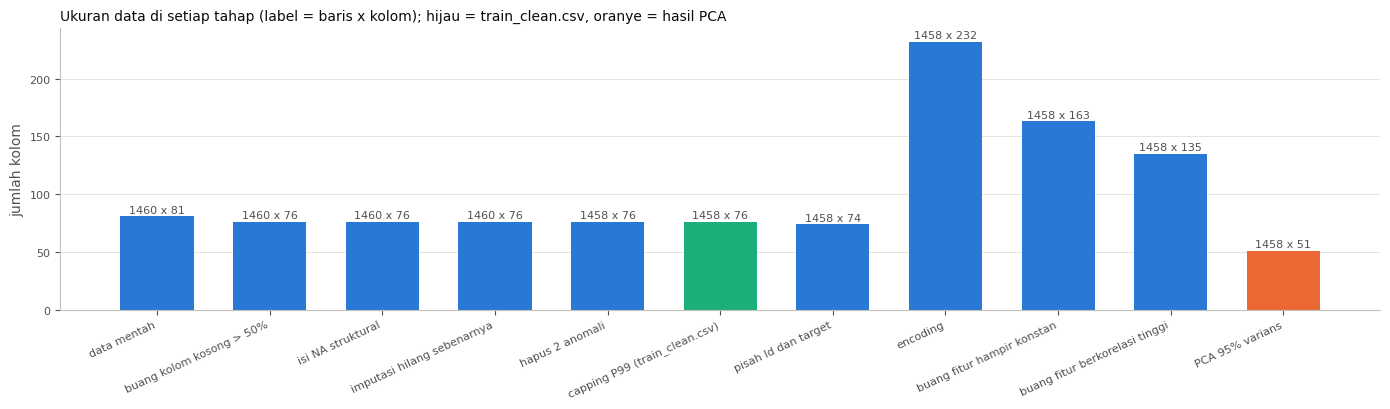

In [51]:
jejak_akhir = jejak + [
    ('pisah Id dan target', X.shape[0], X.shape[1], 0),
    ('encoding', *X_enc.shape, 0),
    ('buang fitur hampir konstan', *X_nzv.shape, 0),
    ('buang fitur berkorelasi tinggi', *X_red.shape, 0),
    ('PCA 95% varians', *X_pca.shape, 0),
]
ringkasan = pd.DataFrame(jejak_akhir, columns=['tahap', 'baris', 'kolom', 'sel_kosong'])
display(ringkasan)

fig, ax = plt.subplots(figsize=(14, 4.2))
warna = [AQUA if 'train_clean' in t else (ORANYE if t == 'PCA 95% varians' else BIRU) for t in ringkasan['tahap']]
ax.bar(range(len(ringkasan)), ringkasan['kolom'], color=warna, width=0.65)
for xx, (b, kk) in enumerate(zip(ringkasan['baris'], ringkasan['kolom'])):
    ax.text(xx, kk + 3, f'{b} x {kk}', ha='center', fontsize=8, color=ABU)
ax.set_xticks(range(len(ringkasan)))
ax.set_xticklabels(ringkasan['tahap'], rotation=25, ha='right', fontsize=8)
ax.set_ylabel('jumlah kolom')
ax.set_title('Ukuran data di setiap tahap (label = baris x kolom); hijau = train_clean.csv, oranye = hasil PCA',
             loc='left')
plt.tight_layout()
plt.show()

### notes ringkasan
1. Data mentah 1460 x 81 dengan 7829 sel kosong menjadi `train_clean.csv` 1458 x 76 tanpa sel kosong: 2 baris anomali dan 5 kolom yang lebih dari 50% kosong dibuang, NA struktural diisi "Tidak Ada", 278 sel yang benar-benar hilang diimputasi, 107 sel tidak konsisten diperbaiki, dan `LotArea` di-capping di P99.
2. Matriks fitur siap model berukuran 1458 x 135 (41 kolom numerik terstandarisasi dan 94 dummy 0/1), dengan target y = log1p(`SalePrice`).
3. PCA 95% varians memadatkan 135 fitur menjadi 51 komponen (berkurang 62%).
4. Yang sengaja tidak diubah: rumah mahal pada `SalePrice`, fitur yang didominasi nol, dan nilai ekstrem yang sejalan dengan harga, karena semuanya informasi nyata, bukan kesalahan data.